# ***Research Question: How do AML detection models differ when applied to transaction graph based datasets versus account level, feature based datasets, and how can XAI methods help interpret and compare fraud detection patterns across these different data representations?***
---
---

In [1]:
import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())

Project root: c:\University\Year4\Thesis\AML-Thesis
src exists: True


## **PART 1 - Dataset Representation Comparison**
---

The Elliptic transaction dataset was selected for the comparison because it is available in both **feature-based** and **graph-based** representations. This makes it possible to compare traditional machine learning models and graph neural networks under the same conditions and on the same underlying data. Using only one dataset also helps ensure a fair comparison, since differences in performance are more likely to come from the data representation and model architecture rather than differences between datasets themselves.

The **preprocessing steps** were slightly different because feature-based models and graph-based models use the data in different ways. 

For the **feature-based** models, identifier columns were removed because they do not improve prediction and may cause data leakage. 

For the **graph-based** models, identifiers were kept because they are needed to maintain the connections between transactions. 

Both approaches still used the same main cleaning steps, such as removing missing values, removing unknown classes, and converting the problem into binary classification. 

**Therefore, the comparison is still fair because both model types used the same transaction dataset and prediction task.**

In [5]:
rq1_dir = project_root / "models" / "rq1_results_feature_models" / "elliptic_transactions"
rq2_dir = project_root / "models" / "rq2_results_graph_models"

# ---------- RQ1: Feature-based models ----------
feature_files = {
    "LightGBM": rq1_dir / "lightgbm_results.csv",
    "XGBoost": rq1_dir / "xgboost_results.csv",
    "Random Forest": rq1_dir / "random_forest_results.csv",
}

feature_rows = []

for model_name, file_path in feature_files.items():
    df = pd.read_csv(file_path)

    # choose best row by F1
    best = df.loc[df["f1"].idxmax()]

    feature_rows.append({
        "Model Type": "Feature-based",
        "Model": model_name,
        "Setup": best["setup"],
        "F1": round(best["f1"], 4),
        "ROC-AUC": round(best["roc_auc"], 4)
    })

# ---------- RQ2: Graph models ----------
graph_files = {
    "GraphSAGE": rq2_dir / "GraphSAGE" / "graphSAGE_summary.csv",
    "GCN": rq2_dir / "SimpleGCN" / "gcn_summary.csv",
    "EvolveGCN-O": rq2_dir / "EvolveGCN" / "evolve_summary.csv",
}

# Final selected setups based on temporal robustness
selected_setups = {
    "GraphSAGE": "simple_balanced",
    "GCN": "simple_balanced",
    "EvolveGCN-O": "simple_balanced",
}

def get_f1_mean(value):
    value = str(value)
    return float(value.split("±")[0].strip())

graph_rows = []

for model_name, file_path in graph_files.items():
    df = pd.read_csv(file_path)

    # Select chosen setup instead of max F1
    best = df[df["setup"] == selected_setups[model_name]].iloc[0]

    graph_rows.append({
        "Model Type": (
            "Graph (static)"
            if model_name in ["GraphSAGE", "GCN"]
            else "Graph (dynamic)"
        ),
        "Model": model_name,
        "Setup": best["setup"],
        "F1": best["f1"],
        "ROC-AUC": best["roc_auc"]
    })

# ---------- Final table ----------
comparison_table = pd.DataFrame(feature_rows + graph_rows)

comparison_table

,Model Type,Model,Setup,F1,ROC-AUC
0,Feature-based,LightGBM,simple_balanced,0.7528,0.9487
1,Feature-based,XGBoost,simple_balanced,0.7463,0.9511
2,Feature-based,Random Forest,smote,0.7289,0.9506
3,Graph (static),GraphSAGE,simple_balanced,0.4375 ± 0.1294,0.8527 ± 0.0348
4,Graph (static),GCN,simple_balanced,0.2281 ± 0.0239,0.7726 ± 0.0105
5,Graph (dynamic),EvolveGCN-O,simple_balanced,0.119388,0.532075


In [6]:
all_models = []

for model_name, file_path in feature_files.items():

    df = pd.read_csv(file_path)

    best = df.loc[df["f1"].idxmax()]

    all_models.append({
        "Model": model_name,
        "F1": float(best["f1"])
    })

for model_name, file_path in graph_files.items():

    df = pd.read_csv(file_path)

    # Graph models: use selected setup based on temporal robustness
    selected_setup = selected_setups[model_name]

    best = df[df["setup"] == selected_setup].iloc[0]

    all_models.append({
        "Model": model_name,
        "F1": get_f1_mean(best["f1"])
    })

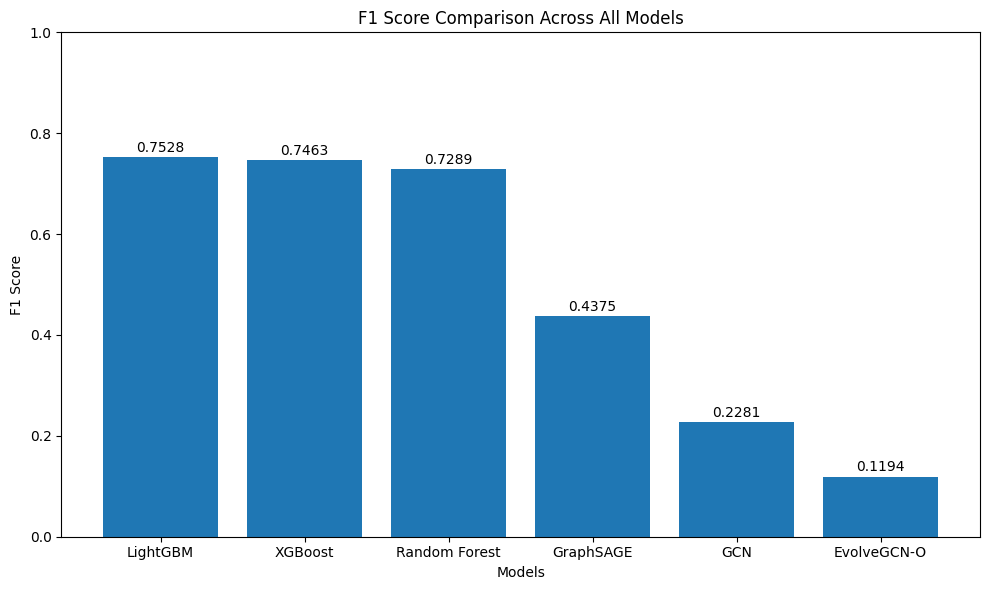

In [7]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame(all_models)

# sort by F1
plot_df = plot_df.sort_values(by="F1", ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(plot_df["Model"], plot_df["F1"])

plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison Across All Models")

plt.ylim(0, 1)

# add values above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

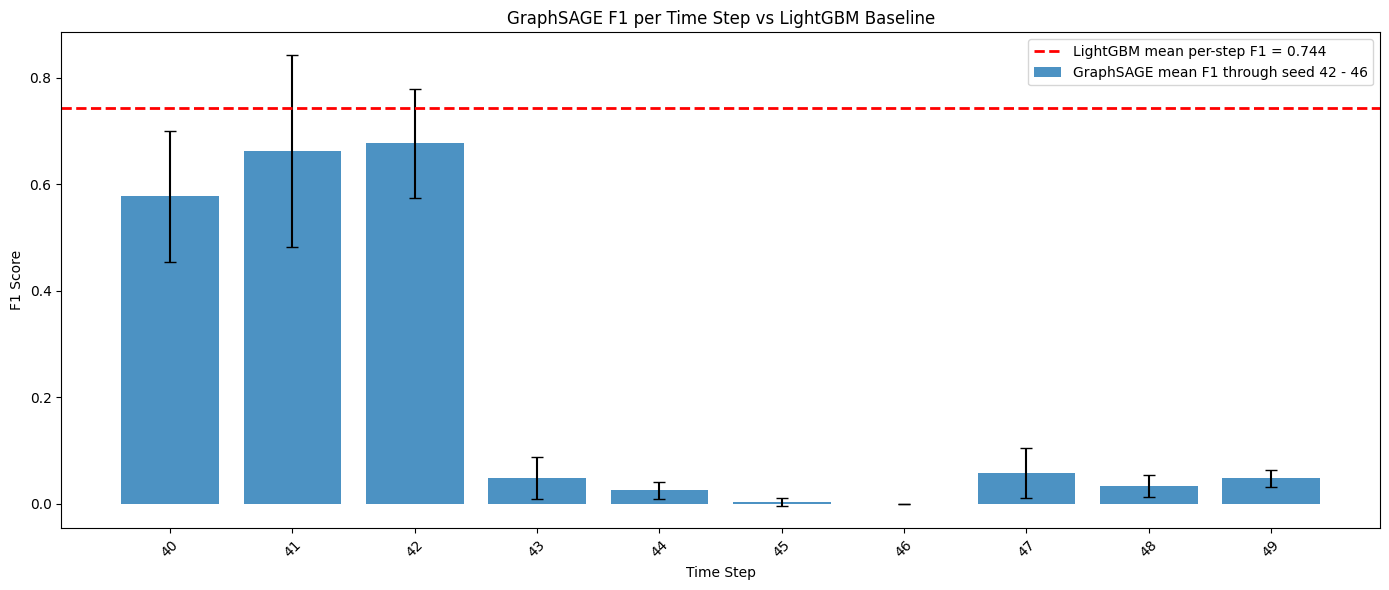

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load data
# -------------------------------------------------
graphsage_df = pd.read_csv(project_root / "models"/ "rq2_results_graph_models"/ "GraphSAGE"/"graphSAGE_simple_balanced.csv")
lightgbm_df = pd.read_csv(project_root/ "models"/ "rq1_results_feature_models"/ "elliptic_transactions"/"lightgbm_results.csv")

# -------------------------------------------------
# Aggregate GraphSAGE across seeds
# -------------------------------------------------
graphsage_agg = (
    graphsage_df
    .groupby("time_step")["f1"]
    .agg(["mean", "std"])
    .reset_index()
)

# -------------------------------------------------
# Baselines
# -------------------------------------------------
lightgbm_baseline_f1 = lightgbm_df["f1"].mean()

graphsage_average_f1 = graphsage_agg["mean"].mean()

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(14, 6))

# GraphSAGE bars
plt.bar(
    graphsage_agg["time_step"],
    graphsage_agg["mean"],
    yerr=graphsage_agg["std"],
    capsize=4,
    alpha=0.8,
    label="GraphSAGE mean F1 through seed 42 - 46"
)

# LightGBM baseline (RED)
plt.axhline(
    y=lightgbm_baseline_f1,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"LightGBM mean per-step F1 = {lightgbm_baseline_f1:.3f}"
)

# Labels
plt.xlabel("Time Step")
plt.ylabel("F1 Score")
plt.title("GraphSAGE F1 per Time Step vs LightGBM Baseline")

# Show ALL timesteps
plt.xticks(
    graphsage_agg["time_step"],
    graphsage_agg["time_step"],
    rotation=45
)

plt.legend()
plt.tight_layout()

# Save
plt.savefig(
    project_root / "models" / "rq3_xai_models" / "graphsage_f1_vs_lightgbm_baseline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
from src.data_loader import load_transactions_combined_simple

X_train, X_test, y_train, y_test = load_transactions_combined_simple()

X_train_feat = X_train

all_cols = list(X_train_feat.columns)

local_cols       = [c for c in all_cols if c.startswith("Local_feature_")]
aggregate_cols   = [c for c in all_cols if c.startswith("Aggregate_feature_")]
named_agg_cols   = [c for c in all_cols
                    if any(kw in c for kw in ["in_BTC", "out_BTC", "in_txs", "out_txs"])]
other_cols       = [c for c in all_cols
                    if c not in local_cols + aggregate_cols + named_agg_cols]

print(f"Total features:           {len(all_cols)}")
print(f"Local_feature_*:          {len(local_cols)}")
print(f"Aggregate_feature_*:      {len(aggregate_cols)}")
print(f"Named aggregates (BTC):   {len(named_agg_cols)}")
print(f"Other:                    {len(other_cols)} -> {other_cols}")

total_agg = len(aggregate_cols) + len(named_agg_cols)
print(f"\nTotal aggregated:         {total_agg}  ({total_agg/len(all_cols)*100:.1f}%)")
print(f"Total local:              {len(local_cols)}  ({len(local_cols)/len(all_cols)*100:.1f}%)")

Total features:           182
Local_feature_*:          93
Aggregate_feature_*:      72
Named aggregates (BTC):   12
Other:                    5 -> ['total_BTC', 'fees', 'size', 'num_input_addresses', 'num_output_addresses']

Total aggregated:         84  (46.2%)
Total local:              93  (51.1%)


Adding graph structure to the *Elliptic++ transactions dataset* did not improve detection. It made it worse. The best feature-based model beats the best graph-based model by an F1 gap of **0.3153**, and beats the dynamic graph model by **0.6334**. This is the opposite of what one would expect from graph neural networks, which are designed to capture relational patterns that feature-based models may miss.

The results show that the feature-based models clearly outperform the graph-based models. **LightGBM** achieved the best overall performance with an **F1-score of 0.7528** and a **ROC-AUC of 0.9487**. **XGBoost** and **Random Forest** also produced strong and stable results, with F1-scores above 0.72 and ROC-AUC values close to 0.95. These results suggest that the transaction features contain strong patterns that help identify illicit transactions.

Among the graph-based models, **GraphSAGE** performed the best, achieving an **F1-score of 0.4375** and a **ROC-AUC of 0.8527**. This indicates that using graph structure and neighbourhood information can still help detect suspicious activity. However, its performance remained much lower than the feature-based models.

**GCN** achieved weaker results, with an **F1-score of 0.2281**, showing that it struggled to learn useful transaction patterns from the graph structure.

The dynamic graph model **EvolveGCN-O** achieved the lowest performance, with an **F1-score of only 0.1194** and a **ROC-AUC of 0.5321**, which is close to random ranking. Note that EvolveGCN-O was trained with only one random seed for 50 epochs without hyperparameter tuning due to computational cost, so this result should be read as a lower bound rather than evidence that dynamic graph models are not suitable for AML detection.

For the graph models, the ***simple_balanced*** setup is reported because the unbalanced(***simple***) setup achieved a higher aggregate F1 only by performing well on steps 40–42 and then producing near-zero F1 across all post-shutdown steps. Reporting ***simple_balanced*** provides a fairer comparison against the feature-based models, which were also evaluated under their best balanced setups.

The per-time-step results make this collapse clear. The figure below shows GraphSAGE's mean F1 per time step (averaged across five seeds, with standard deviation bars) against LightGBM's mean per-step F1 of 0.744. (This per-step average differs slightly from LightGBM's pooled aggregate F1 of 0.753 reported earlier, because it weights each time step equally rather than weighting by the number of transactions per step.) During the stable period (steps 40–42), GraphSAGE reaches a mean F1 of around 0.58–0.68 and even approaches the LightGBM baseline at step 42. However, after step 43, the dark-market shutdown, its performance collapses to almost zero and never recovers, staying below 0.06 for every remaining time step. The wide standard deviation bars in the stable period also show that GraphSAGE is unstable across seeds, unlike the tree-based models. This explains why GraphSAGE's aggregate F1 (0.438) is so much lower: a brief period near the baseline is dragged down by the complete post-shutdown collapse.

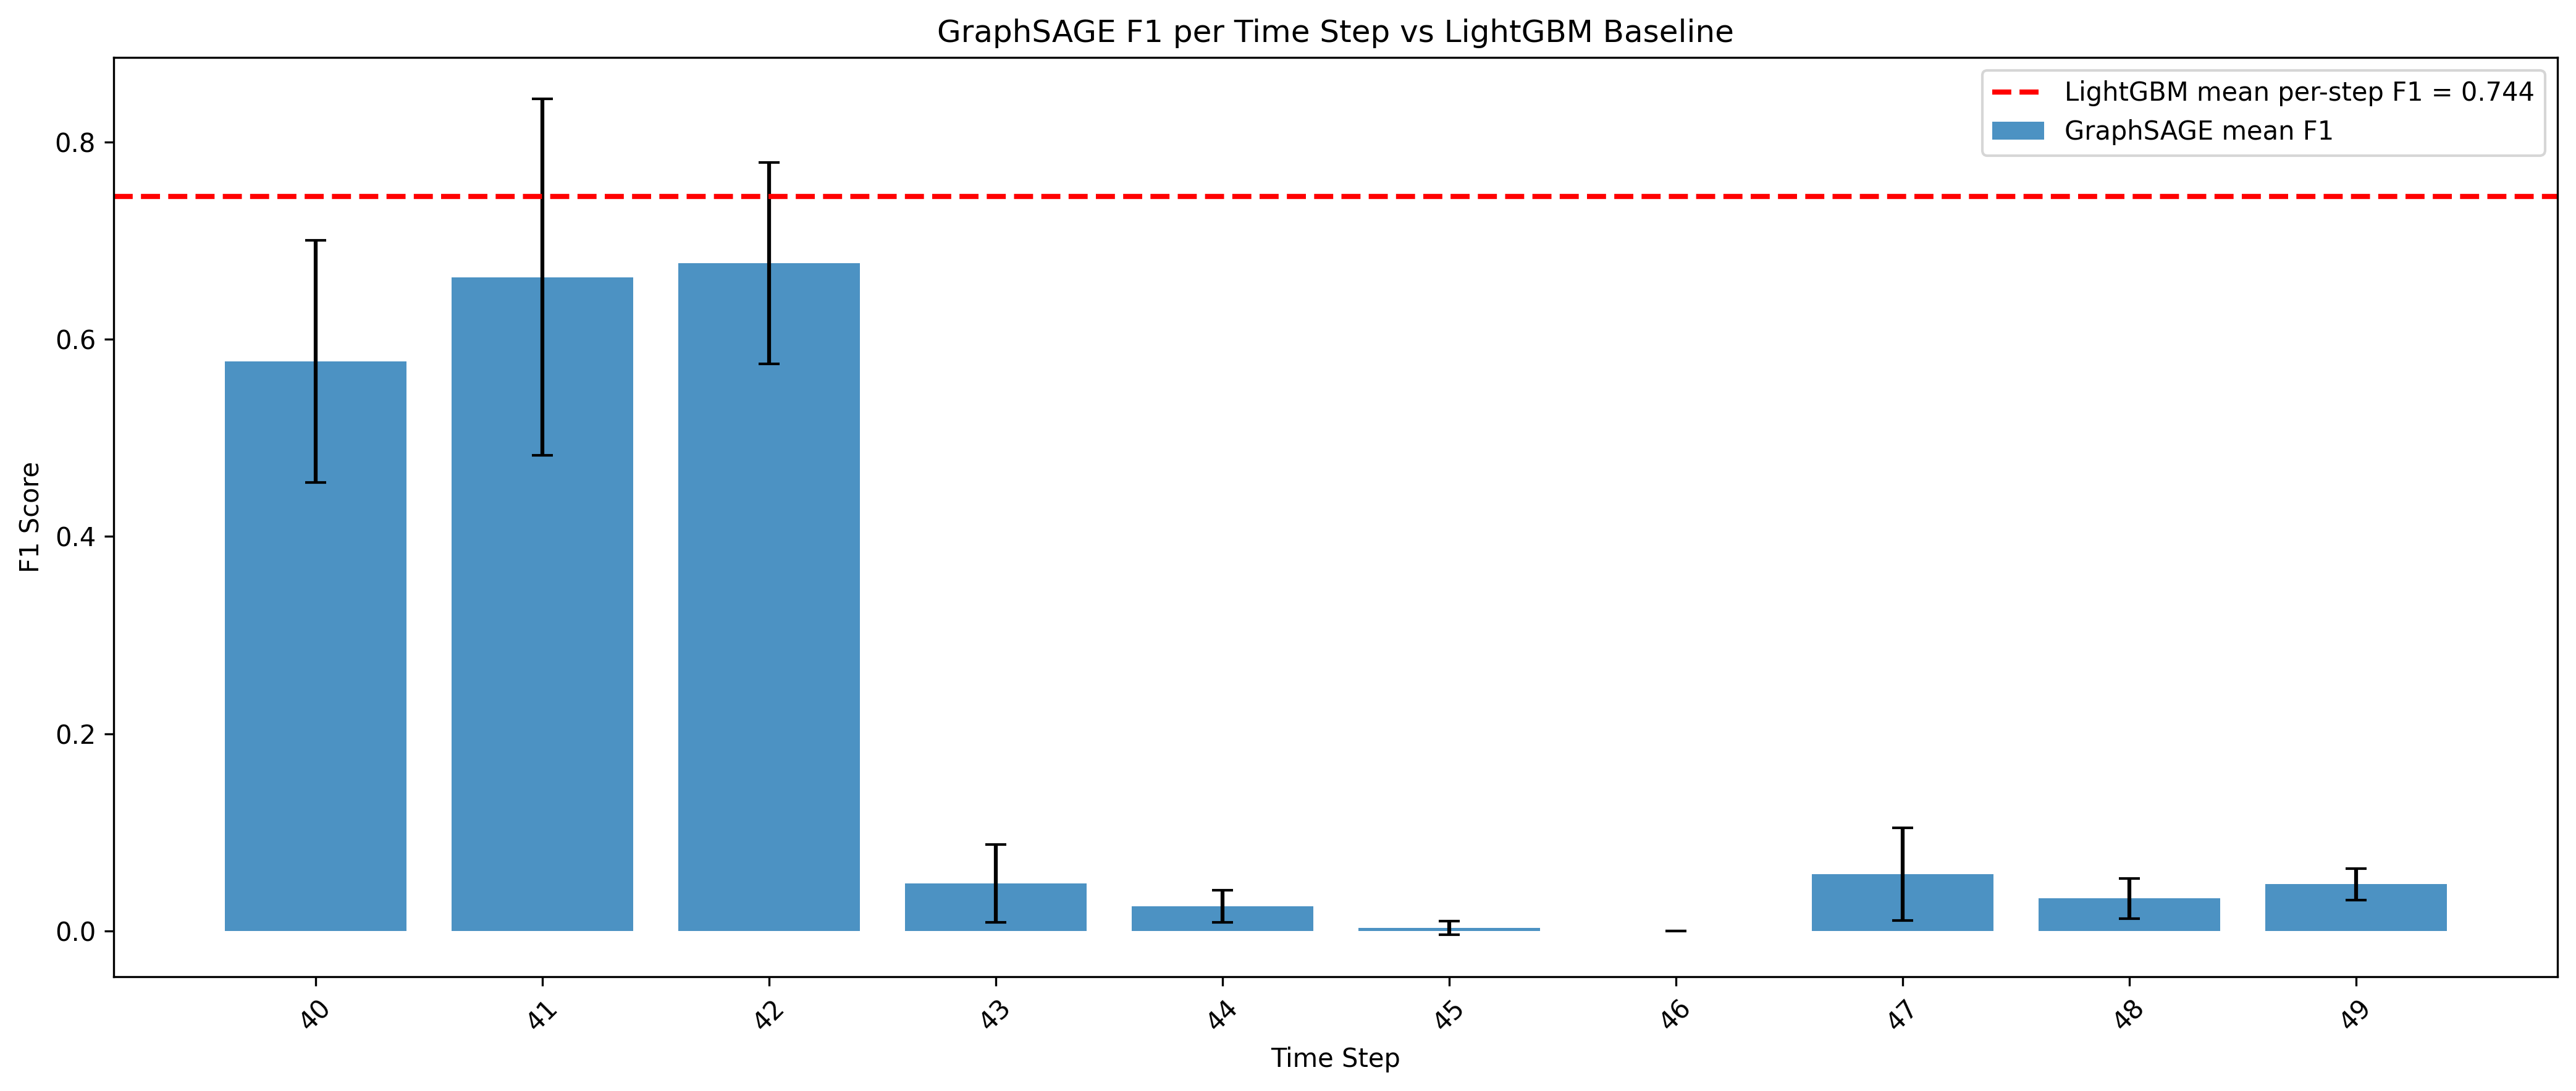

In [86]:
from IPython.display import Image, display

display(Image(
    filename= project_root / "models"/ "rq3_xai_models"/ "graphsage_f1_vs_lightgbm_baseline.png"
))

Three factors likely explain why graph models underperformed on this dataset. 

- First, the Elliptic++ feature set is **roughly half graph-based by construction**. Out of 182 features, 84 (46.2%) are aggregated neighbourhood features, including 72 anonymous **Aggregate_feature_*** columns and 12 named features describing one-hop incoming and outgoing Bitcoin flows and transaction counts. The remaining 93 features (51.1%) are local transaction-level features, together with 5 metadata columns.This means that the tree-based models are **already indirectly using graph information**, since many of the input features already describe neighbouring transactions. As a result, adding explicit graph message passing provides only limited additional information.

- Second, the transaction graph is very sparse. The labelled graph contains 202,804 nodes and only 233,283 edges, giving an average node degree of about 1.15. This means that many transactions have very few neighbours. Since graph neural networks rely on aggregating information from neighbouring nodes, the lack of connections limits their ability to learn useful relational patterns.

- Third, the graph becomes even smaller after step 43, which corresponds to the dark market shutdown. In several later time steps, there are fewer than 25 illicit transactions among 700–1,500 nodes. This increases the sparsity problem and makes it more difficult for dynamic graph models to learn meaningful temporal patterns.

Overall, feature-based models are more effective and more stable for AML detection on the Elliptic transaction dataset. Graph-based models capture some relational information but do not outperform the traditional approaches 
in this study. These aggregate results show *that* the two model families differ substantially in performance, but they do not explain *why* specifically, which features or graph patterns each model is using to make its decisions. This motivates the explainability analysis in Part 2.

## **PART 2 - Explainable AI**
---

### **Ethereum Fraud**
---

#### **LightGBM**

In [20]:
from src.xai import run_shap_lightgbm

eth_result_lgbm = run_shap_lightgbm(dataset="ethereum")

[LightGBM] [Info] Number of positive: 1325, number of negative: 6111
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001679 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4332
[LightGBM] [Info] Number of data points in the train set: 7436, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
=== LightGBM Balanced Metrics ===
    dataset              model  accuracy  precision    recall        f1  \
0  ethereum  LightGBM balanced  0.963959   0.925806  0.867069  0.895476   

    roc_auc  
0  0.988363  

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1528
           1       0.93      0.87      0.90       331

    accuracy                           0.96      1859
   macro avg       0.95      0.93      0.94    

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



SHAP LightGBM results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\lightgbm_shap_ethereum


In [4]:
from IPython.display import Image, display

# Path to SHAP results
eth_result_lgbm_dir = Path(
    "../models/rq3_xai_models/feature_models/lightgbm_shap_ethereum"
)

In [5]:
metrics = pd.read_csv(eth_result_lgbm_dir / "metrics.csv")

print("=== Metrics ===")
display(metrics)

=== Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,ethereum,LightGBM balanced,0.963959,0.925806,0.867069,0.895476,0.988363


In [6]:
feature_importance = pd.read_csv(
    eth_result_lgbm_dir / "shap_feature_importance.csv"
)

print("\n=== TOP SHAP FEATURES ===")
display(feature_importance.head(20))


=== TOP SHAP FEATURES ===


,feature,mean_abs_shap
0,avg_val_received,1.868586
1,Time_Diff_between_first_and_last_(Mins),1.316696
2,ERC20_max_val_rec,0.640543
3,Avg_min_between_received_tnx,0.538032
4,Avg_min_between_sent_tnx,0.514385
5,total_ether_received,0.489618
6,avg_val_sent,0.439295
7,total_ether_balance,0.408140
8,total_Ether_sent,0.401398
9,max_value_received,0.374649



=== SHAP SUMMARY BAR PLOT ===


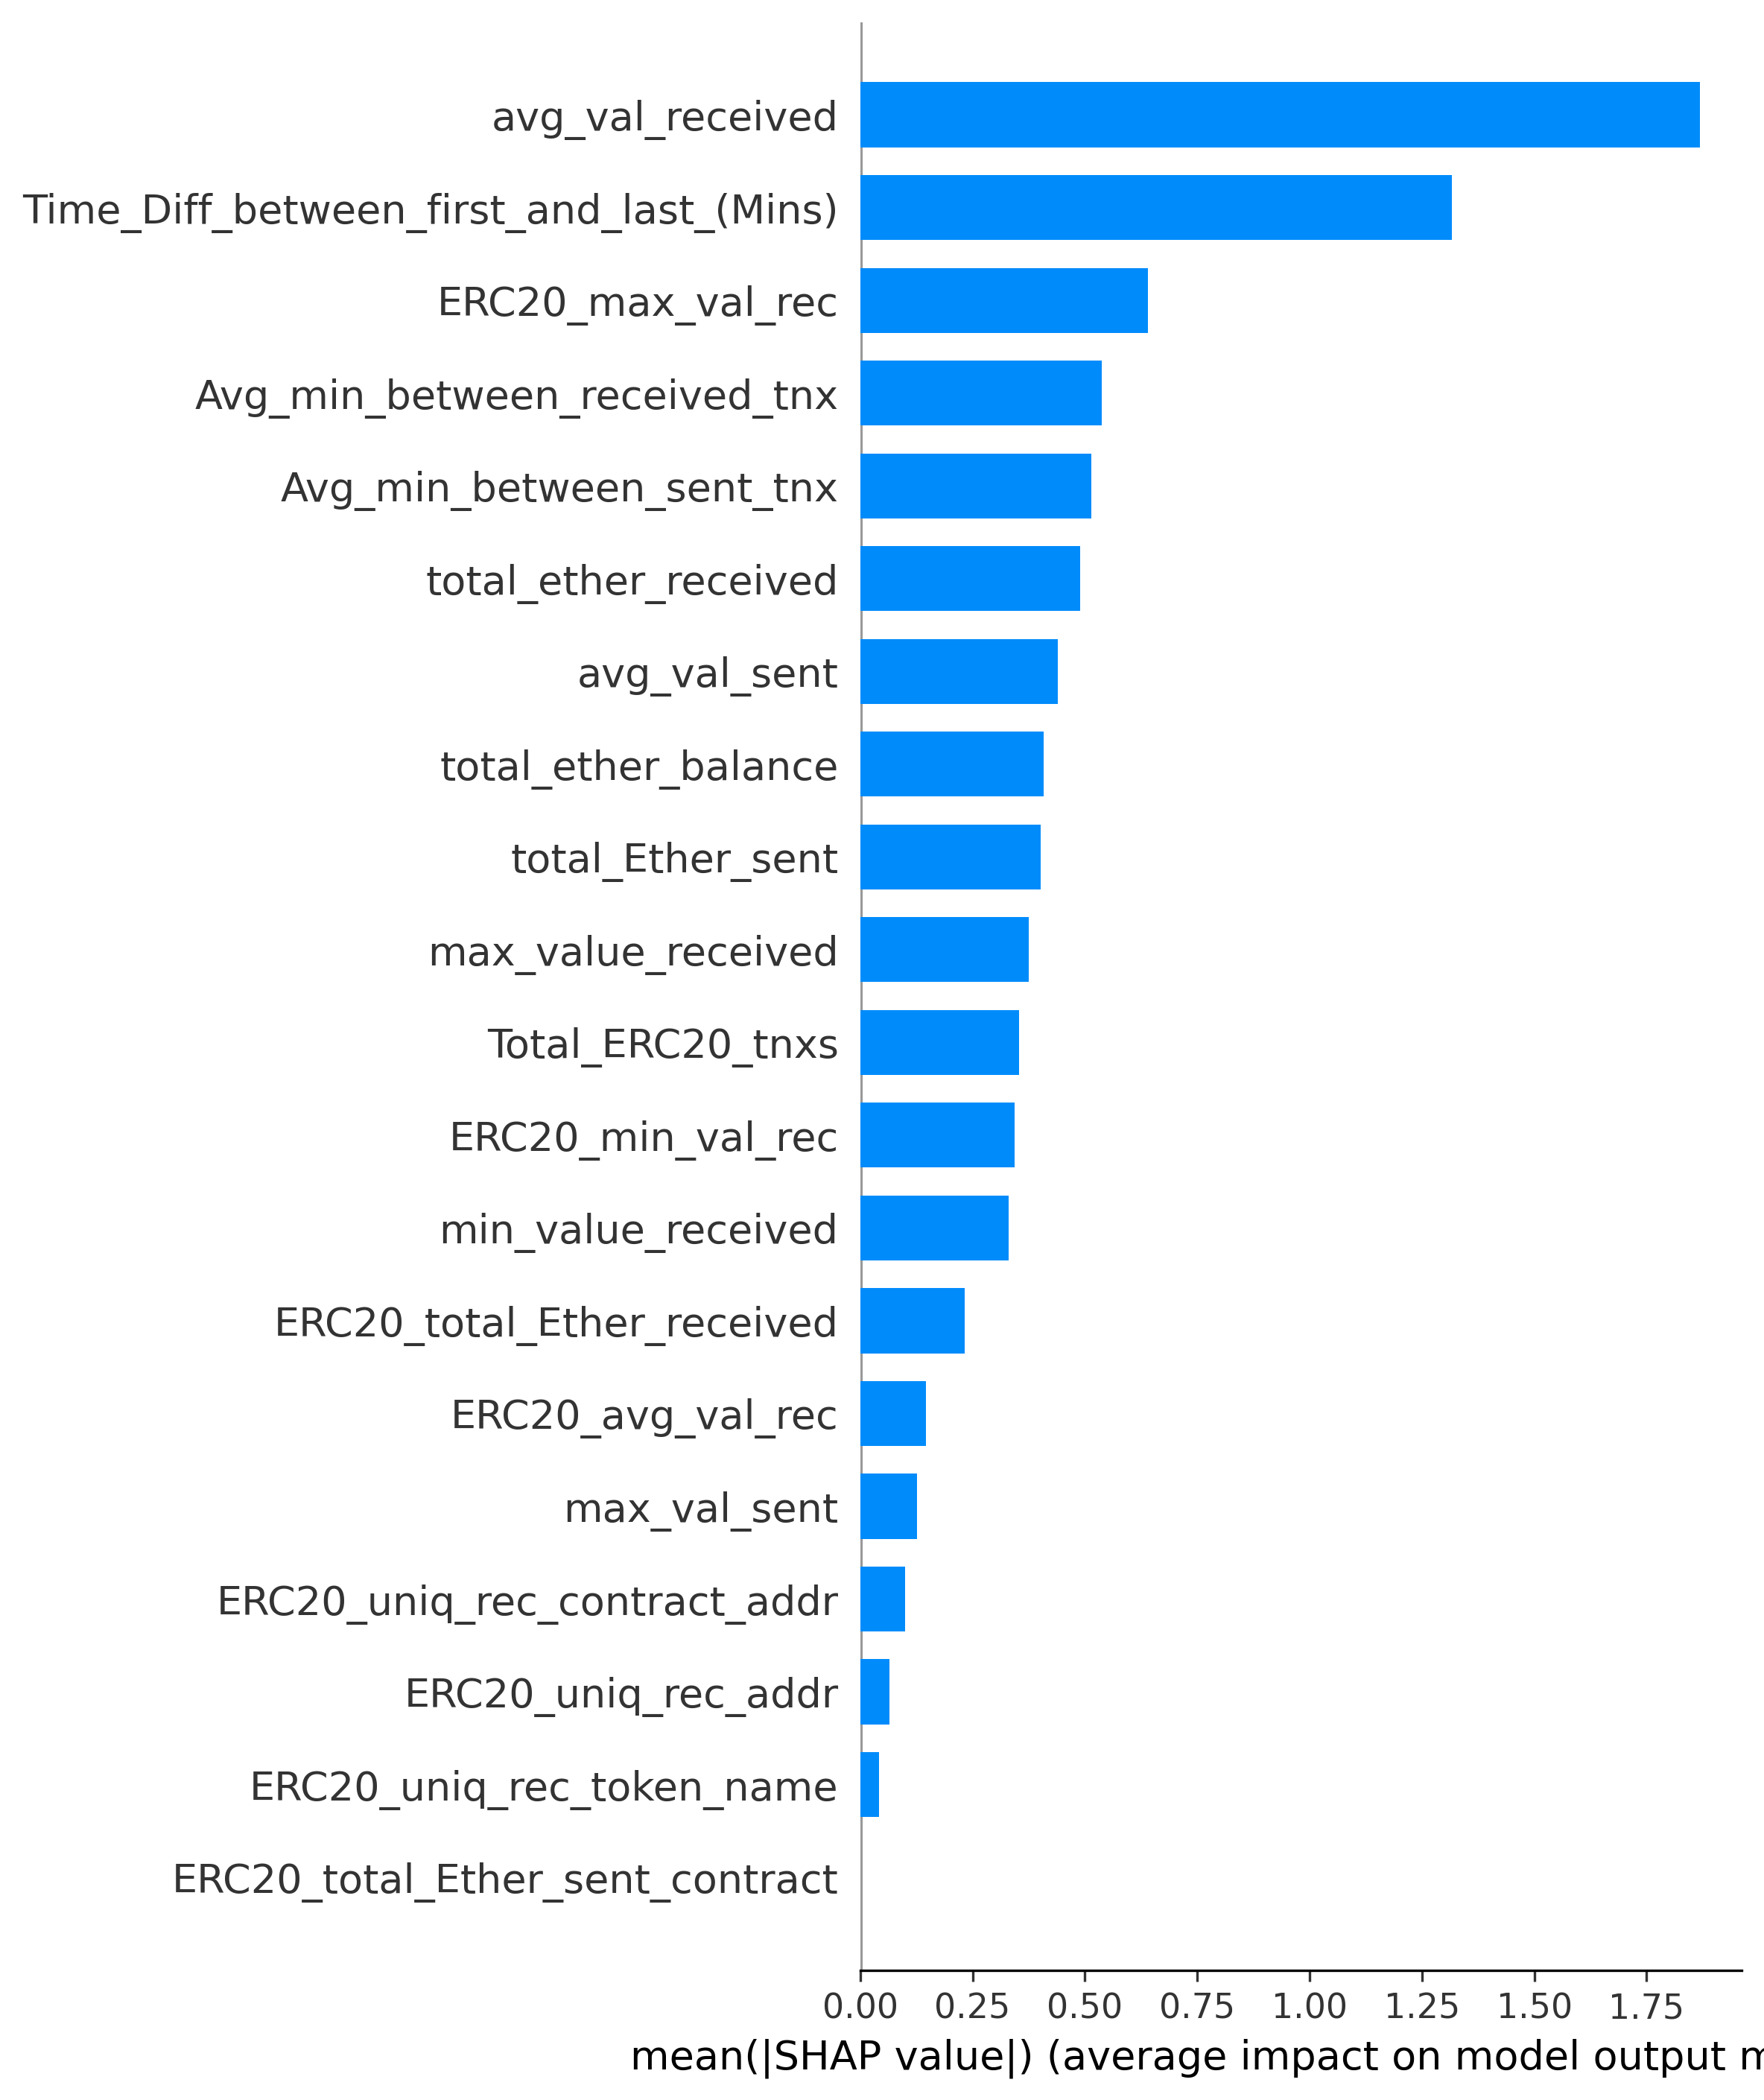

In [7]:
print("\n=== SHAP SUMMARY BAR PLOT ===")

display(
    Image(
        filename=str(eth_result_lgbm_dir / "shap_summary_bar.png")
    )
)

In [10]:
eth_lgbm_importance_df = pd.read_csv(project_root / "models"/ "rq3_xai_models"/ "feature_models"/ "lightgbm_shap_ethereum"/ "shap_feature_importance.csv")

def classify_eth_feature(feature):

    # Temporal
    if (
        "Time_Diff" in feature
        or "min_between" in feature
    ):
        return "Temporal"

    # ERC20 / Token activity
    elif feature.startswith("ERC20"):
        return "ERC20"

    # Behavioral / transaction statistics
    else:
        return "Behavioral"


eth_lgbm_importance_df["feature_group"] = (
    eth_lgbm_importance_df["feature"]
    .apply(classify_eth_feature)
)

group_importance = (
    eth_lgbm_importance_df
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .reset_index()
)

group_importance["relative_importance"] = (
    group_importance["mean_abs_shap"] /
    group_importance["mean_abs_shap"].sum()
)

group_importance

,feature_group,mean_abs_shap,relative_importance
0,Behavioral,4.791508,0.548842
1,ERC20,1.569588,0.179788
2,Temporal,2.369113,0.271370


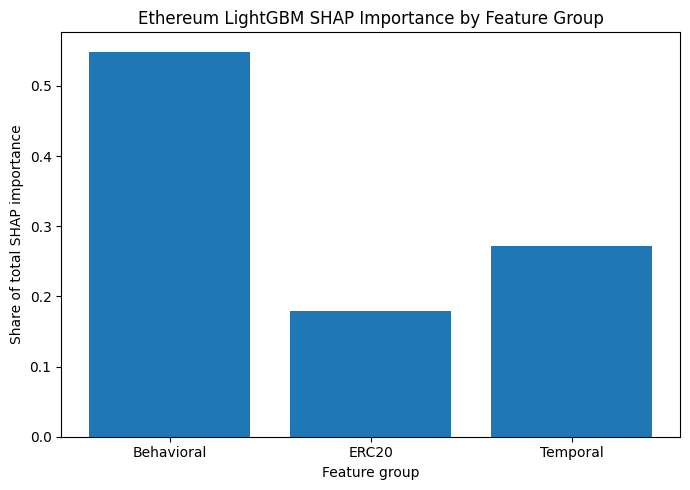

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    group_importance["feature_group"],
    group_importance["relative_importance"]
)

plt.ylabel("Share of total SHAP importance")
plt.xlabel("Feature group")

plt.title(
    "Ethereum LightGBM SHAP Importance by Feature Group"
)

plt.tight_layout()

plt.show()

In [21]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Get model and SHAP importance from your SHAP result
model = eth_result_lgbm["model"]
shap_importance = eth_result_lgbm["importance"].copy()

# Internal LightGBM feature importance
internal_importance = pd.DataFrame({
    "feature": eth_result_lgbm["X_explain"].columns,
    "lightgbm_internal_importance": model.feature_importances_
})

# Merge SHAP + internal LightGBM importance
comparison = shap_importance.merge(
    internal_importance,
    on="feature",
    how="inner"
)

# Add rankings
comparison["shap_rank"] = comparison["mean_abs_shap"].rank(
    ascending=False,
    method="min"
)

comparison["internal_rank"] = comparison["lightgbm_internal_importance"].rank(
    ascending=False,
    method="min"
)

comparison["rank_difference"] = (
    comparison["shap_rank"] - comparison["internal_rank"]
).abs()

comparison = comparison.sort_values("mean_abs_shap", ascending=False)

comparison.head(20)

,feature,mean_abs_shap,lightgbm_internal_importance,shap_rank,internal_rank,rank_difference
0,avg_val_received,1.868586,782,1.0,3.0,2.0
1,Time_Diff_between_first_and_last_(Mins),1.316696,1126,2.0,1.0,1.0
2,ERC20_max_val_rec,0.640543,358,3.0,11.0,8.0
3,Avg_min_between_received_tnx,0.538032,741,4.0,4.0,0.0
4,Avg_min_between_sent_tnx,0.514385,597,5.0,6.0,1.0
5,total_ether_received,0.489618,486,6.0,9.0,3.0
6,avg_val_sent,0.439295,524,7.0,8.0,1.0
7,total_ether_balance,0.408140,1038,8.0,2.0,6.0
8,total_Ether_sent,0.401398,300,9.0,14.0,5.0
9,max_value_received,0.374649,579,10.0,7.0,3.0


##### **Spearman correlation of Shap Feature Importance and Internal Model**
---

In [24]:
corr, p_value = spearmanr(
    comparison["mean_abs_shap"],
    comparison["lightgbm_internal_importance"]
)

print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.10e}")

Spearman correlation: 0.9004
P-value: 8.8168901975e-10


##### **Normalized comparison plot**
---

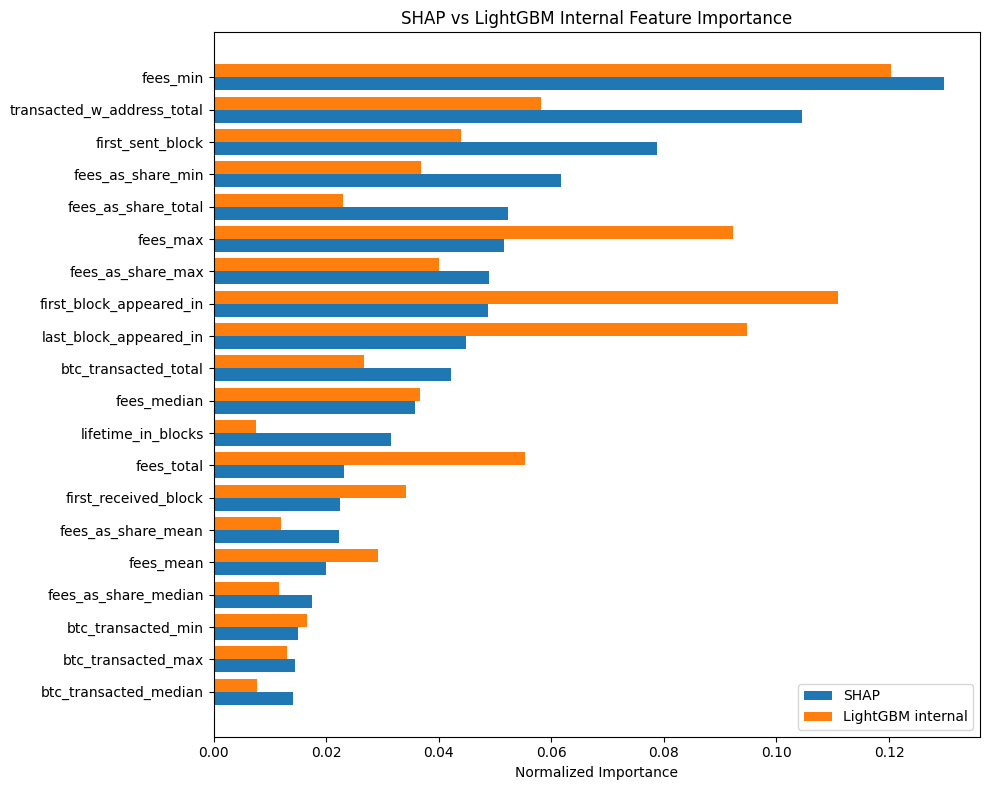

In [48]:
plot_df = comparison.copy()

# Normalize to percentage
plot_df["shap_norm"] = (
    plot_df["mean_abs_shap"] /
    plot_df["mean_abs_shap"].sum()
)

plot_df["lgbm_norm"] = (
    plot_df["lightgbm_internal_importance"] /
    plot_df["lightgbm_internal_importance"].sum()
)

top_n = 20
top = plot_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))

bar_width = 0.4
y_pos = range(len(top))

plt.barh(
    [y - bar_width/2 for y in y_pos],
    top["shap_norm"],
    height=bar_width,
    label="SHAP"
)

plt.barh(
    [y + bar_width/2 for y in y_pos],
    top["lgbm_norm"],
    height=bar_width,
    label="LightGBM internal"
)

plt.yticks(y_pos, top["feature"])

plt.xlabel("Normalized Importance")
plt.title("SHAP vs LightGBM Internal Feature Importance")
plt.legend()

plt.tight_layout()

save_dir = eth_result_lgbm["save_dir"]

plt.savefig(
    save_dir / "lightgbm_shap_vs_internal_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### **SHAP vs LightGBM internal importance**
---

As a validation step, the SHAP feature importance rankings were compared with LightGBM's built-in feature importance scores. The two rankings showed a strong agreement, with a **Spearman correlation of 0.90** (p < 0.001). This means that the features identified as important by SHAP were generally also considered important by the model itself.

Some differences between the rankings were still observed. For example, ***ERC20_max_val_rec*** was ranked much higher by SHAP, while ***total_ether_balance*** was ranked higher by LightGBM's internal importance. This is expected because the two methods measure importance differently. LightGBM's internal importance measures how often a feature is used in decision splits, while SHAP measures how much each feature actually contributes to the final prediction.

Overall, the high correlation gives additional confidence that the SHAP explanations reflect the real behaviour of the model and are not simply artefacts of the explanation method.

---
---


=== SHAP BEESWARM PLOT ===


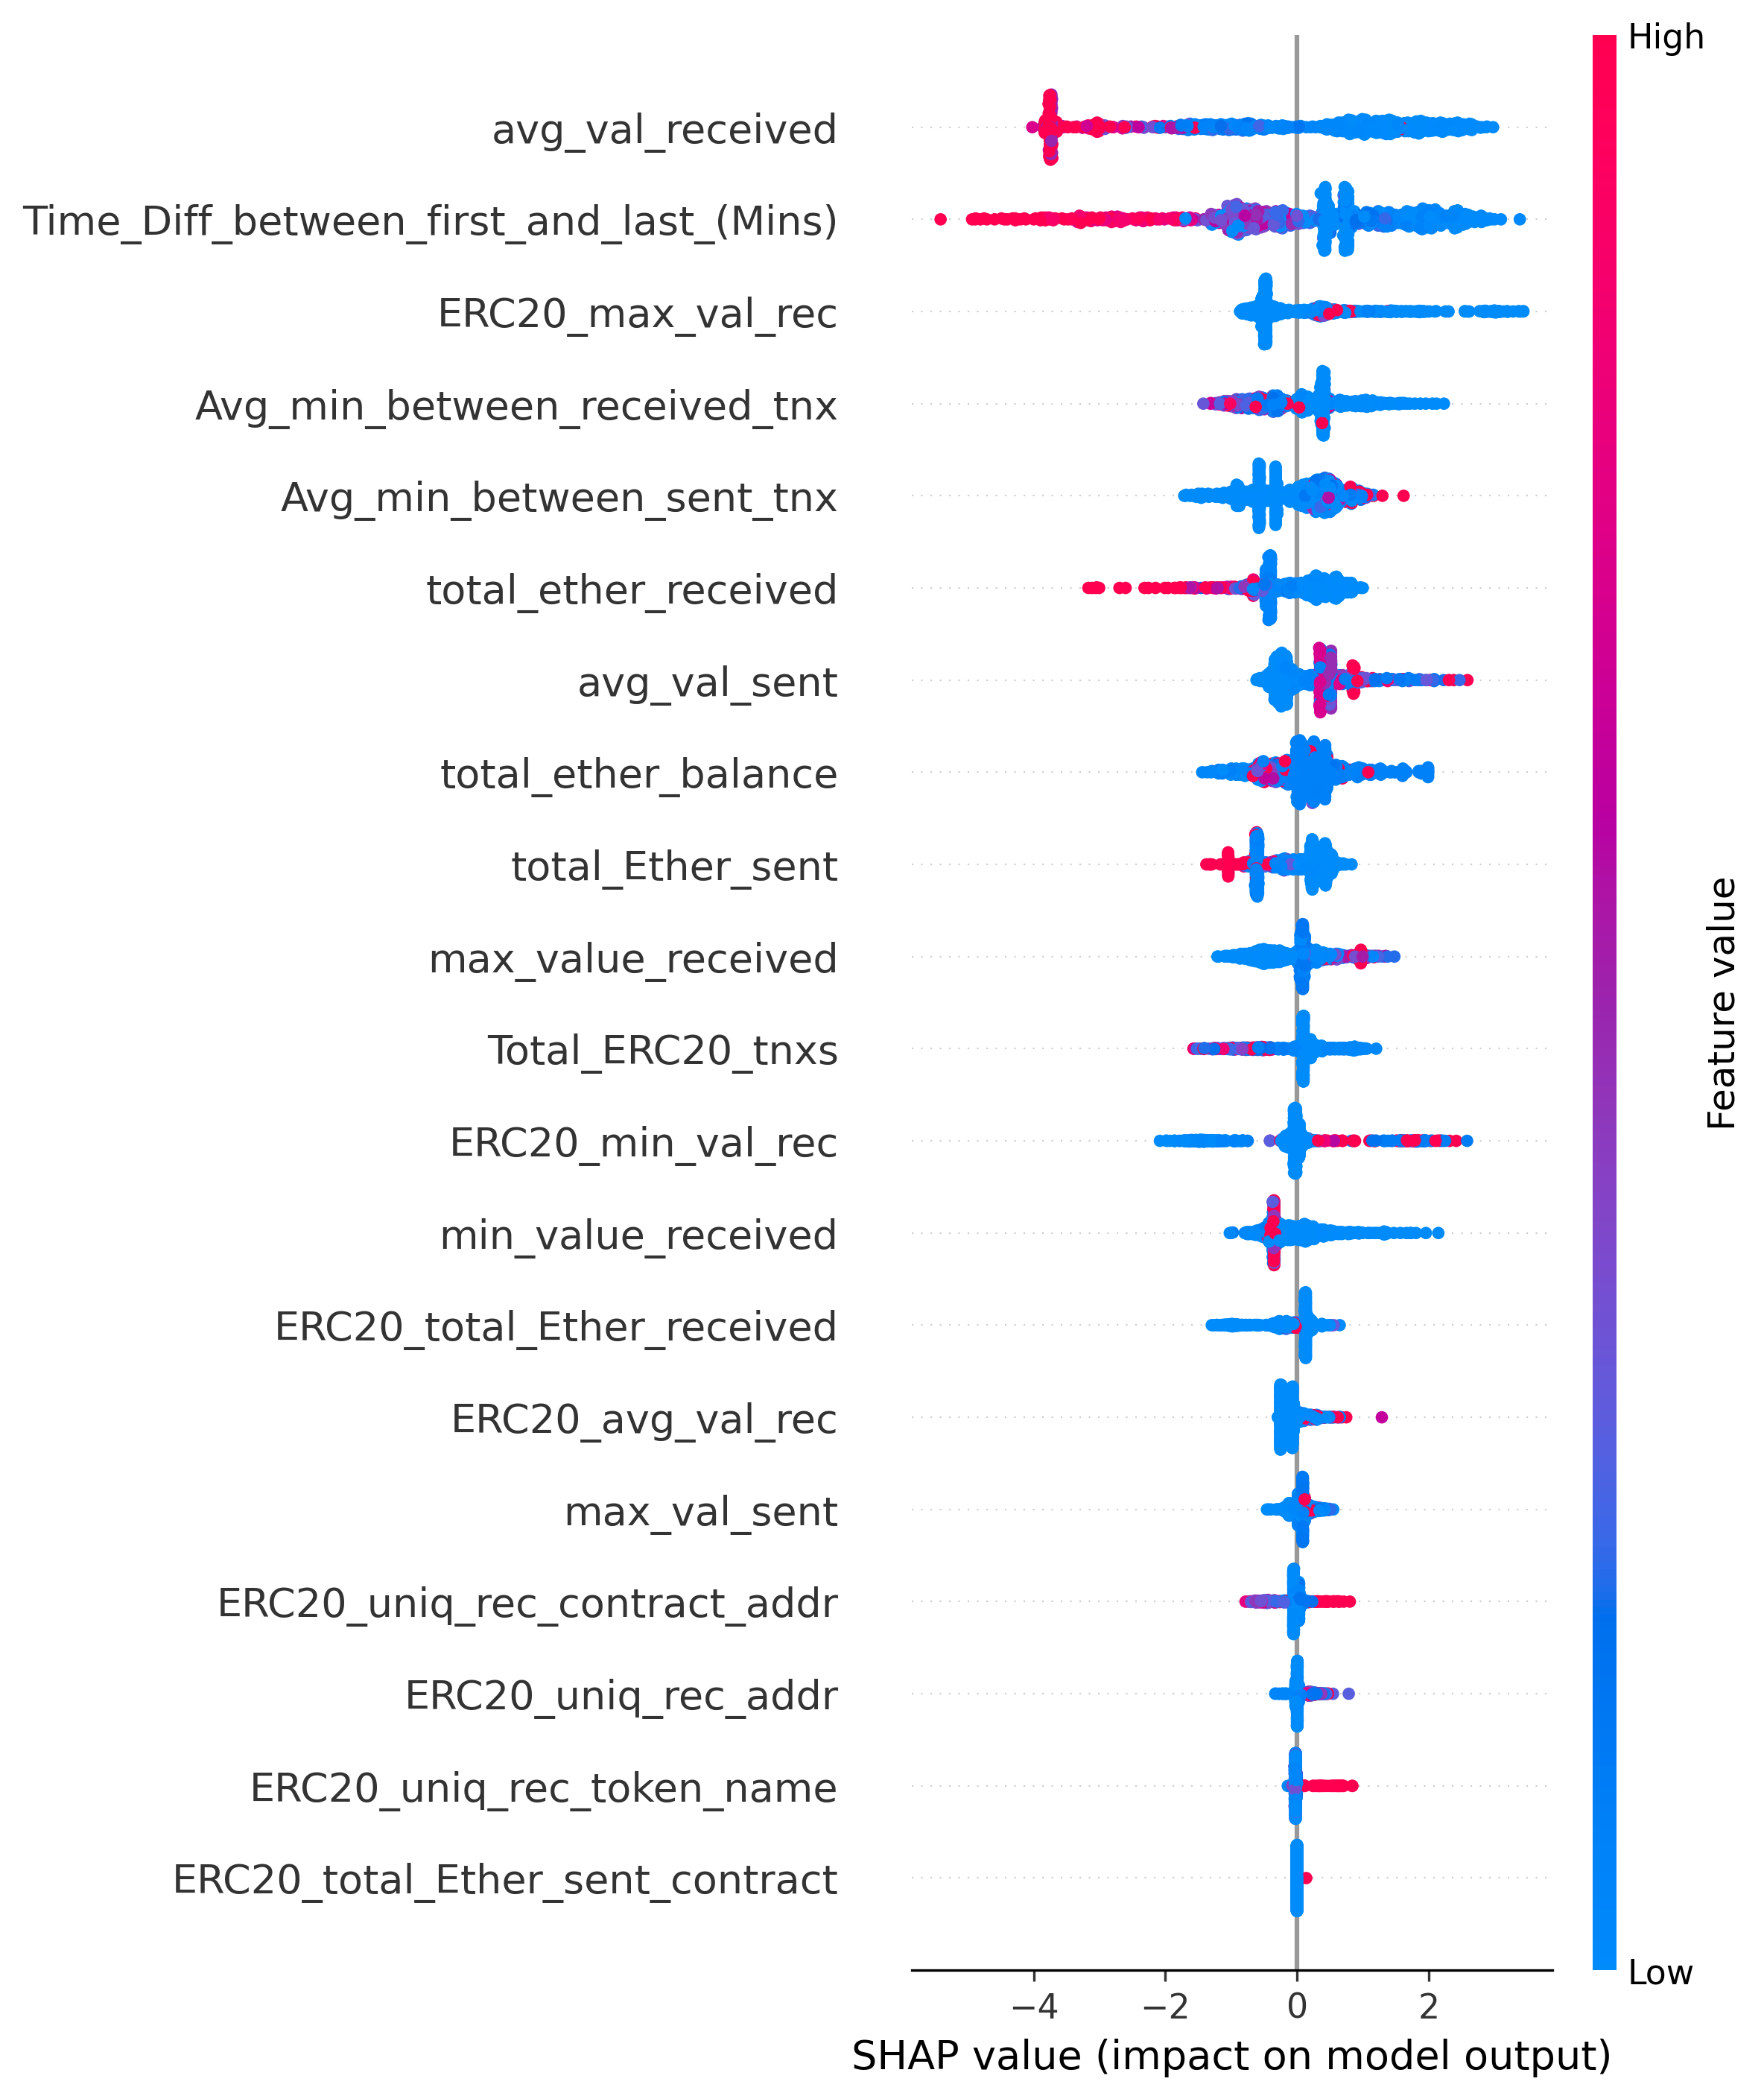

In [8]:
print("\n=== SHAP BEESWARM PLOT ===")

display(
    Image(
        filename=str(eth_result_lgbm_dir / "shap_beeswarm.png")
    )
)

##### **Ethereum - LightGBM (balanced)**
---

LightGBM was the best-performing model on the Ethereum dataset in RQ1, achieving an **F1-score of 0.895** and a **ROC-AUC of 0.988**. Because of this strong performance, the SHAP explanations provide a reliable view of which wallet features are most important for fraud detection.

The SHAP results show that the model mainly relies on **behavioural and temporal features** rather than only transaction amounts. The most important feature was ***avg_val_received***, meaning that wallets receiving unusually large average payments were more likely to be classified as fraudulent.

Other important features were related to **wallet activity over time**, such as:
- ***Time_Diff_between_first_and_last_(Mins)***
- ***Avg_min_between_received_tnx***
- ***Avg_min_between_sent_tnx***

The beeswarm plot shows that:
- wallets with large average received values are pushed towards the **illicit** class,
- wallets active for a long time are pushed towards the **licit** class,
- short transaction intervals are more associated with **fraudulent behaviour**.

Overall, the SHAP analysis suggests that LightGBM detects fraudulent Ethereum wallets mainly through **behavioural patterns**, such as large incoming payments, short wallet lifetimes, and burst-like transaction activity, rather than total wallet balance alone.

#### **Random Forest**

In [26]:
from src.xai import run_shap_random_forest

eth_result_rf = run_shap_random_forest(dataset="ethereum")

=== Random Forest Balanced Metrics ===
    dataset                   model  accuracy  precision    recall        f1  \
0  ethereum  Random Forest balanced  0.948359   0.946768  0.752266  0.838384   

    roc_auc  
0  0.981206  

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1528
           1       0.95      0.75      0.84       331

    accuracy                           0.95      1859
   macro avg       0.95      0.87      0.90      1859
weighted avg       0.95      0.95      0.95      1859


SHAP Random Forest results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\random_forest_shap_ethereum


In [7]:
from IPython.display import Image, display

# Path to SHAP results
eth_result_rf_dir = Path(
    "../models/rq3_xai_models/feature_models/random_forest_shap_ethereum"
)

In [8]:
metrics = pd.read_csv(eth_result_rf_dir / "metrics.csv")

print("=== Metrics ===")
display(metrics)

=== Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,ethereum,Random Forest balanced,0.948359,0.946768,0.752266,0.838384,0.981206


In [9]:
feature_importance = pd.read_csv(
    eth_result_rf_dir / "shap_feature_importance.csv"
)

print("\n=== TOP SHAP FEATURES ===")
display(feature_importance.head(20))


=== TOP SHAP FEATURES ===


,feature,mean_abs_shap
0,Time_Diff_between_first_and_last_(Mins),0.076958
1,Avg_min_between_received_tnx,0.055720
2,avg_val_received,0.054279
3,total_ether_received,0.044380
4,ERC20_max_val_rec,0.034755
5,ERC20_min_val_rec,0.031761
6,min_value_received,0.030916
7,total_Ether_sent,0.026949
8,max_value_received,0.026721
9,total_ether_balance,0.025190



=== SHAP SUMMARY BAR PLOT ===


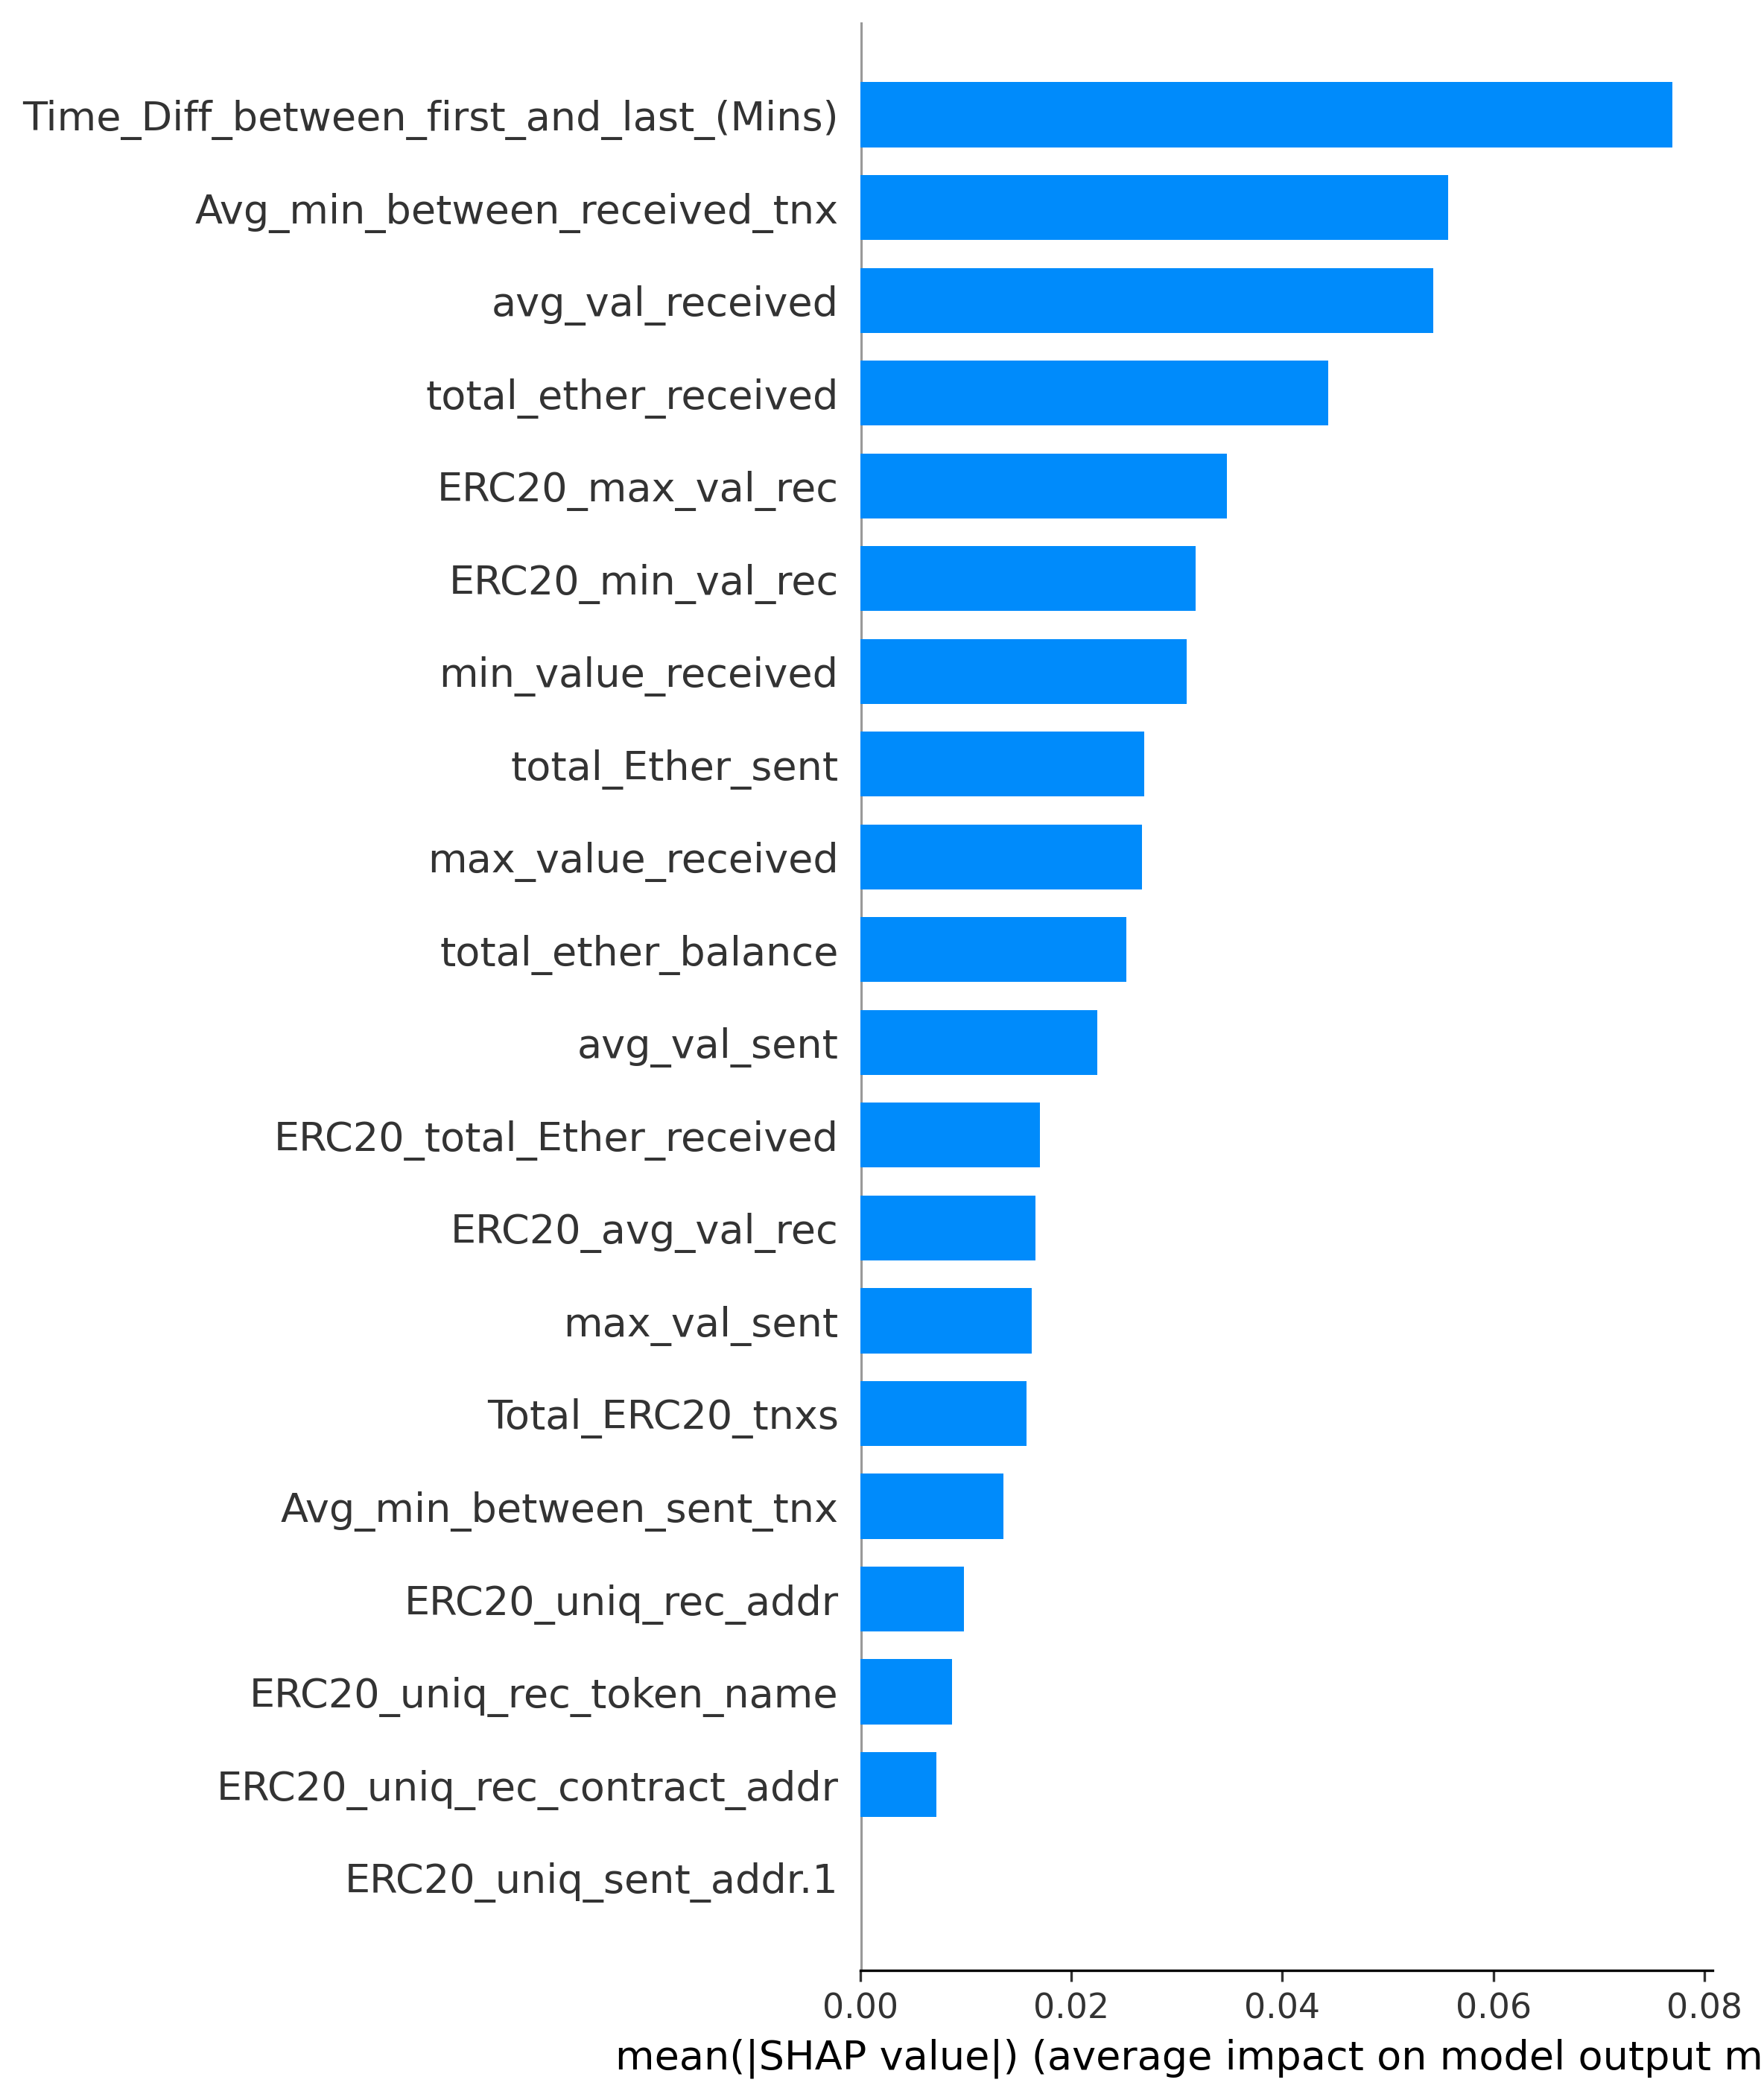

In [10]:
print("\n=== SHAP SUMMARY BAR PLOT ===")

display(
    Image(
        filename=str(eth_result_rf_dir / "shap_summary_bar.png")
    )
)

In [16]:
eth_rf_importance_df = pd.read_csv(project_root / "models"/ "rq3_xai_models"/ "feature_models"/ "random_forest_shap_ethereum"/ "shap_feature_importance.csv")

def classify_eth_feature(feature):

    # Temporal
    if (
        "Time_Diff" in feature
        or "min_between" in feature
    ):
        return "Temporal"

    # ERC20 / Token activity
    elif feature.startswith("ERC20"):
        return "ERC20"

    # Behavioral / transaction statistics
    else:
        return "Behavioral"


eth_rf_importance_df["feature_group"] = (
    eth_rf_importance_df["feature"]
    .apply(classify_eth_feature)
)

eth_group_importance_rf = (
    eth_rf_importance_df
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .reset_index()
)

eth_group_importance_rf["relative_importance"] = (
    eth_group_importance_rf["mean_abs_shap"] /
    eth_group_importance_rf["mean_abs_shap"].sum()
)

eth_group_importance_rf

,feature_group,mean_abs_shap,relative_importance
0,Behavioral,0.262900,0.491349
1,ERC20,0.125911,0.235322
2,Temporal,0.146246,0.273328


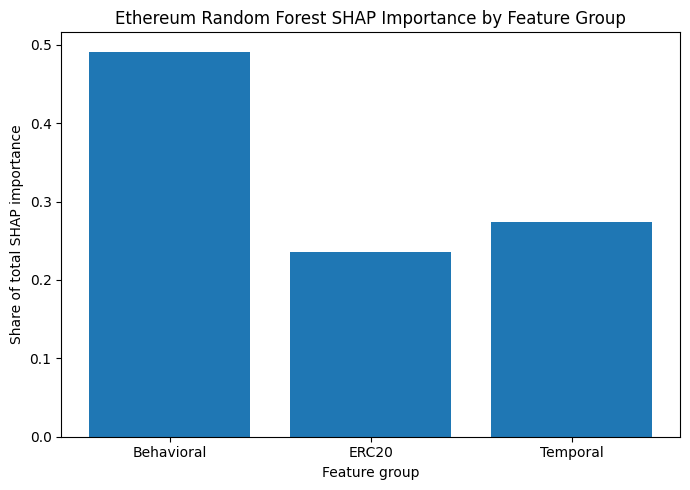

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    eth_group_importance_rf["feature_group"],
    eth_group_importance_rf["relative_importance"]
)

plt.ylabel("Share of total SHAP importance")
plt.xlabel("Feature group")

plt.title(
    "Ethereum Random Forest SHAP Importance by Feature Group"
)

plt.tight_layout()

plt.show()

In [58]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Get model + SHAP importance
model = eth_result_rf["model"]
shap_importance = eth_result_rf["importance"].copy()

# Random Forest internal importance
internal_importance = pd.DataFrame({
    "feature": eth_result_rf["X_explain"].columns,
    "rf_internal_importance": model.feature_importances_
})

# Merge
comparison_rf = shap_importance.merge(
    internal_importance,
    on="feature",
    how="inner"
)

# Rankings
comparison_rf["shap_rank"] = comparison_rf["mean_abs_shap"].rank(
    ascending=False,
    method="min"
)

comparison_rf["rf_rank"] = comparison_rf["rf_internal_importance"].rank(
    ascending=False,
    method="min"
)

comparison_rf["rank_difference"] = (
    comparison_rf["shap_rank"] - comparison_rf["rf_rank"]
).abs()

# Sort
comparison_rf = comparison_rf.sort_values(
    "mean_abs_shap",
    ascending=False
)

comparison_rf.head(20)

,feature,mean_abs_shap,rf_internal_importance,shap_rank,rf_rank,rank_difference
0,Time_Diff_between_first_and_last_(Mins),0.076958,0.155505,1.0,1.0,0.0
1,Avg_min_between_received_tnx,0.055720,0.092426,2.0,3.0,1.0
2,avg_val_received,0.054279,0.090555,3.0,4.0,1.0
3,total_ether_received,0.044380,0.095366,4.0,2.0,2.0
4,ERC20_max_val_rec,0.034755,0.031427,5.0,13.0,8.0
5,ERC20_min_val_rec,0.031761,0.047925,6.0,9.0,3.0
6,min_value_received,0.030916,0.061093,7.0,7.0,0.0
7,total_Ether_sent,0.026949,0.061011,8.0,8.0,0.0
8,max_value_received,0.026721,0.069324,9.0,5.0,4.0
9,total_ether_balance,0.025190,0.063932,10.0,6.0,4.0


##### **Spearman correlation of Shap Feature Importance and Internal Model**
---

In [59]:
corr, p_value = spearmanr(
    comparison_rf["mean_abs_shap"],
    comparison_rf["rf_internal_importance"]
)

print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.10e}")

Spearman correlation: 0.9377
P-value: 4.8188683346e-12


##### **Normalized comparison plot**
---

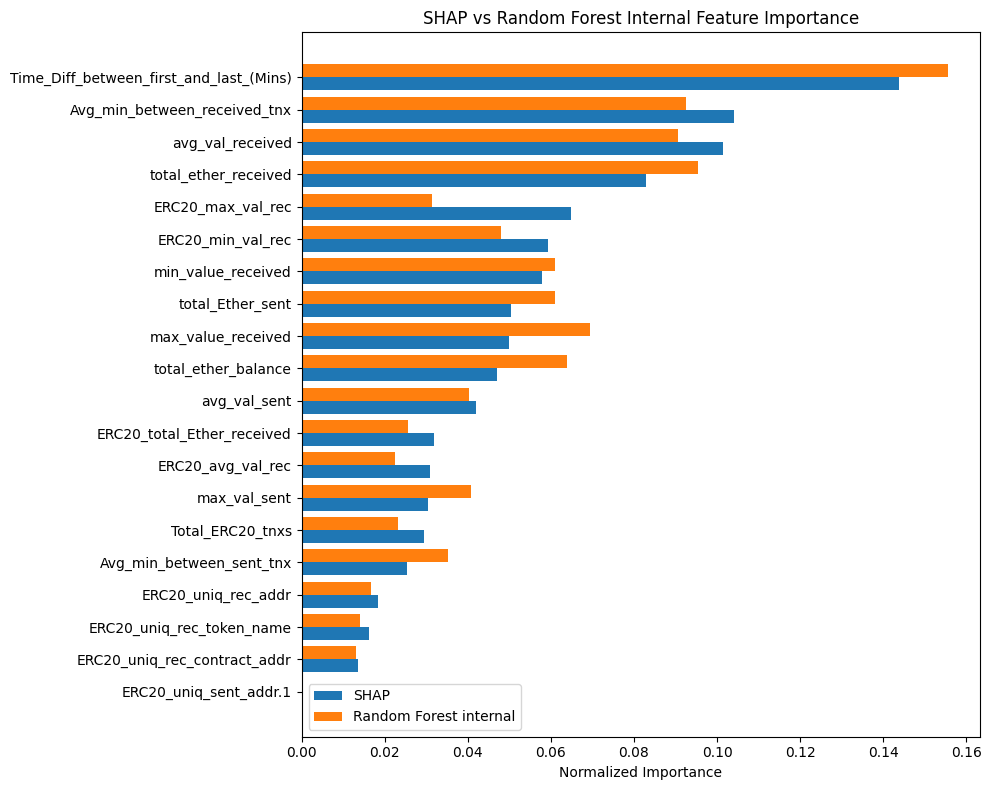

In [60]:
plot_df = comparison_rf.copy()

# Normalize
plot_df["shap_norm"] = (
    plot_df["mean_abs_shap"] /
    plot_df["mean_abs_shap"].sum()
)

plot_df["rf_norm"] = (
    plot_df["rf_internal_importance"] /
    plot_df["rf_internal_importance"].sum()
)

top_n = 20
top = plot_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))

bar_width = 0.4
y_pos = range(len(top))

# SHAP bars
plt.barh(
    [y - bar_width/2 for y in y_pos],
    top["shap_norm"],
    height=bar_width,
    label="SHAP"
)

# RF internal bars
plt.barh(
    [y + bar_width/2 for y in y_pos],
    top["rf_norm"],
    height=bar_width,
    label="Random Forest internal"
)

plt.yticks(y_pos, top["feature"])

plt.xlabel("Normalized Importance")
plt.title("SHAP vs Random Forest Internal Feature Importance")
plt.legend()

plt.tight_layout()

save_dir = eth_result_rf["save_dir"]

plt.savefig(
    save_dir / "rf_shap_vs_internal_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### **SHAP vs Random Forest internal importance**
---

The same validation check was performed for Random Forest. The SHAP feature importance rankings and the model's built-in feature importance showed a very strong agreement, with a **Spearman correlation of 0.94** (p < 0.001). This agreement was even slightly stronger than the LightGBM comparison.

The top feature, ***Time_Diff_between_first_and_last_(Mins)***, was ranked first by both methods. Most other features also appeared in very similar positions in both rankings.

Some small differences were still observed. For example, ***ERC20_max_val_rec*** was ranked higher by SHAP than by the internal importance scores. This is expected because the two methods calculate importance differently. Random Forest's internal importance measures how often a feature is used across the decision trees, while SHAP measures how strongly the feature contributes to the final predictions.

Overall, the high correlation confirms that the SHAP explanations are consistent with the internal behaviour of the Random Forest model.

---
---


=== SHAP BEESWARM PLOT ===


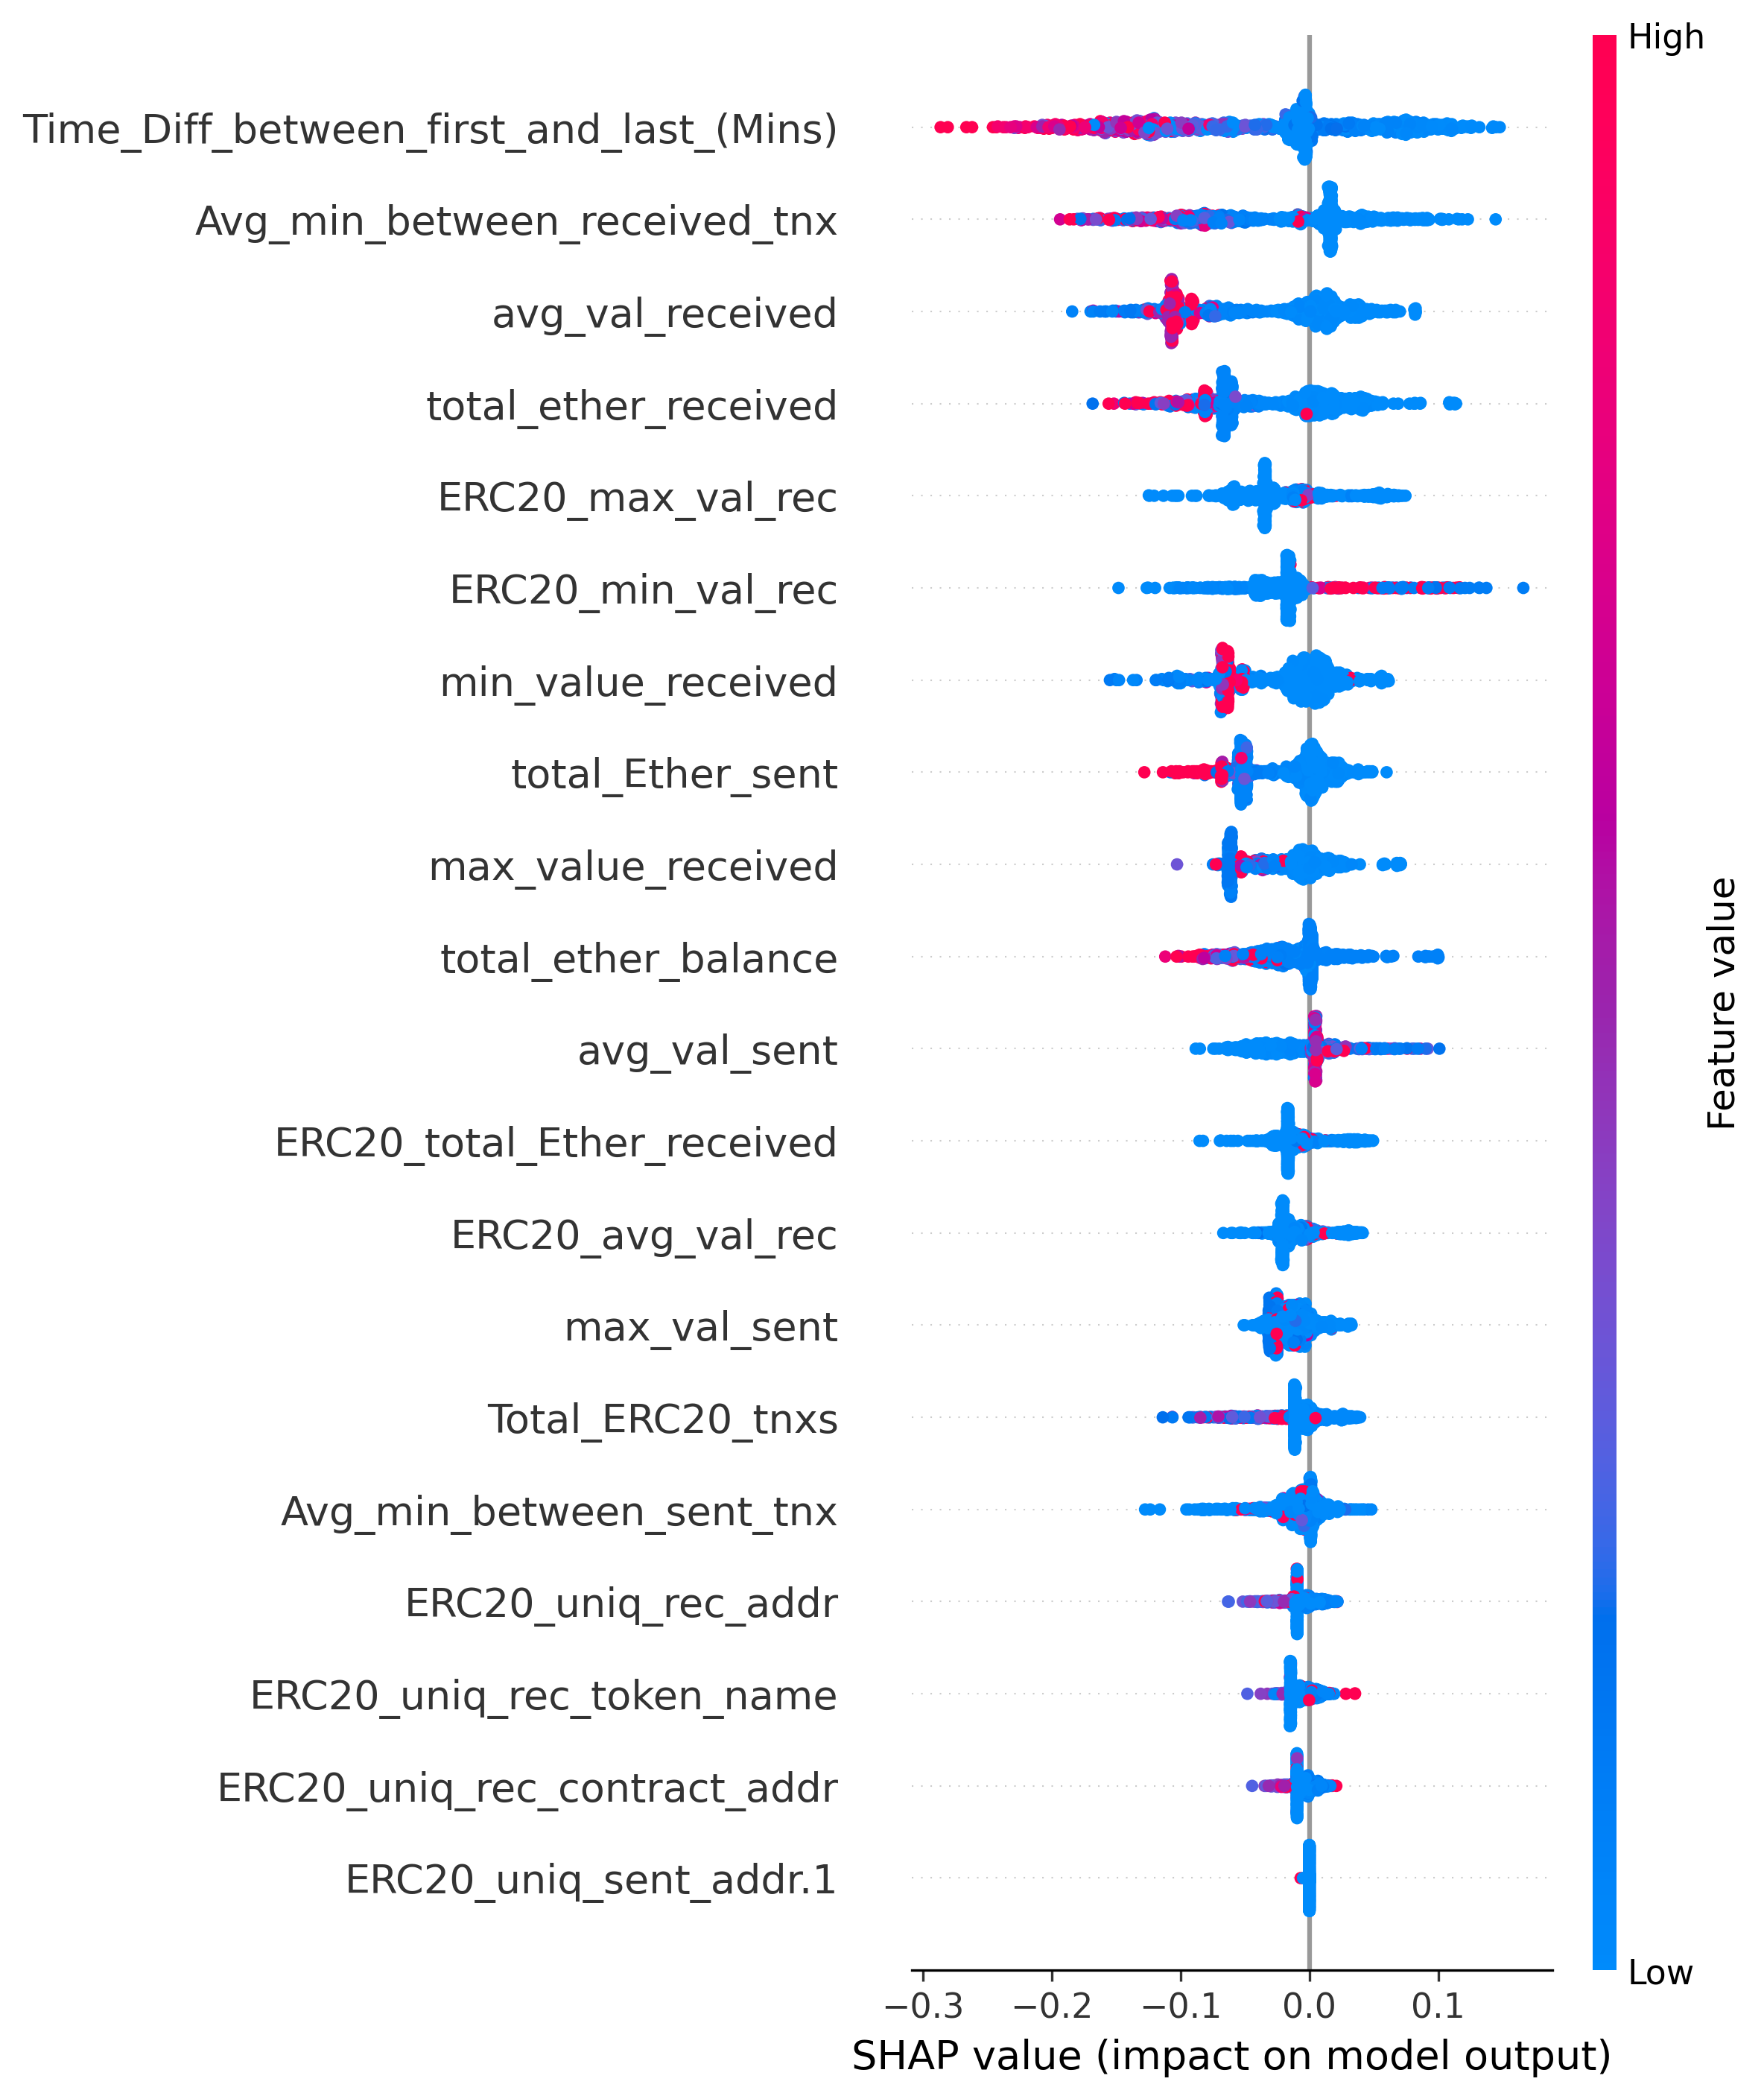

In [12]:
print("\n=== SHAP BEESWARM PLOT ===")

display(
    Image(
        filename=str(eth_result_rf_dir / "shap_beeswarm.png")
    )
)

##### **Ethereum - Random Forest (balanced)**
---

The Random Forest model achieved an **F1-score of 0.838** and a **ROC-AUC of 0.981** on the Ethereum dataset, slightly lower than LightGBM. The SHAP analysis shows that both models rely on many of the same important features, but they use them differently.

The most important Random Forest features were:
- ***Time_Diff_between_first_and_last_(Mins)***
- ***Avg_min_between_received_tnx***
- ***avg_val_received***
- ***total_ether_received***

These features also appeared among the most important features in LightGBM. However, Random Forest considered wallet lifetime more important, while LightGBM relied more heavily on the average value received by a wallet.

The SHAP values also show that Random Forest spreads importance across more features, while LightGBM focuses strongly on a smaller number of highly important features. This difference comes from how the models work. Random Forest combines many decision trees, leading to more balanced feature importance, while LightGBM focuses more strongly on the most discriminative patterns.

The beeswarm plot confirms similar behavioural patterns to LightGBM:
- long-lived wallets are more likely to be classified as **licit**,
- short transaction intervals are more associated with **fraudulent activity**,
- large average received values increase the likelihood of being classified as **illicit**.

Overall, both models detect Ethereum fraud using similar behavioural signals, but LightGBM makes stronger and more focused decisions, while Random Forest distributes importance more evenly across multiple features.

#### **Ethereum Fraud - XAI Discussion**
---

Comparing the two models on the Ethereum dataset shows that they identify very similar fraud patterns. Both LightGBM and Random Forest rank the same main features among the most important ones, including:
- **Time_Diff_between_first_and_last_(Mins)**
- **avg_val_received**
- **Avg_min_between_received_tnx**
- **total_ether_received**

Both models show that behavioural and temporal features are more useful for fraud detection than wallet balance or ERC20 activity. They also identify similar suspicious patterns, such as short wallet lifetimes, unusually large received payments, and burst-like transaction activity.

The main difference is how strongly each model relies on these features. LightGBM focuses more heavily on a small number of highly important features, especially **avg_val_received**, while Random Forest spreads importance more evenly across several features and gives more importance to wallet lifetime.

This agreement between two different models suggests that these fraud signals are reliable and not caused by a specific model. The slightly better performance of LightGBM likely comes from its ability to focus more strongly on the most discriminative features, while Random Forest produces more balanced and stable explanations.

---
---

### **Elliptic-wallets-combined**
---

#### **LightGBM**

In [32]:
from src.xai import run_shap_lightgbm

wallets_result_lgbm = run_shap_lightgbm(dataset="elliptic-wallets-combined")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11463, number of negative: 183084
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11865
[LightGBM] [Info] Number of data points in the train set: 194547, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
=== LightGBM Balanced Metrics ===
                     dataset              model  accuracy  precision  \
0  elliptic-wallets-combined  LightGBM balanced  0.961655   0.392832   

     recall        f1   roc_auc  
0  0.890837  0.545233  0.985087  

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     47382
           1       0.39      0.89   

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



SHAP LightGBM results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\lightgbm_shap_elliptic-wallets-combined


In [14]:
from IPython.display import Image, display

# Path to SHAP results
wallets_results_lgbm_dir = Path(
    "../models/rq3_xai_models/feature_models/lightgbm_shap_elliptic-wallets-combined"
)

In [15]:
metrics = pd.read_csv(wallets_results_lgbm_dir / "metrics.csv")

print("=== Metrics ===")
display(metrics)

=== Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,LightGBM balanced,0.961655,0.392832,0.890837,0.545233,0.985087


In [16]:
feature_importance = pd.read_csv(
    wallets_results_lgbm_dir / "shap_feature_importance.csv"
)

print("\n=== TOP SHAP FEATURES ===")
display(feature_importance.head(20))


=== TOP SHAP FEATURES ===


,feature,mean_abs_shap
0,fees_min,0.707626
1,transacted_w_address_total,0.570721
2,first_sent_block,0.430343
3,fees_as_share_min,0.336414
4,fees_as_share_total,0.285216
5,fees_max,0.281851
6,fees_as_share_max,0.266614
7,first_block_appeared_in,0.266022
8,last_block_appeared_in,0.244514
9,btc_transacted_total,0.229708



=== SHAP SUMMARY BAR PLOT ===


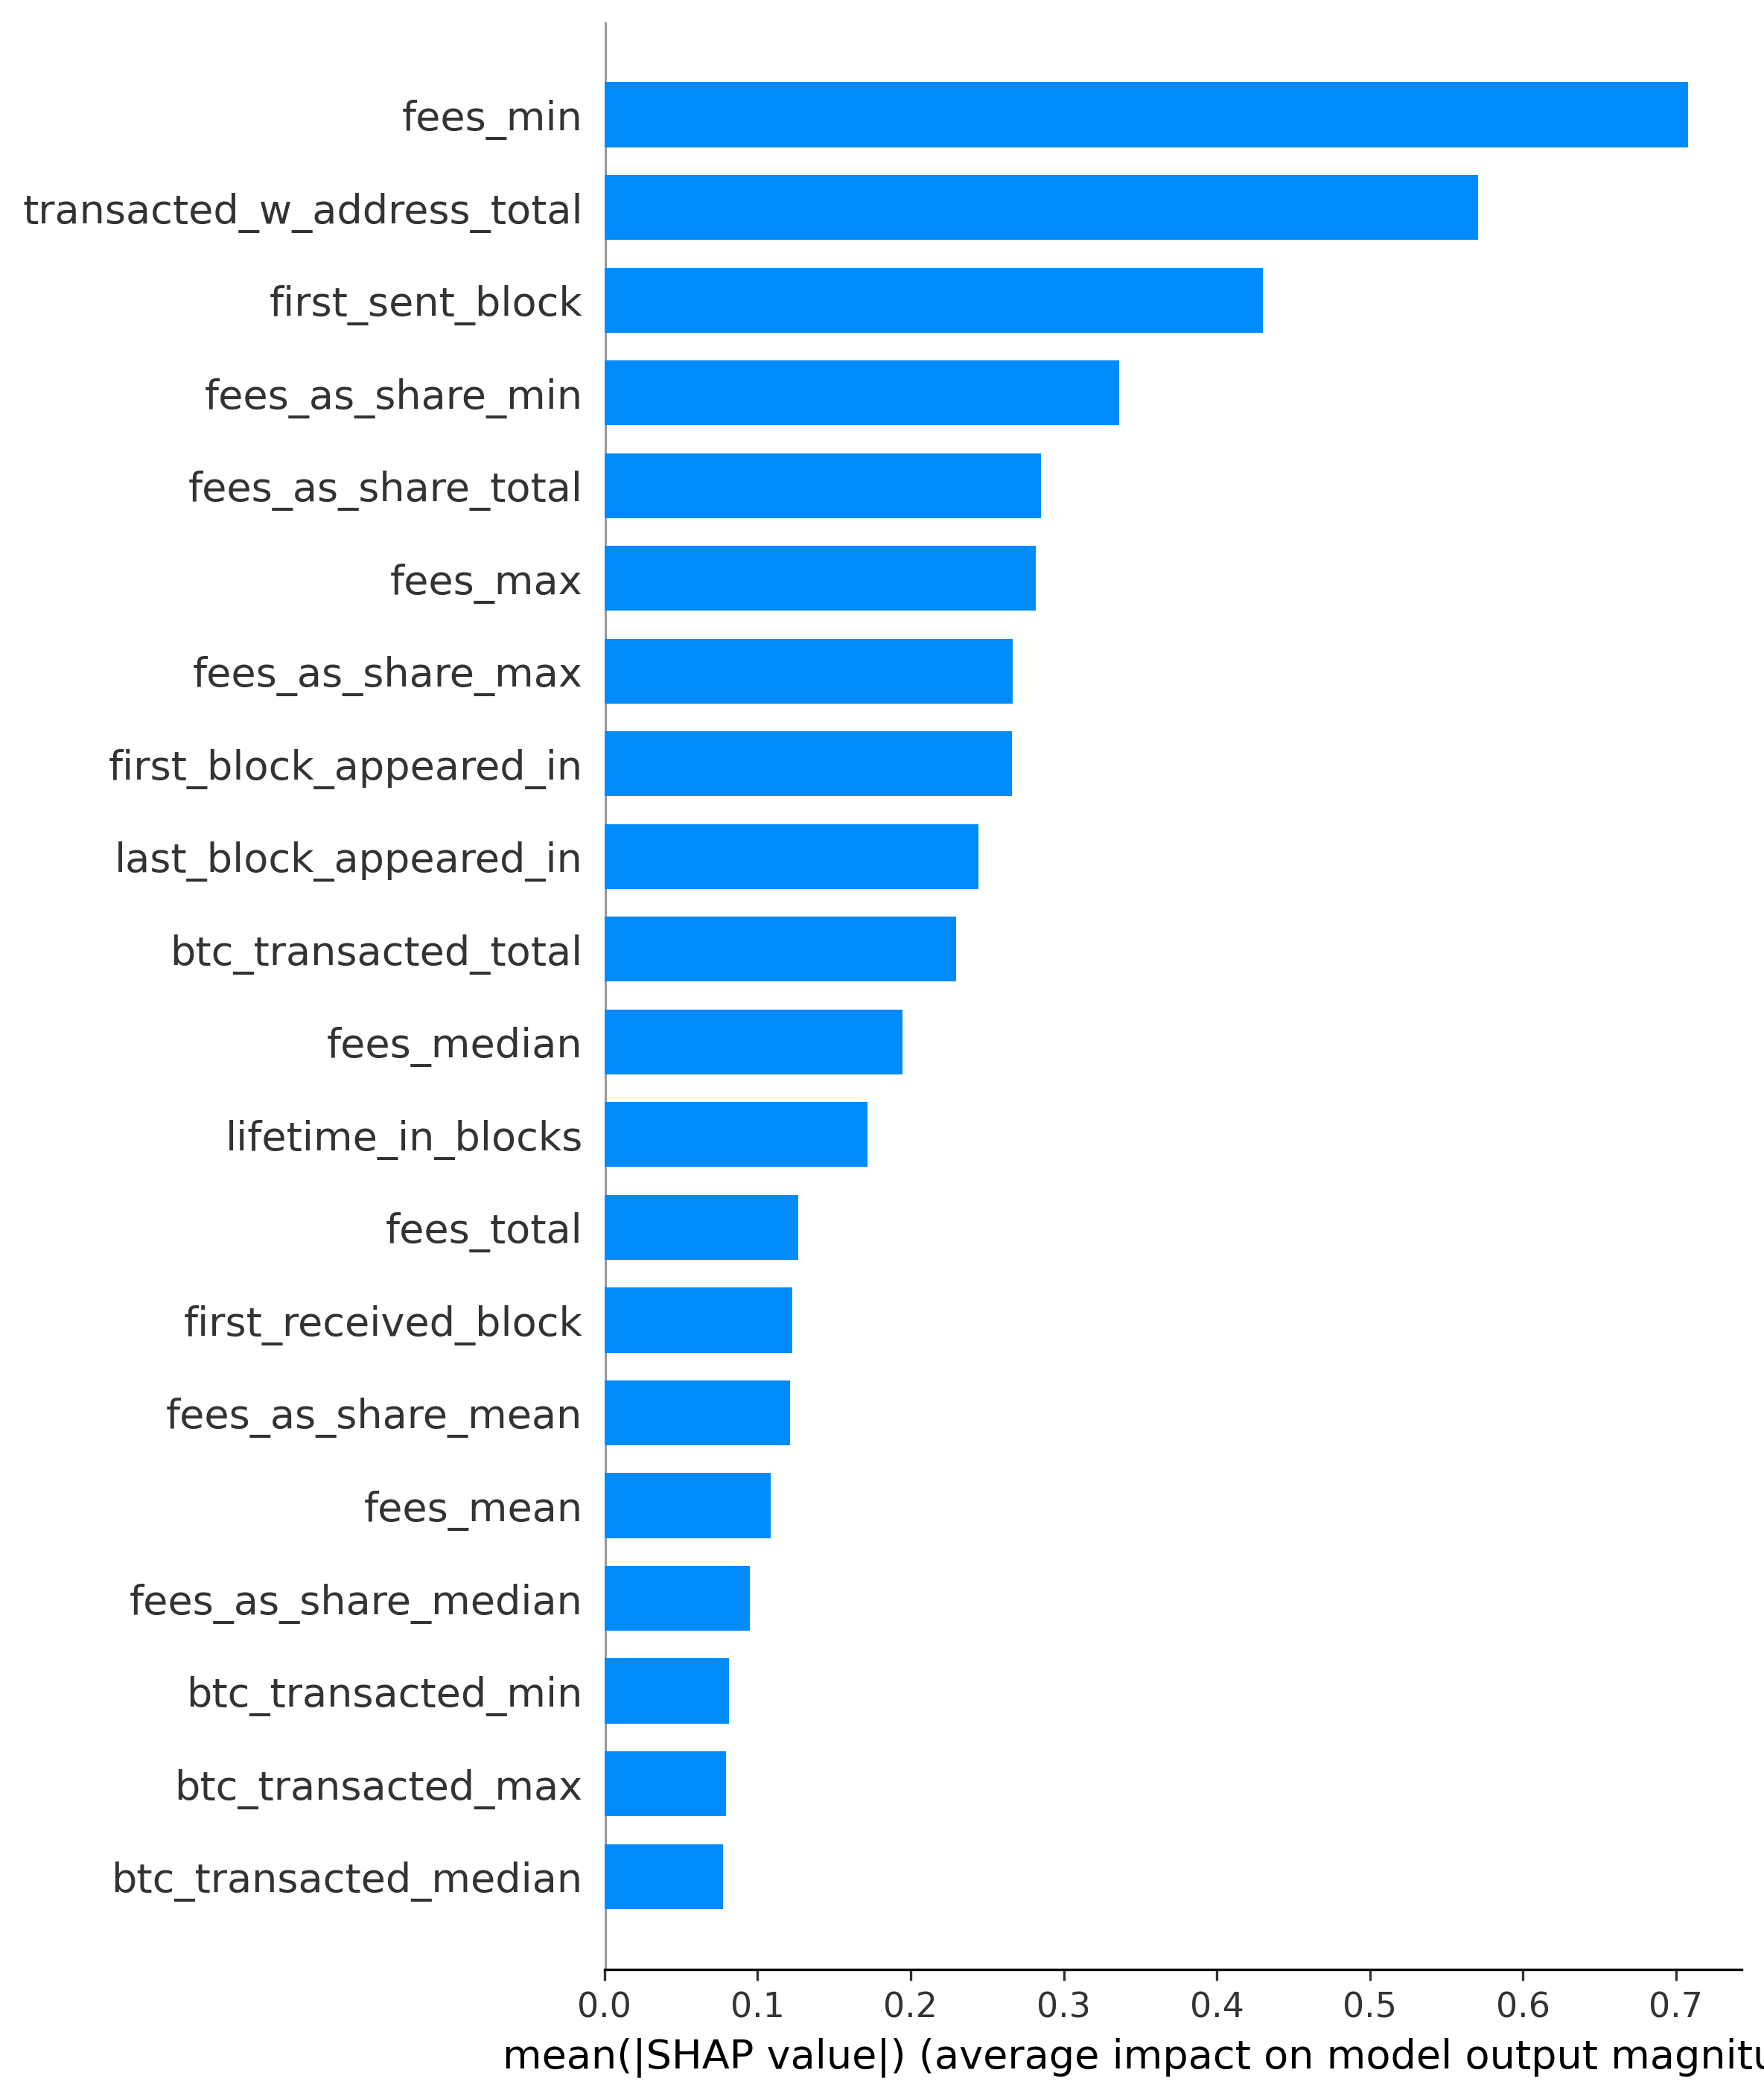

In [17]:
print("\n=== SHAP SUMMARY BAR PLOT ===")

display(
    Image(
        filename=str(wallets_results_lgbm_dir / "shap_summary_bar.png")
    )
)

In [20]:
wallets_lgbm_importance_df = pd.read_csv(project_root / "models"/ "rq3_xai_models"/ "feature_models"/ "lightgbm_shap_elliptic-wallets-combined"/ "shap_feature_importance.csv")

def classify_wallet_feature(feature):

    # -------------------------
    # Fee-related
    # -------------------------
    if "fees" in feature:
        return "Fee-related"

    # -------------------------
    # Temporal
    # -------------------------
    elif (
        "block" in feature
        or "lifetime" in feature
    ):
        return "Temporal"

    # -------------------------
    # Transaction / Behavioural
    # -------------------------
    elif (
        "transacted" in feature
        or "btc_" in feature
    ):
        return "Behavioural"

    else:
        return "Other"


wallets_lgbm_importance_df["feature_group"] = (
    wallets_lgbm_importance_df["feature"]
    .apply(classify_wallet_feature)
)

wallets_lgbm_group_importance = (
    wallets_lgbm_importance_df
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .reset_index()
)

# Relative contribution
wallets_lgbm_group_importance["relative_importance"] = (
    wallets_lgbm_group_importance["mean_abs_shap"] /
    wallets_lgbm_group_importance["mean_abs_shap"].sum()
)

wallets_lgbm_group_importance

,feature_group,mean_abs_shap,relative_importance
0,Behavioural,1.521177,0.278759
1,Fee-related,2.524263,0.462576
2,Other,0.074707,0.013690
3,Temporal,1.336821,0.244975


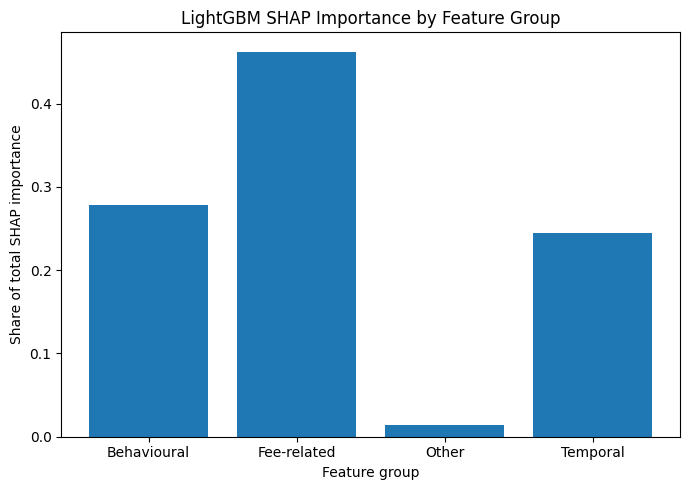

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    wallets_lgbm_group_importance["feature_group"],
    wallets_lgbm_group_importance["relative_importance"]
)

plt.ylabel("Share of total SHAP importance")
plt.xlabel("Feature group")

plt.title(
    "LightGBM SHAP Importance by Feature Group"
)

plt.tight_layout()

plt.show()

In [33]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Get model and SHAP importance from your SHAP result
model = wallets_result_lgbm["model"]
shap_importance = wallets_result_lgbm["importance"].copy()

# Internal LightGBM feature importance
internal_importance = pd.DataFrame({
    "feature": wallets_result_lgbm["X_explain"].columns,
    "lightgbm_internal_importance": model.feature_importances_
})

# Merge SHAP + internal LightGBM importance
comparison = shap_importance.merge(
    internal_importance,
    on="feature",
    how="inner"
)

# Add rankings
comparison["shap_rank"] = comparison["mean_abs_shap"].rank(
    ascending=False,
    method="min"
)

comparison["internal_rank"] = comparison["lightgbm_internal_importance"].rank(
    ascending=False,
    method="min"
)

comparison["rank_difference"] = (
    comparison["shap_rank"] - comparison["internal_rank"]
).abs()

comparison = comparison.sort_values("mean_abs_shap", ascending=False)

comparison.head(20)

,feature,mean_abs_shap,lightgbm_internal_importance,shap_rank,internal_rank,rank_difference
0,fees_min,0.707626,1083,1.0,1.0,0.0
1,transacted_w_address_total,0.570721,524,2.0,5.0,3.0
2,first_sent_block,0.430343,395,3.0,7.0,4.0
3,fees_as_share_min,0.336414,331,4.0,9.0,5.0
4,fees_as_share_total,0.285216,207,5.0,14.0,9.0
5,fees_max,0.281851,831,6.0,4.0,2.0
6,fees_as_share_max,0.266614,361,7.0,8.0,1.0
7,first_block_appeared_in,0.266022,998,8.0,2.0,6.0
8,last_block_appeared_in,0.244514,853,9.0,3.0,6.0
9,btc_transacted_total,0.229708,240,10.0,13.0,3.0


##### **Spearman correlation of Shap Feature Importance and Internal Model**
---

In [36]:
corr, p_value = spearmanr(
    comparison["mean_abs_shap"],
    comparison["lightgbm_internal_importance"]
)

print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.10e}")

Spearman correlation: 0.9506
P-value: 1.3685426707e-28


##### **Normalized comparison plot**
---

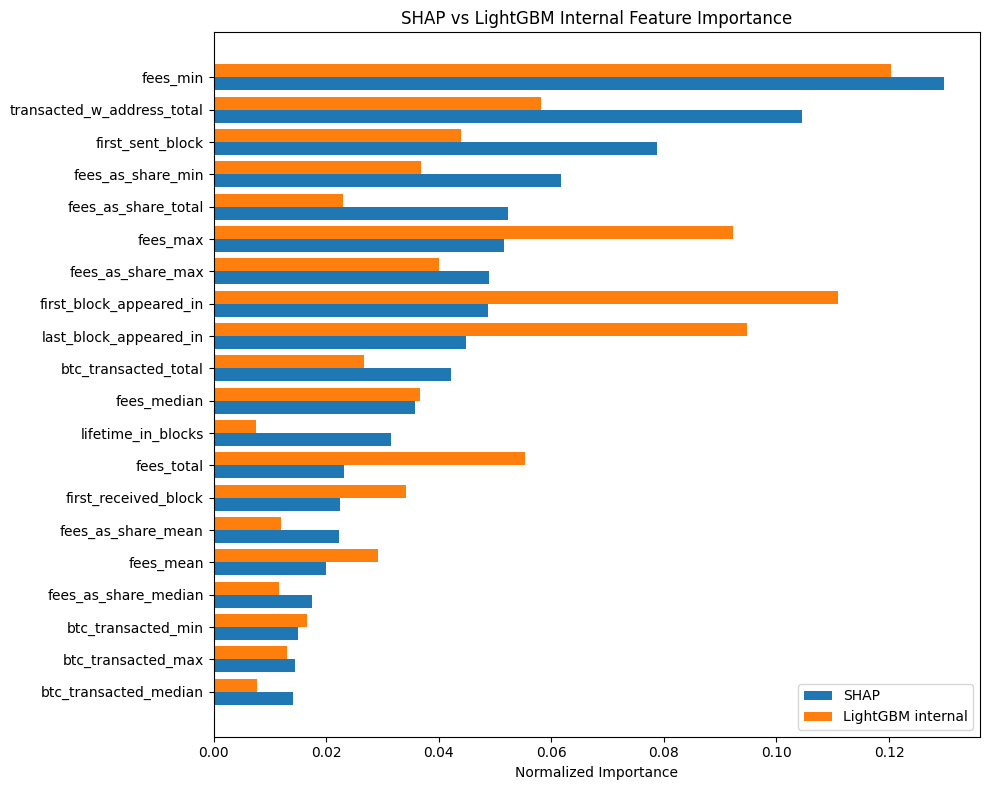

In [49]:
plot_df = comparison.copy()

# Normalize to percentage
plot_df["shap_norm"] = (
    plot_df["mean_abs_shap"] /
    plot_df["mean_abs_shap"].sum()
)

plot_df["lgbm_norm"] = (
    plot_df["lightgbm_internal_importance"] /
    plot_df["lightgbm_internal_importance"].sum()
)

top_n = 20
top = plot_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))

bar_width = 0.4
y_pos = range(len(top))

plt.barh(
    [y - bar_width/2 for y in y_pos],
    top["shap_norm"],
    height=bar_width,
    label="SHAP"
)

plt.barh(
    [y + bar_width/2 for y in y_pos],
    top["lgbm_norm"],
    height=bar_width,
    label="LightGBM internal"
)

plt.yticks(y_pos, top["feature"])

plt.xlabel("Normalized Importance")
plt.title("SHAP vs LightGBM Internal Feature Importance")
plt.legend()

plt.tight_layout()

save_dir = wallets_result_lgbm["save_dir"]

plt.savefig(
    save_dir / "lightgbm_shap_vs_internal_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

##### **SHAP vs LightGBM internal importance**
---

On the wallets dataset, SHAP and LightGBM's internal feature importance showed a very strong agreement, with a **Spearman correlation of 0.95** (p < 0.001). This was the strongest agreement observed across all datasets. The top feature, ***fees_min***, was ranked first by both methods, and most fee-related features also appeared near the top in both rankings.

Some small differences were still present. For example, ***lifetime_in_blocks*** was ranked much higher by SHAP than by the internal importance scores. This happens because LightGBM's internal importance measures how often a feature is used for decision splits, while SHAP measures how strongly the feature contributes to the final predictions. Even if a feature is used less frequently, it can still have an important effect when it is used.

Overall, the high correlation confirms that the SHAP explanations are consistent with how LightGBM internally uses its features on the wallets dataset.

---
---


=== SHAP BEESWARM PLOT ===


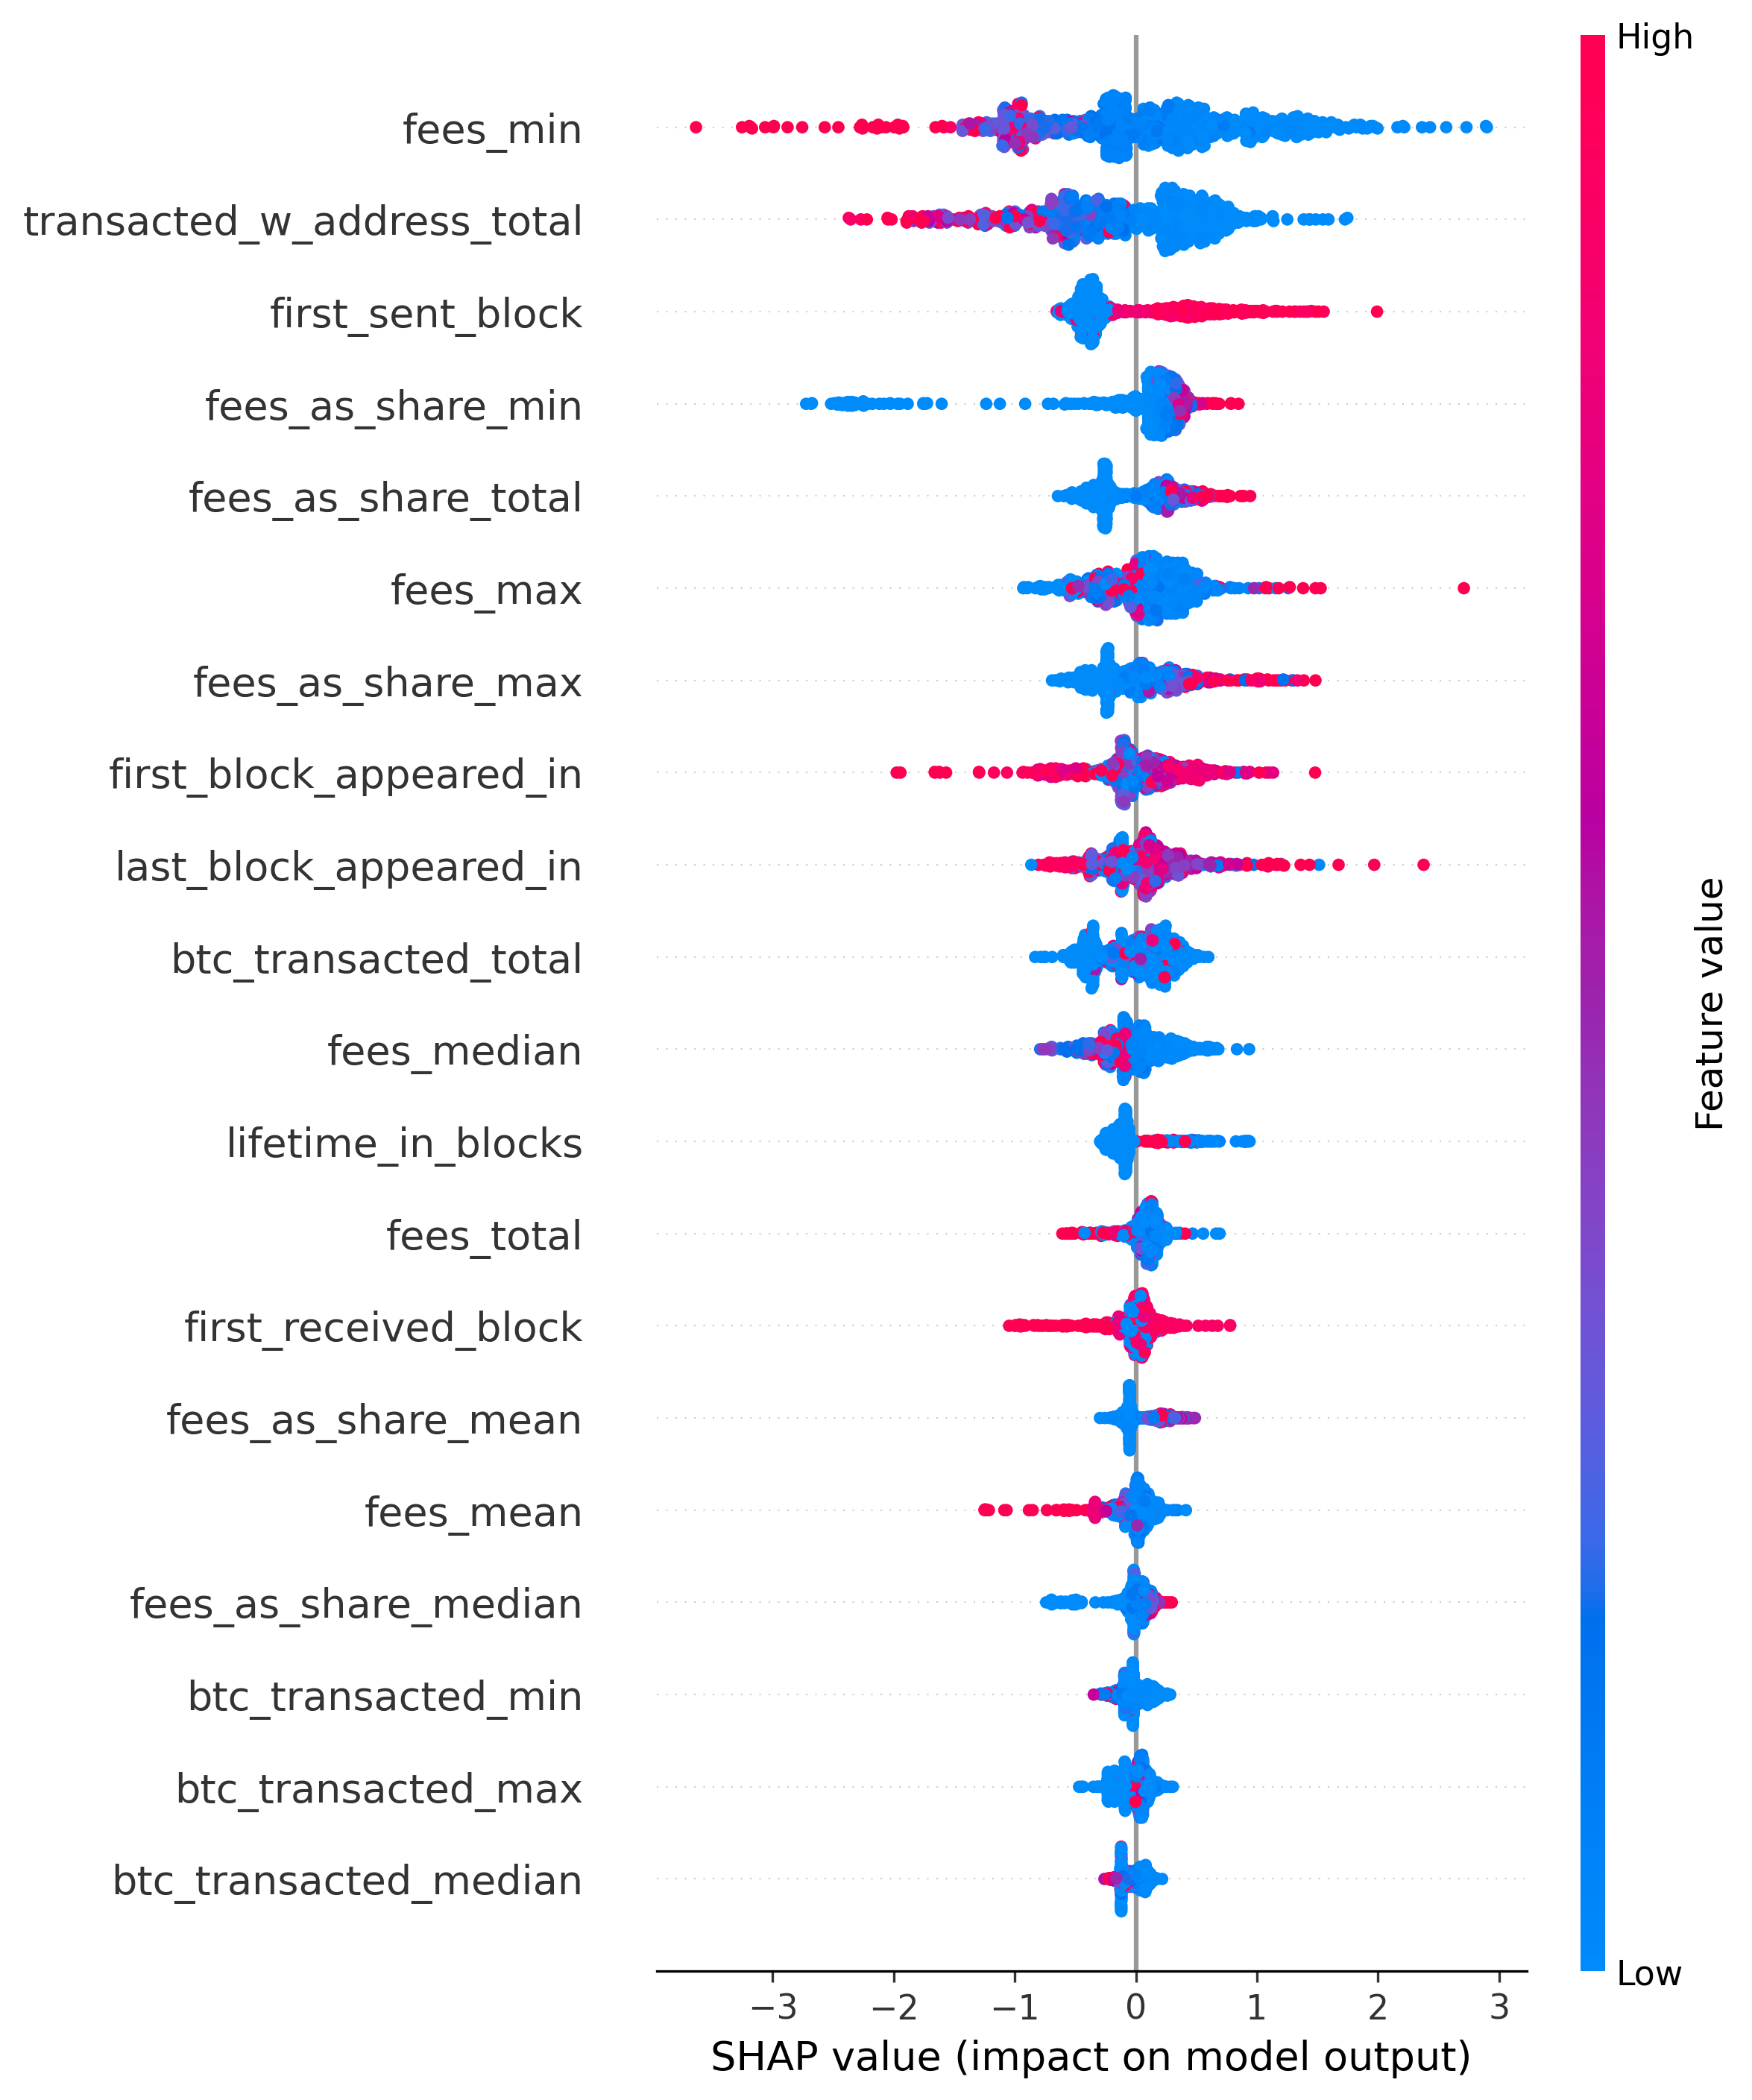

In [18]:
print("\n=== SHAP BEESWARM PLOT ===")

display(
    Image(
        filename=str(wallets_results_lgbm_dir / "shap_beeswarm.png")
    )
)

##### **Elliptic++ wallets-combined - LightGBM (balanced)**
---

LightGBM achieved an **F1-score of 0.545** and a **ROC-AUC of 0.985** on the Elliptic++ wallets dataset. The high ROC-AUC shows that the model can rank wallets by fraud risk very well, but the lower F1-score shows that correctly separating fraudulent and legitimate wallets is much more difficult than in the Ethereum dataset. The model detects most illicit wallets, but also produces many false positives because of the strong class imbalance in the dataset.

The SHAP analysis shows that the model mainly relies on **fee-related, behavioural, and temporal features**, with fee-related features contributing the largest share of total SHAP importance. The most important features were:
- ***fees_min***
- ***transacted_w_address_total***
- ***first_sent_block***
- ***fees_as_share_min***
- ***fees_as_share_total***
- ***fees_max***

This suggests that the way wallets pay transaction fees is an important fraud signal. The beeswarm plot shows that wallets with very low transaction fees or low fee shares are more likely to be classified as illicit. This may indicate that fraudulent wallets try to minimise transaction costs while moving funds through laundering chains.

Behavioural transaction features and temporal wallet-lifecycle features were also important. Wallets that appeared later in the blockchain history or remained active for shorter periods were more likely to be classified as fraudulent. This is similar to the Ethereum results, where short-lived wallets were also associated with illicit activity.

Compared to Ethereum, the importance scores were spread more evenly across many features. This suggests that the fraud patterns in the Elliptic++ dataset are more difficult to detect, forcing the model to combine information from multiple weaker signals instead of relying on a few highly discriminative features.

Overall, the SHAP analysis shows that LightGBM identifies fraudulent Bitcoin wallets mainly through fee behaviour and wallet activity patterns, rather than only transaction volume.

#### **Random Forest**

In [38]:
from src.xai import run_shap_random_forest

wallets_result_rf = run_shap_random_forest(
    dataset="elliptic-wallets-combined"
)

=== Random Forest Balanced Metrics ===
                     dataset                   model  accuracy  precision  \
0  elliptic-wallets-combined  Random Forest balanced  0.989411   0.858527   

     recall        f1   roc_auc  
0  0.705976  0.774814  0.981216  

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     47382
           1       0.86      0.71      0.77      1255

    accuracy                           0.99     48637
   macro avg       0.93      0.85      0.88     48637
weighted avg       0.99      0.99      0.99     48637


SHAP Random Forest results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\random_forest_shap_elliptic-wallets-combined


In [4]:
from IPython.display import Image, display

# Path to SHAP results
wallets_results_rf_dir = Path(
    "../models/rq3_xai_models/feature_models/random_forest_shap_elliptic-wallets-combined"
)

In [5]:
metrics = pd.read_csv(wallets_results_rf_dir / "metrics.csv")

print("=== Metrics ===")
display(metrics)

=== Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest balanced,0.989411,0.858527,0.705976,0.774814,0.981216


In [6]:
feature_importance = pd.read_csv(
    wallets_results_rf_dir / "shap_feature_importance.csv"
)

print("\n=== TOP SHAP FEATURES ===")
display(feature_importance.head(20))


=== TOP SHAP FEATURES ===


,feature,mean_abs_shap
0,transacted_w_address_total,0.036446
1,first_sent_block,0.031635
2,fees_min,0.028715
3,fees_max,0.027599
4,fees_as_share_max,0.024574
5,last_block_appeared_in,0.021113
6,first_block_appeared_in,0.020174
7,fees_median,0.018558
8,fees_as_share_total,0.018486
9,fees_mean,0.017928



=== SHAP SUMMARY BAR PLOT ===


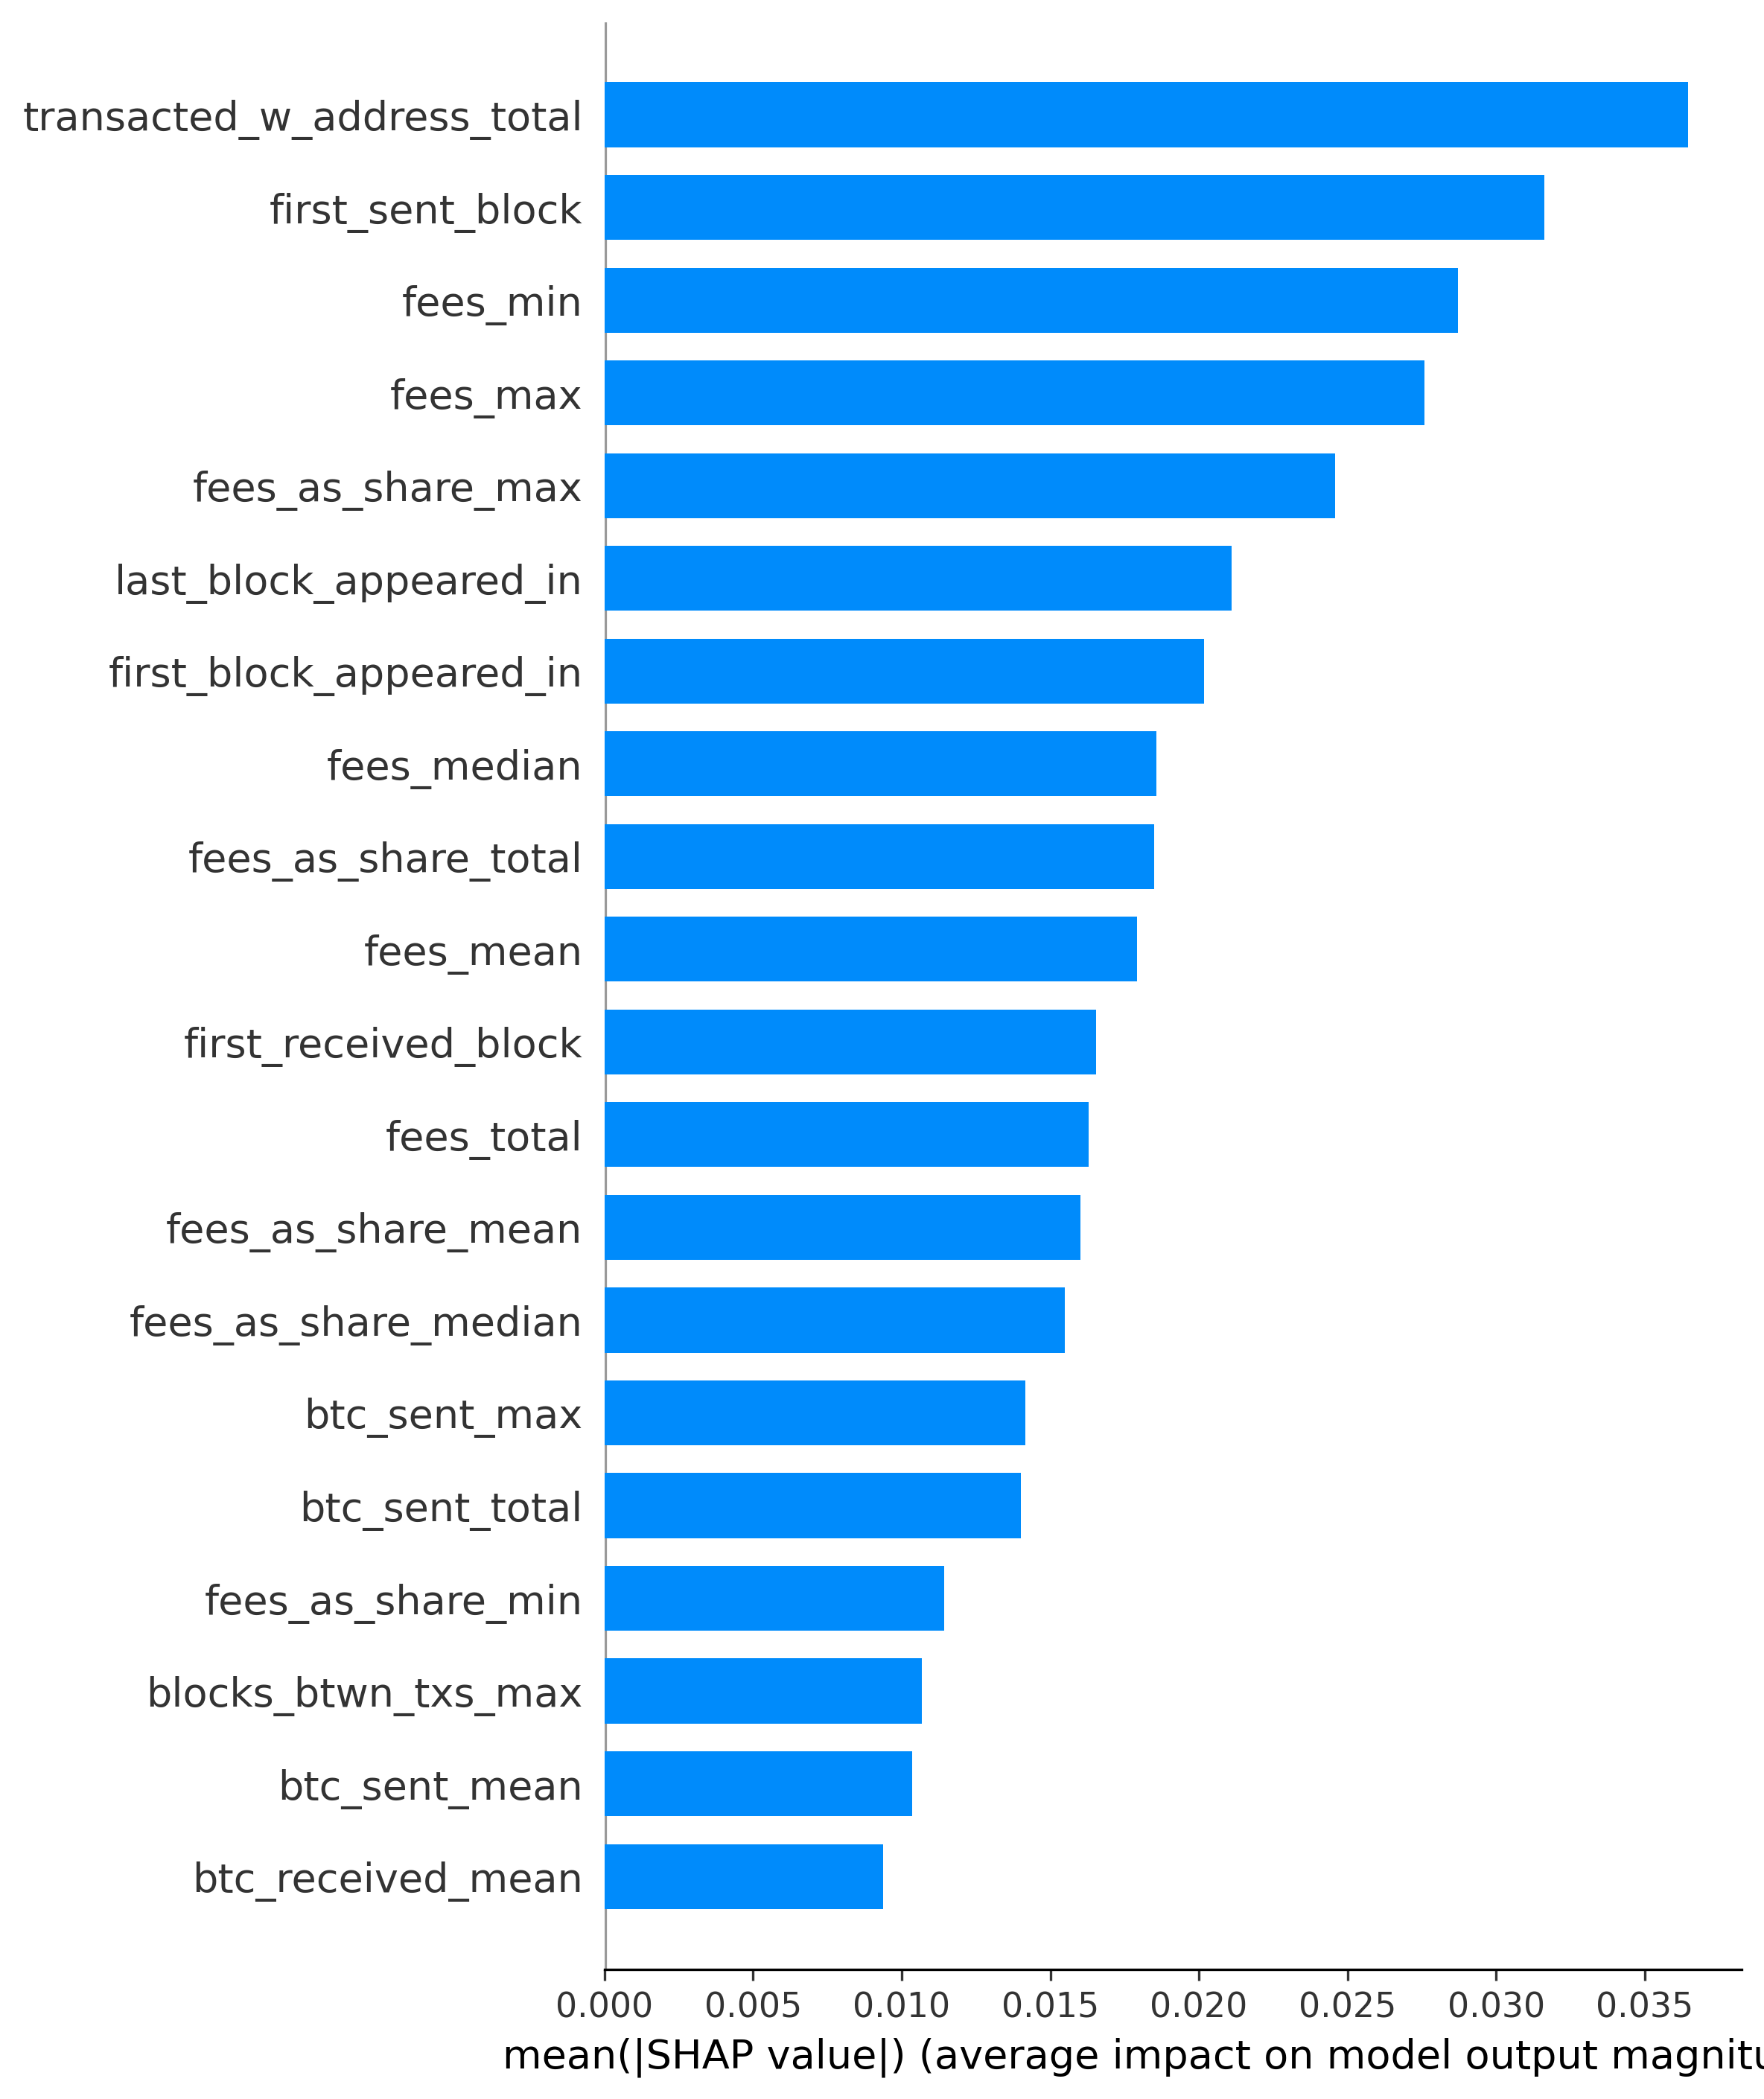

In [7]:
print("\n=== SHAP SUMMARY BAR PLOT ===")

display(
    Image(
        filename=str(wallets_results_rf_dir / "shap_summary_bar.png")
    )
)

In [22]:
wallets_rf_importance_df = pd.read_csv(project_root / "models"/ "rq3_xai_models"/ "feature_models"/ "random_forest_shap_elliptic-wallets-combined"/ "shap_feature_importance.csv")

def classify_wallet_feature(feature):

    # -------------------------
    # Fee-related
    # -------------------------
    if "fees" in feature:
        return "Fee-related"

    # -------------------------
    # Temporal
    # -------------------------
    elif (
        "block" in feature
        or "lifetime" in feature
    ):
        return "Temporal"

    # -------------------------
    # Transaction / Behavioural
    # -------------------------
    elif (
        "transacted" in feature
        or "btc_" in feature
    ):
        return "Behavioural"

    else:
        return "Other"


wallets_rf_importance_df["feature_group"] = (
    wallets_rf_importance_df["feature"]
    .apply(classify_wallet_feature)
)

wallets_rf_group_importance = (
    wallets_rf_importance_df
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .reset_index()
)

# Relative contribution
wallets_rf_group_importance["relative_importance"] = (
    wallets_rf_group_importance["mean_abs_shap"] /
    wallets_rf_group_importance["mean_abs_shap"].sum()
)

wallets_rf_group_importance

,feature_group,mean_abs_shap,relative_importance
0,Behavioural,0.169420,0.328286
1,Fee-related,0.195096,0.378038
2,Other,0.015293,0.029634
3,Temporal,0.136265,0.264041


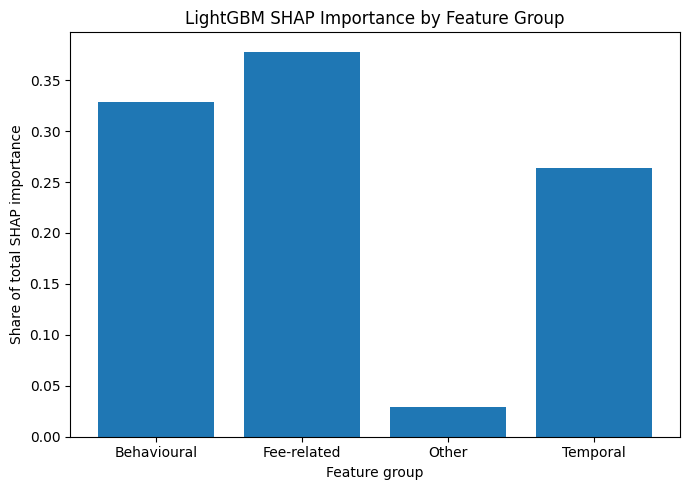

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    wallets_rf_group_importance["feature_group"],
    wallets_rf_group_importance["relative_importance"]
)

plt.ylabel("Share of total SHAP importance")
plt.xlabel("Feature group")

plt.title(
    "LightGBM SHAP Importance by Feature Group"
)

plt.tight_layout()

plt.show()

In [39]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Get model + SHAP importance
model = wallets_result_rf["model"]
shap_importance = wallets_result_rf["importance"].copy()

# Random Forest internal importance
internal_importance = pd.DataFrame({
    "feature": wallets_result_rf["X_explain"].columns,
    "rf_internal_importance": model.feature_importances_
})

# Merge
comparison_rf = shap_importance.merge(
    internal_importance,
    on="feature",
    how="inner"
)

# Rankings
comparison_rf["shap_rank"] = comparison_rf["mean_abs_shap"].rank(
    ascending=False,
    method="min"
)

comparison_rf["rf_rank"] = comparison_rf["rf_internal_importance"].rank(
    ascending=False,
    method="min"
)

comparison_rf["rank_difference"] = (
    comparison_rf["shap_rank"] - comparison_rf["rf_rank"]
).abs()

# Sort
comparison_rf = comparison_rf.sort_values(
    "mean_abs_shap",
    ascending=False
)

comparison_rf.head(20)

,feature,mean_abs_shap,rf_internal_importance,shap_rank,rf_rank,rank_difference
0,transacted_w_address_total,0.036446,0.038938,1.0,7.0,6.0
1,first_sent_block,0.031635,0.068737,2.0,1.0,1.0
2,fees_min,0.028715,0.051080,3.0,2.0,1.0
3,fees_max,0.027599,0.042585,4.0,4.0,0.0
4,fees_as_share_max,0.024574,0.030404,5.0,12.0,7.0
5,last_block_appeared_in,0.021113,0.039049,6.0,6.0,0.0
6,first_block_appeared_in,0.020174,0.038591,7.0,8.0,1.0
7,fees_median,0.018558,0.043197,8.0,3.0,5.0
8,fees_as_share_total,0.018486,0.025447,9.0,18.0,9.0
9,fees_mean,0.017928,0.041184,10.0,5.0,5.0


##### **Spearman correlation of Shap Feature Importance and Internal Model**
---

In [41]:
corr, p_value = spearmanr(
    comparison_rf["mean_abs_shap"],
    comparison_rf["rf_internal_importance"]
)

print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.10e}")

Spearman correlation: 0.9608
P-value: 3.3078074950e-31


##### **Normalized comparison plot**
---

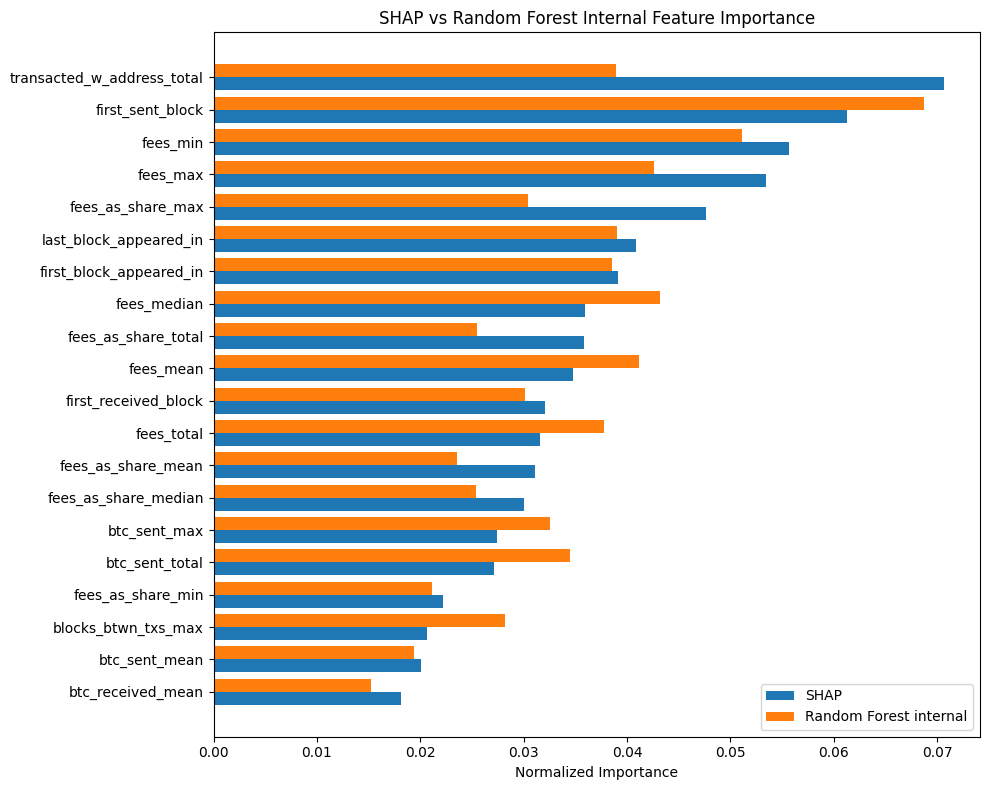

In [56]:
plot_df = comparison_rf.copy()

# Normalize
plot_df["shap_norm"] = (
    plot_df["mean_abs_shap"] /
    plot_df["mean_abs_shap"].sum()
)

plot_df["rf_norm"] = (
    plot_df["rf_internal_importance"] /
    plot_df["rf_internal_importance"].sum()
)

top_n = 20
top = plot_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))

bar_width = 0.4
y_pos = range(len(top))

# SHAP bars
plt.barh(
    [y - bar_width/2 for y in y_pos],
    top["shap_norm"],
    height=bar_width,
    label="SHAP"
)

# RF internal bars
plt.barh(
    [y + bar_width/2 for y in y_pos],
    top["rf_norm"],
    height=bar_width,
    label="Random Forest internal"
)

plt.yticks(y_pos, top["feature"])

plt.xlabel("Normalized Importance")
plt.title("SHAP vs Random Forest Internal Feature Importance")
plt.legend()

plt.tight_layout()

save_dir = wallets_result_rf["save_dir"]

plt.savefig(
    save_dir / "rf_shap_vs_internal_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### **SHAP vs Random Forest internal importance**
---

For Random Forest on the wallets dataset, SHAP and the model's internal feature importance showed a very strong agreement, with a **Spearman correlation of 0.96** (p < 0.001). This was the highest agreement across all model and dataset combinations in the analysis. Fee-related and block-timing features appeared near the top in both rankings, and the overall ordering was very similar.

Only small differences were observed in the middle of the rankings. For example, ***fees_as_share_total*** was ranked higher by SHAP than by the internal importance scores. These differences are expected because several fee-related features had very similar importance values, making small changes in ranking less meaningful.

Overall, the high correlation confirms that the SHAP explanations are highly consistent with the internal behaviour of the Random Forest model on the wallets dataset.

---
---


=== SHAP BEESWARM PLOT ===


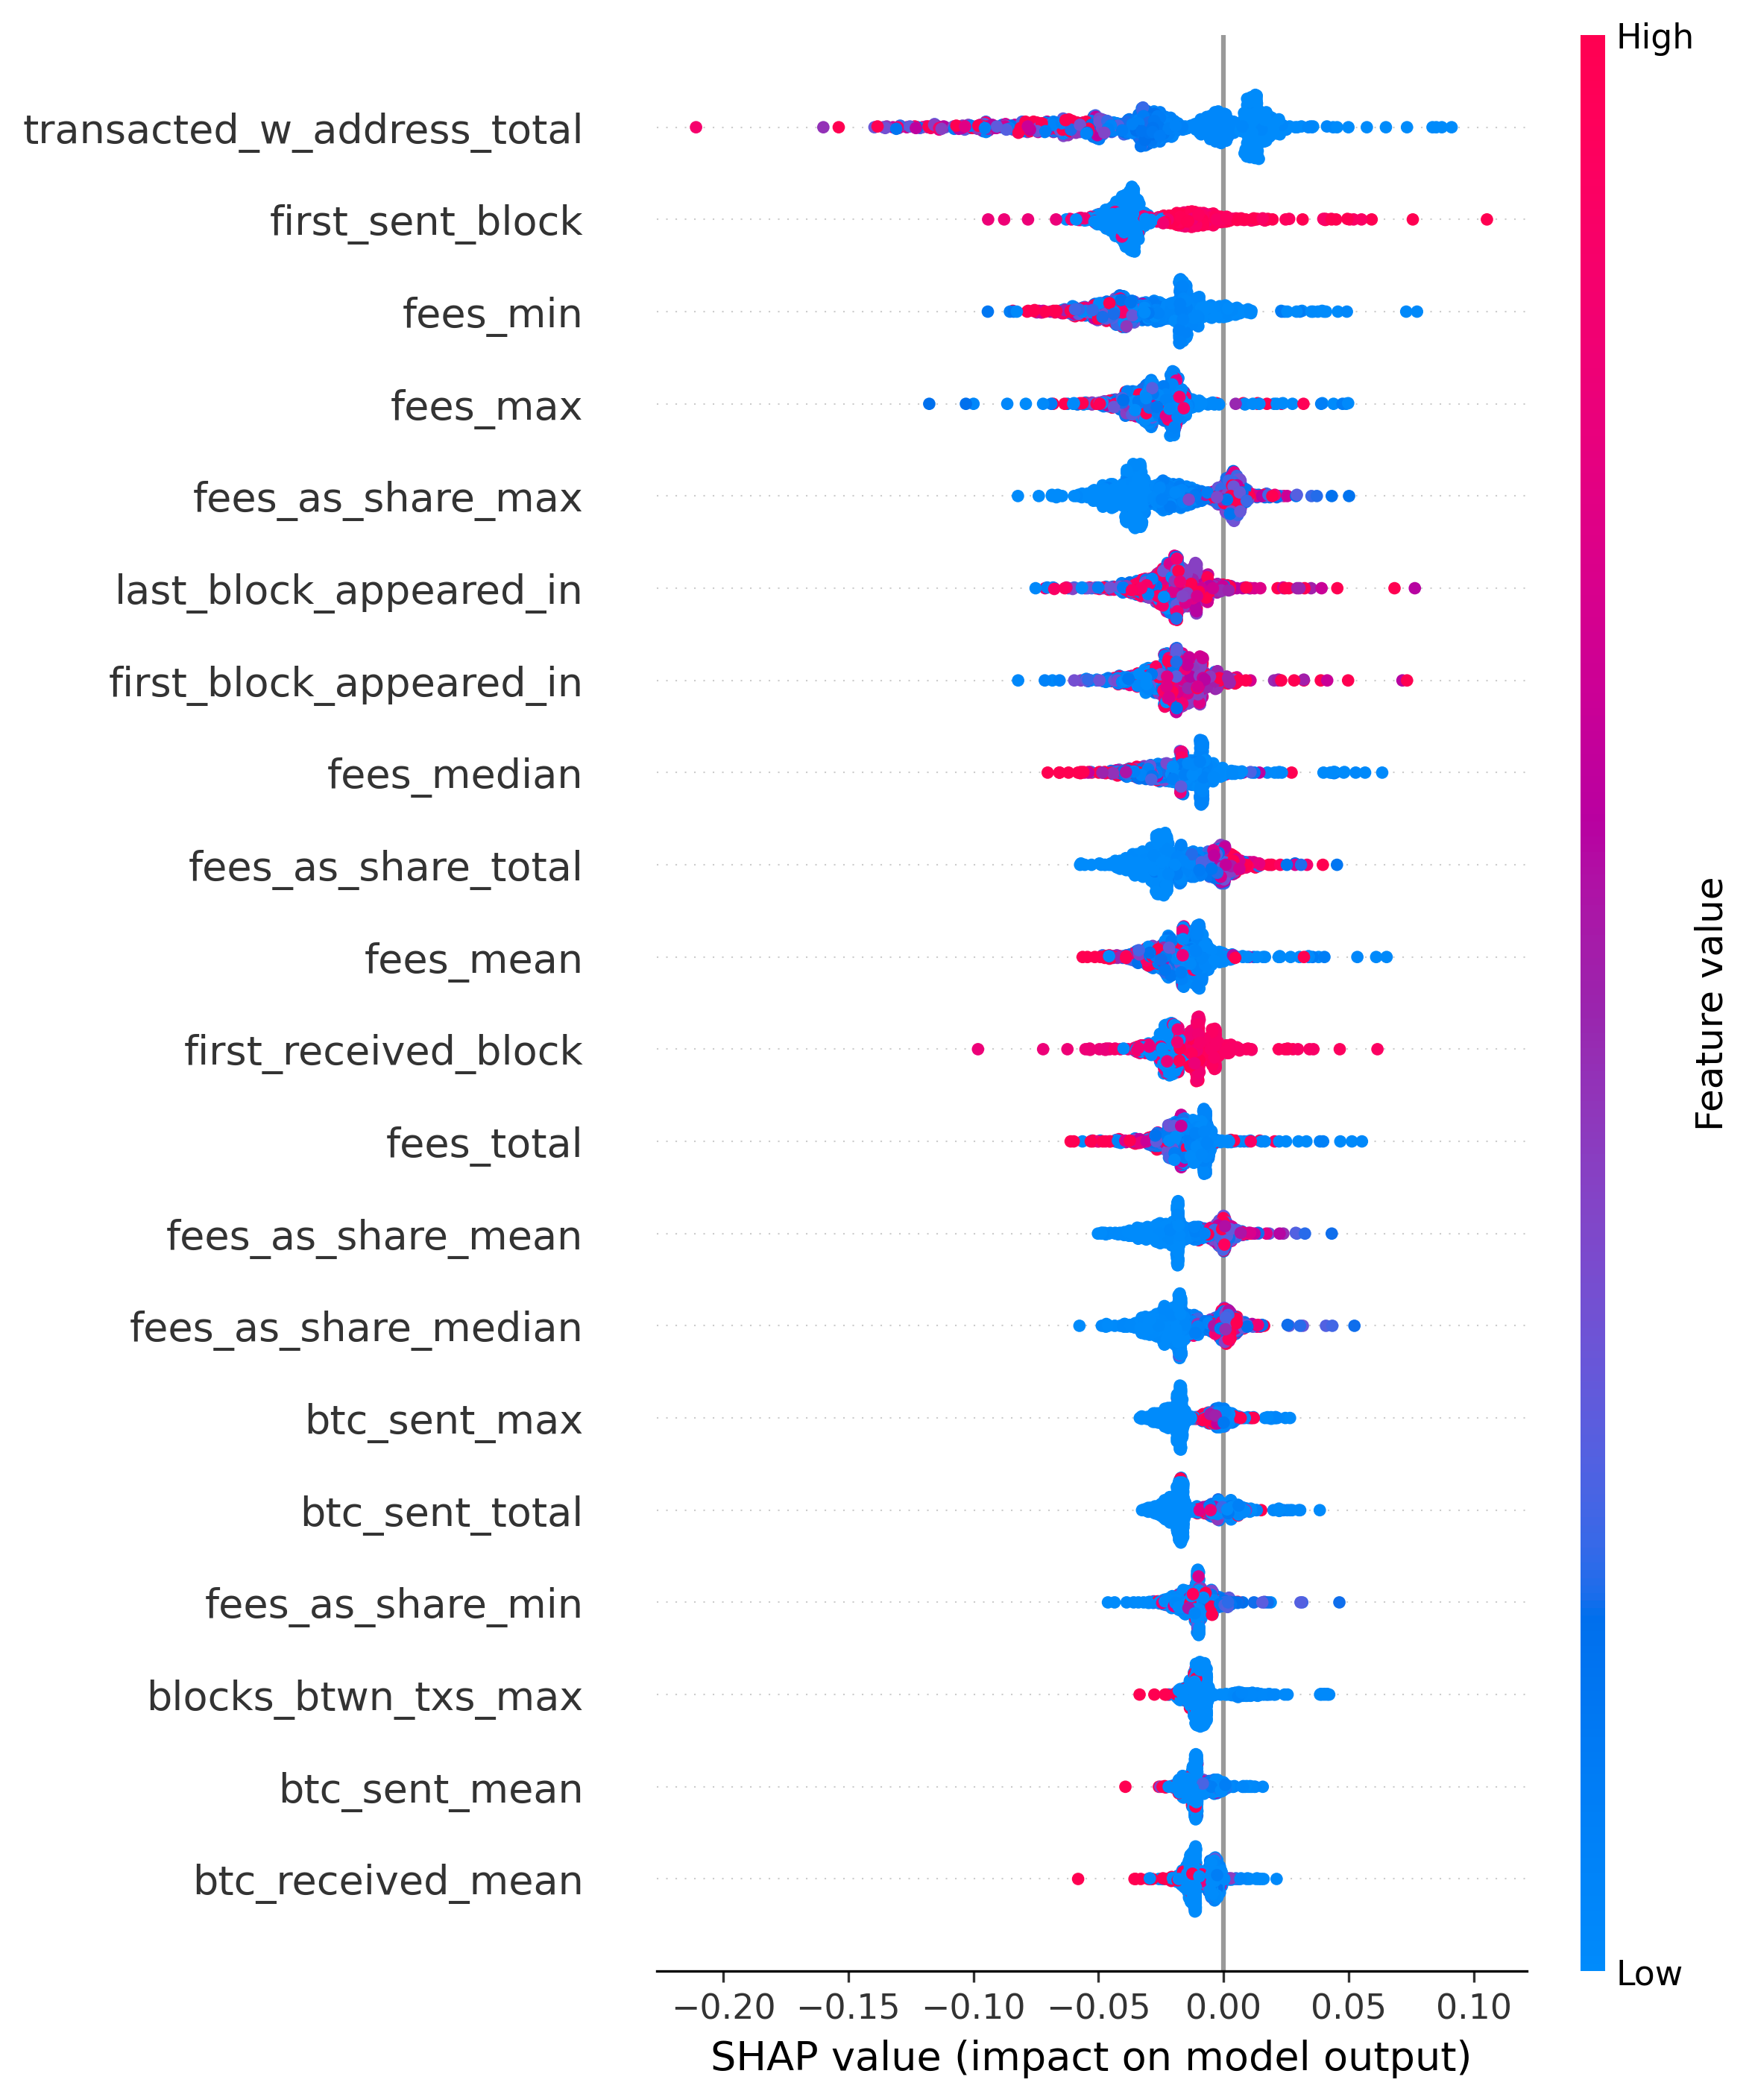

In [8]:
print("\n=== SHAP BEESWARM PLOT ===")

display(
    Image(
        filename=str(wallets_results_rf_dir / "shap_beeswarm.png")
    )
)

##### **Elliptic++ wallets-combined - Random Forest (balanced)**
---

Random Forest achieved an **F1-score of 0.775** and a **ROC-AUC of 0.981** on the Elliptic++ wallets dataset, outperforming LightGBM in terms of F1-score. Unlike LightGBM, which focused more on high recall, Random Forest achieved a better balance between precision and recall. This means the model produced fewer false positives and was more confident when identifying fraudulent wallets.

The SHAP analysis shows strong agreement with LightGBM on the most important fraud signals. The top features included:
- ***transacted_w_address_total***
- ***first_sent_block***
- ***fees_min***
- ***fees_max***
- ***fees_as_share_max***
- ***last_block_appeared_in***

Most of these features were also important in LightGBM, showing that both models rely on similar information. However, Random Forest placed relatively greater importance on behavioural transaction activity and temporal wallet-history features, while LightGBM focused more strongly on fee-related behaviour.

The beeswarm plot confirms several important patterns:
- wallets interacting with only a small number of addresses were more likely to be classified as illicit,
- wallets with recent first activity were more associated with fraud,
- low minimum transaction fees also pushed predictions towards the illicit class.

Compared to LightGBM, the feature importance in Random Forest was spread more evenly across many features. This suggests that Random Forest combines information from multiple smaller signals instead of relying heavily on a few dominant features.

Overall, both models identified similar fraud patterns in the Elliptic++ wallets dataset, especially related to transaction fees, wallet activity timing, and transaction behaviour. However, Random Forest produced more balanced and stable predictions, leading to better overall classification performance on this dataset.

#### **Elliptic-wallets-combined - XAI Discussion**
---

The Elliptic++ wallets dataset shows a more interesting comparison between LightGBM and Random Forest because the two models achieved different results using different strategies.

- **LightGBM** achieved an **F1-score of 0.545** with very high recall (0.89) but low precision (0.39). The model detected most fraudulent wallets but also produced many false positives. Its SHAP results showed that it relied heavily on a small number of important fee-related features.

- **Random Forest** achieved a higher **F1-score of 0.775** with lower recall (0.71) but much higher precision (0.86). The model was more conservative and produced fewer false positives. Its SHAP importance was spread more evenly across fee-related, behavioural, and temporal feature groups.

Both models identified similar fraud patterns. Fraudulent wallets were associated with:
- low transaction fees,
- recent wallet activity,
- fewer connected addresses,
- and shorter wallet lifetimes.

The main difference is how the models used these signals. LightGBM focused strongly on a few dominant fee-related features and produced more aggressive predictions, while Random Forest combined information from many behavioural and temporal signals and produced more balanced predictions.

Overall, the agreement between the two models suggests that the fee behaviour, wallet activity timing, and transaction behaviour are real characteristics of illicit Bitcoin wallets rather than model-specific behaviour.

---
---

### **Elliptic-transactions-combined**
---

#### **LightGBM**

In [62]:
from src.xai import run_shap_lightgbm

tr_result_lgbm = run_shap_lightgbm(dataset="elliptic-transactions-combined")

[LightGBM] [Info] Number of positive: 3909, number of negative: 31062
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018752 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42172
[LightGBM] [Info] Number of data points in the train set: 34971, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
=== LightGBM Balanced Metrics ===
                          dataset              model  accuracy  precision  \
0  elliptic-transactions-combined  LightGBM balanced   0.97616   0.930556   

     recall        f1  roc_auc  
0  0.632075  0.752809   0.9487  

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10438
           1       0.93      0.63      0.75       636

    accuracy                           0.98     11074
 

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



SHAP LightGBM results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\lightgbm_shap_elliptic-transactions-combined


In [9]:
from IPython.display import Image, display

# Path to SHAP results
tr_results_lgbm_dir = Path(
    "../models/rq3_xai_models/feature_models/lightgbm_shap_elliptic-transactions-combined"
)

In [11]:
metrics = pd.read_csv(tr_results_lgbm_dir / "metrics.csv")

print("=== Metrics ===")
display(metrics)

=== Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,LightGBM balanced,0.97616,0.930556,0.632075,0.752809,0.9487


In [10]:
feature_importance = pd.read_csv(
    tr_results_lgbm_dir / "shap_feature_importance.csv"
)

print("\n=== TOP SHAP FEATURES ===")
display(feature_importance.head(20))


=== TOP SHAP FEATURES ===


,feature,mean_abs_shap
0,Local_feature_61,0.942227
1,size,0.795595
2,Local_feature_59,0.733297
3,Local_feature_46,0.373357
4,Local_feature_53,0.372889
5,Local_feature_3,0.360919
6,Local_feature_5,0.320827
7,Local_feature_52,0.287996
8,Local_feature_58,0.255262
9,Aggregate_feature_68,0.199101



=== SHAP SUMMARY BAR PLOT ===


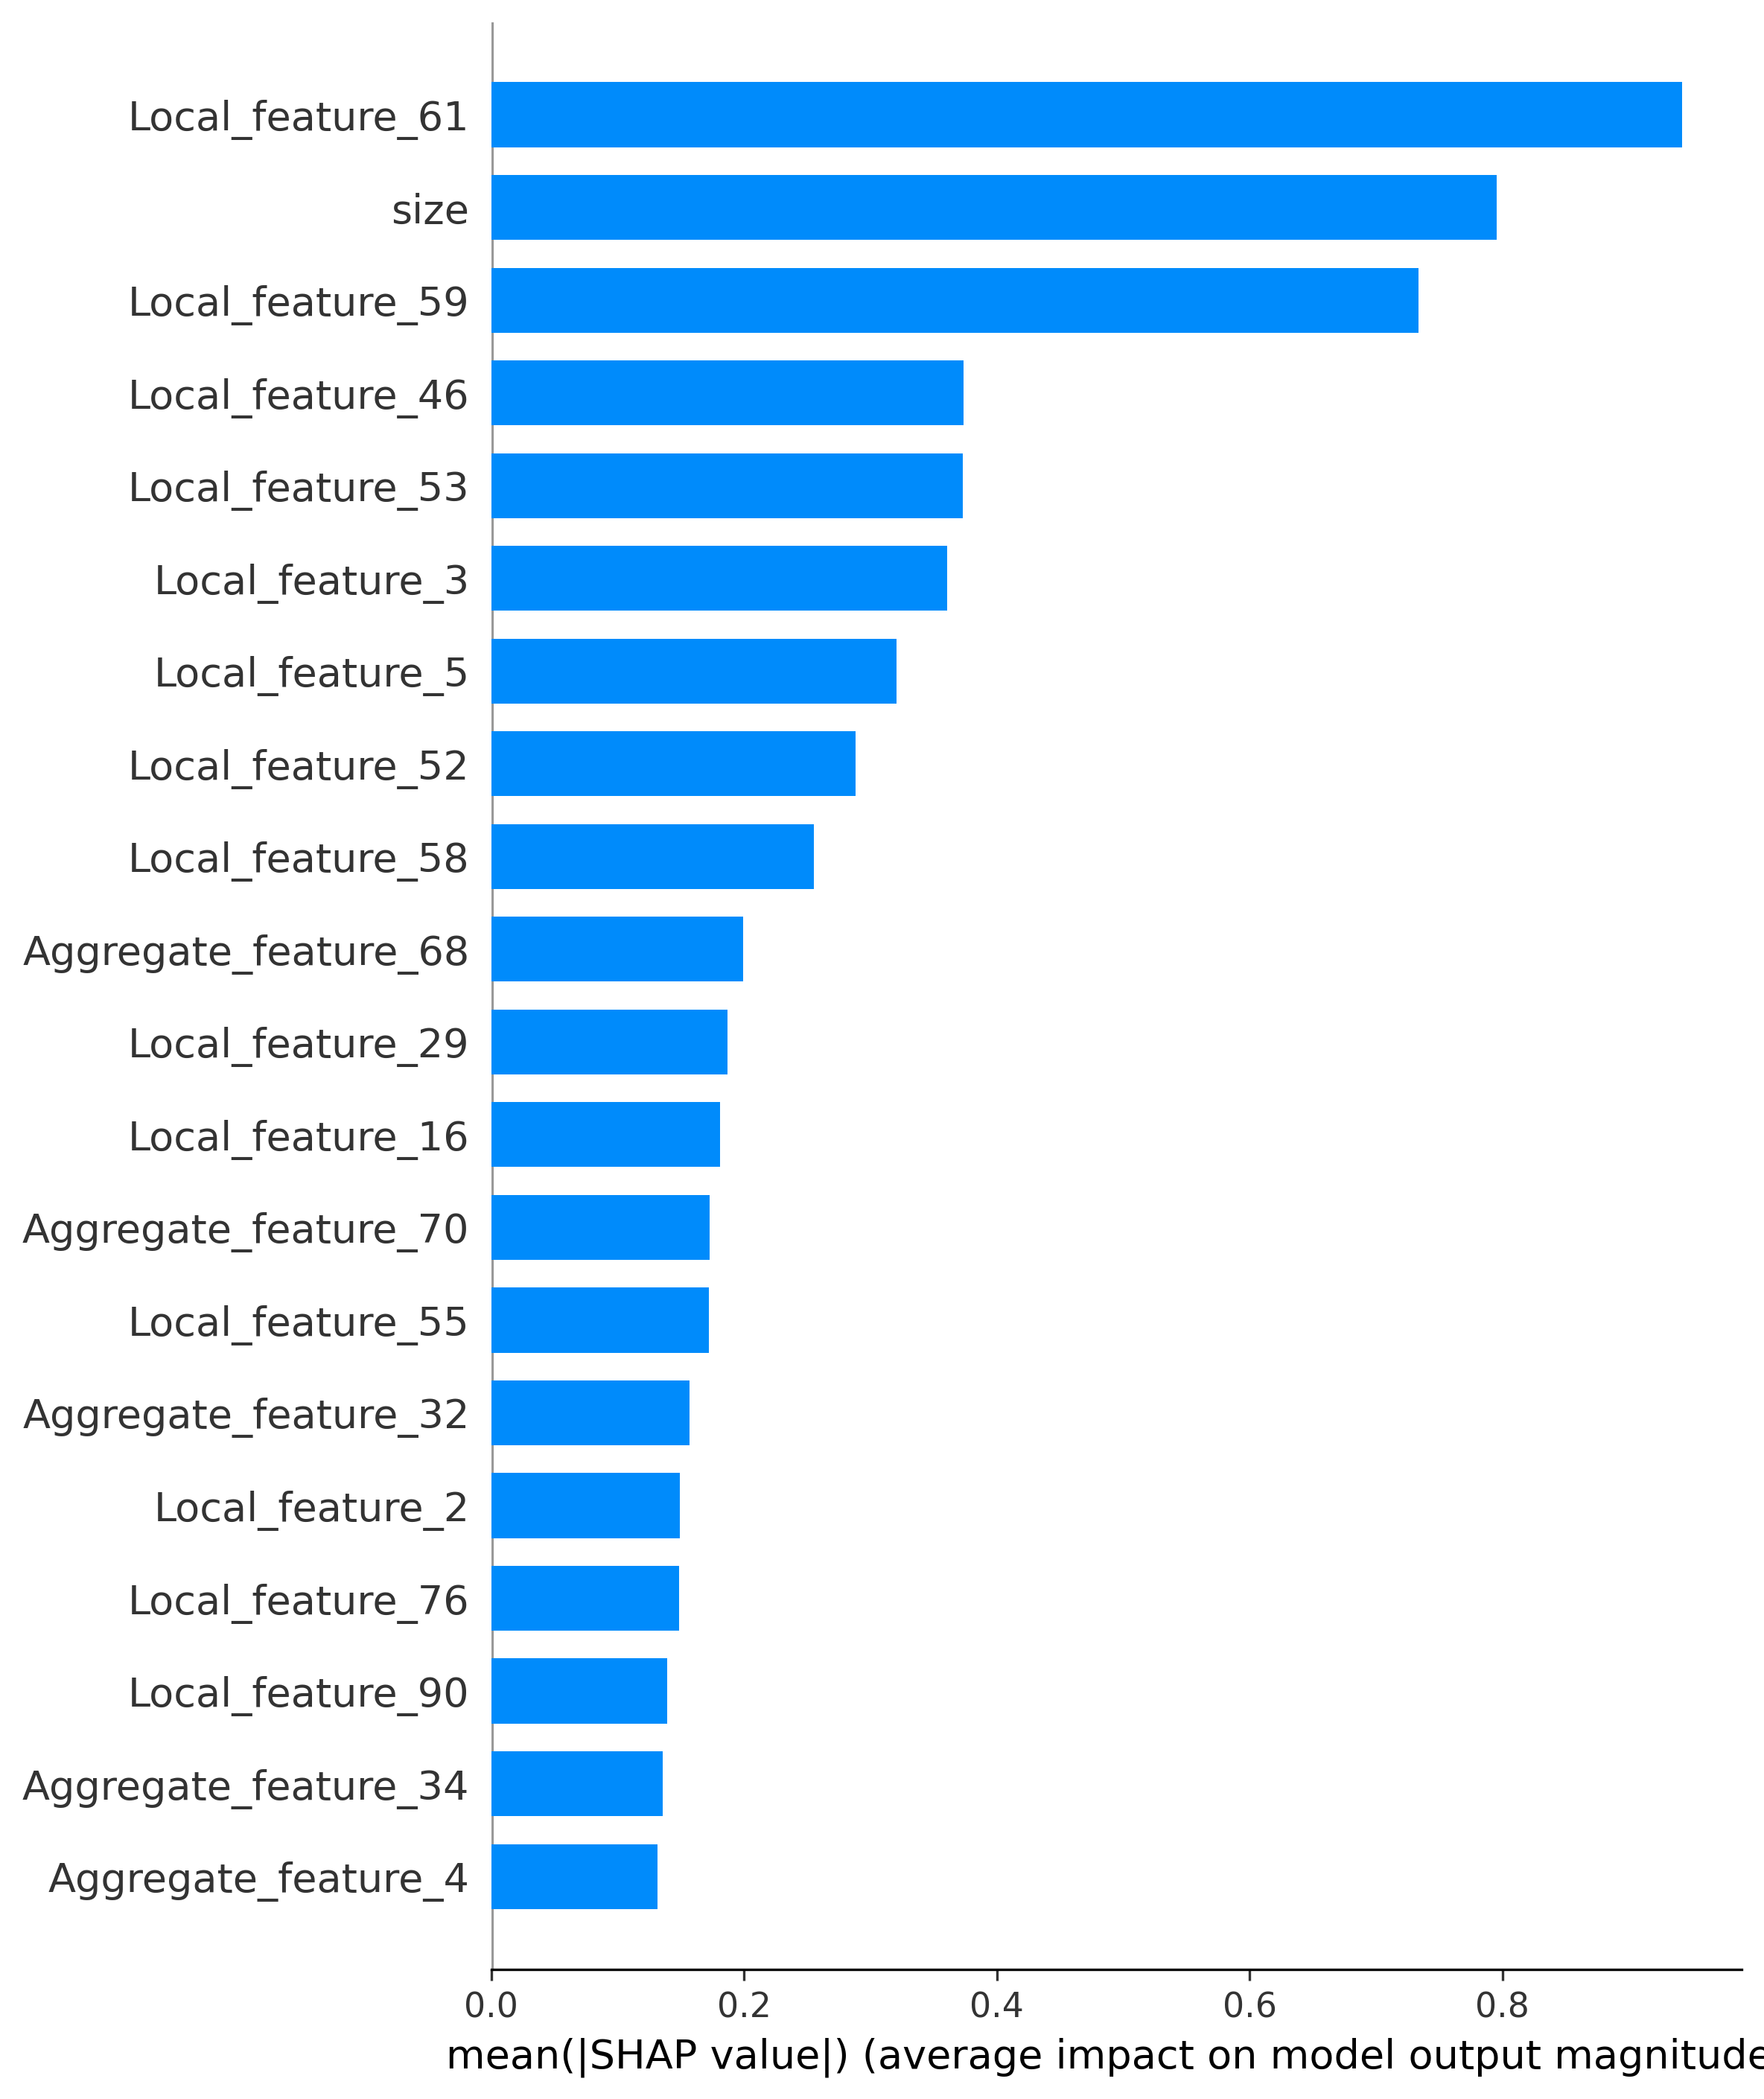

In [13]:
print("\n=== SHAP SUMMARY BAR PLOT ===")

display(
    Image(
        filename=str(tr_results_lgbm_dir / "shap_summary_bar.png")
    )
)

In [6]:
tr_lgbm_importance_df = pd.read_csv(project_root / "models"/ "rq3_xai_models"/ "feature_models"/ "lightgbm_shap_elliptic-transactions-combined"/ "shap_feature_importance.csv")

def classify_feature_group(feature):
    if feature.startswith("Local_feature"):
        return "Local"

    elif feature.startswith("Aggregate_feature"):
        return "Aggregate"

    else:
        return "Other"


tr_lgbm_importance_df["feature_group"] = (
    tr_lgbm_importance_df["feature"]
    .apply(classify_feature_group)
)

group_importance = (
    tr_lgbm_importance_df
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .reset_index()
)

# Relative contribution
group_importance["relative_importance"] = (
    group_importance["mean_abs_shap"] /
    group_importance["mean_abs_shap"].sum()
)

group_importance

,feature_group,mean_abs_shap,relative_importance
0,Aggregate,3.032289,0.277495
1,Local,6.734934,0.616336
2,Other,1.160145,0.106169


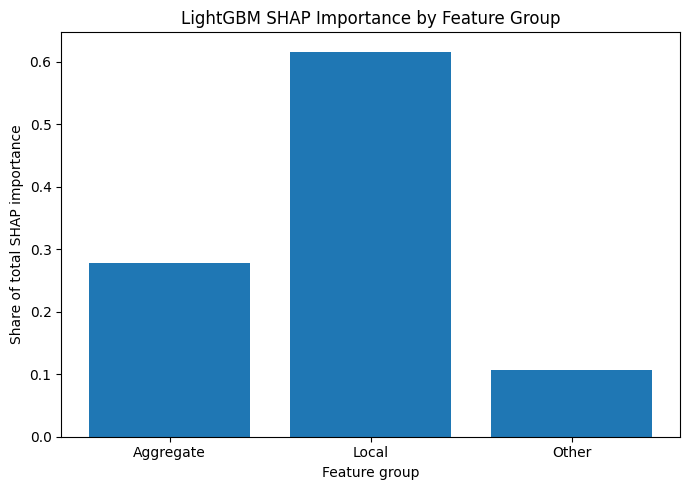

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    group_importance["feature_group"],
    group_importance["relative_importance"]
)

plt.ylabel("Share of total SHAP importance")
plt.xlabel("Feature group")

plt.title(
    "LightGBM SHAP Importance by Feature Group"
)

plt.tight_layout()

plt.show()

In [63]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Get model and SHAP importance from your SHAP result
model = tr_result_lgbm["model"]
shap_importance = tr_result_lgbm["importance"].copy()

# Internal LightGBM feature importance
internal_importance = pd.DataFrame({
    "feature": tr_result_lgbm["X_explain"].columns,
    "lightgbm_internal_importance": model.feature_importances_
})

# Merge SHAP + internal LightGBM importance
comparison = shap_importance.merge(
    internal_importance,
    on="feature",
    how="inner"
)

# Add rankings
comparison["shap_rank"] = comparison["mean_abs_shap"].rank(
    ascending=False,
    method="min"
)

comparison["internal_rank"] = comparison["lightgbm_internal_importance"].rank(
    ascending=False,
    method="min"
)

comparison["rank_difference"] = (
    comparison["shap_rank"] - comparison["internal_rank"]
).abs()

comparison = comparison.sort_values("mean_abs_shap", ascending=False)

comparison.head(20)

,feature,mean_abs_shap,lightgbm_internal_importance,shap_rank,internal_rank,rank_difference
0,Local_feature_61,0.942227,131,1.0,17.0,16.0
1,size,0.795595,187,2.0,5.0,3.0
2,Local_feature_59,0.733297,168,3.0,9.0,6.0
3,Local_feature_46,0.373357,164,4.0,12.0,8.0
4,Local_feature_53,0.372889,363,5.0,2.0,3.0
5,Local_feature_3,0.360919,171,6.0,7.0,1.0
6,Local_feature_5,0.320827,73,7.0,47.0,40.0
7,Local_feature_52,0.287996,246,8.0,3.0,5.0
8,Local_feature_58,0.255262,169,9.0,8.0,1.0
9,Aggregate_feature_68,0.199101,92,10.0,28.0,18.0


##### **Spearman correlation of Shap Feature Importance and Internal Model**
---

In [65]:
corr, p_value = spearmanr(
    comparison["mean_abs_shap"],
    comparison["lightgbm_internal_importance"]
)

print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.10e}")

Spearman correlation: 0.9098
P-value: 1.1461357844e-70


##### **Normalized comparison plot**
---

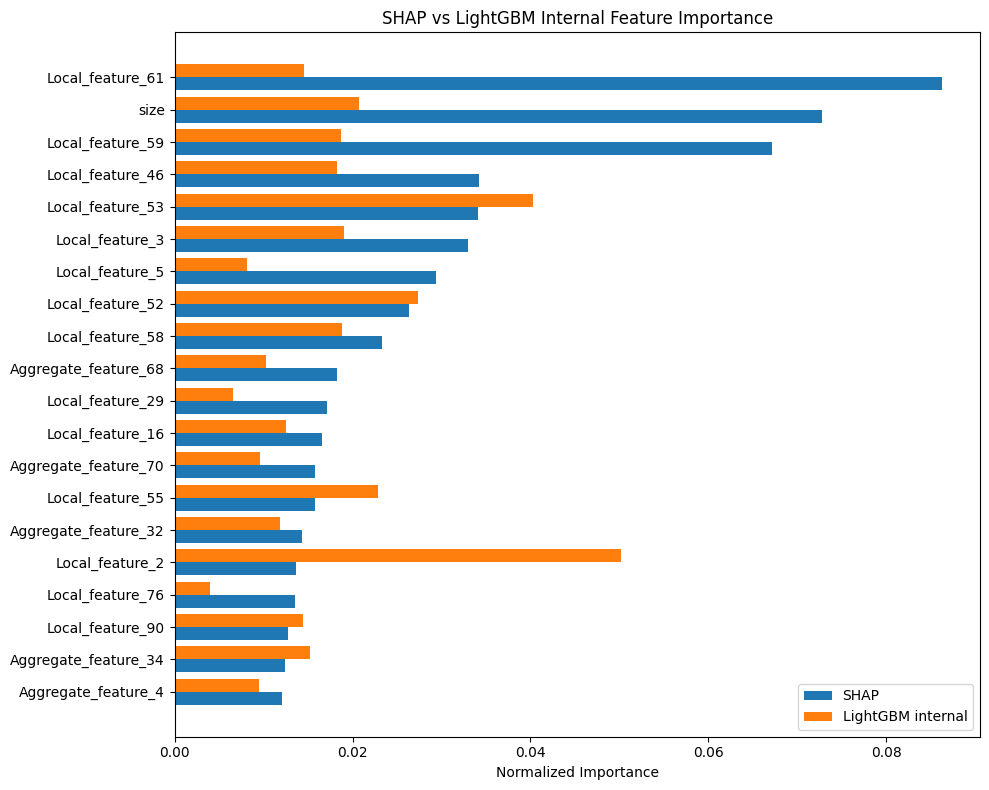

In [66]:
plot_df = comparison.copy()

# Normalize to percentage
plot_df["shap_norm"] = (
    plot_df["mean_abs_shap"] /
    plot_df["mean_abs_shap"].sum()
)

plot_df["lgbm_norm"] = (
    plot_df["lightgbm_internal_importance"] /
    plot_df["lightgbm_internal_importance"].sum()
)

top_n = 20
top = plot_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))

bar_width = 0.4
y_pos = range(len(top))

plt.barh(
    [y - bar_width/2 for y in y_pos],
    top["shap_norm"],
    height=bar_width,
    label="SHAP"
)

plt.barh(
    [y + bar_width/2 for y in y_pos],
    top["lgbm_norm"],
    height=bar_width,
    label="LightGBM internal"
)

plt.yticks(y_pos, top["feature"])

plt.xlabel("Normalized Importance")
plt.title("SHAP vs LightGBM Internal Feature Importance")
plt.legend()

plt.tight_layout()

save_dir = tr_result_lgbm["save_dir"]

plt.savefig(
    save_dir / "lightgbm_shap_vs_internal_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### **SHAP vs LightGBM internal importance**
---

On the transactions dataset, SHAP and LightGBM's internal feature importance showed a strong agreement, with a **Spearman correlation of 0.91** (p < 0.001). Both methods agreed that local transaction-level features were the most important signals for fraud detection. Features such as ***size***, ***Local_feature_53***, ***Local_feature_3***, ***Local_feature_58***, and ***Local_feature_90*** appeared near the top in both rankings.

Some larger differences between the rankings were also observed. For example, ***Local_feature_76*** and ***Local_feature_5*** were ranked much higher by SHAP than by the internal importance scores. This means that these features were used less often by LightGBM, but when they were used, they had a strong effect on the predictions. In contrast, ***Local_feature_2*** was ranked very highly by the internal importance scores but lower by SHAP, suggesting that it was used frequently in decision splits without strongly affecting the final predictions.

Overall, despite some differences in the middle of the rankings, the high correlation confirms that SHAP and LightGBM agree on the main conclusion: local transaction features contain most of the important fraud signal in the transactions dataset.

---
---


=== SHAP BEESWARM PLOT ===


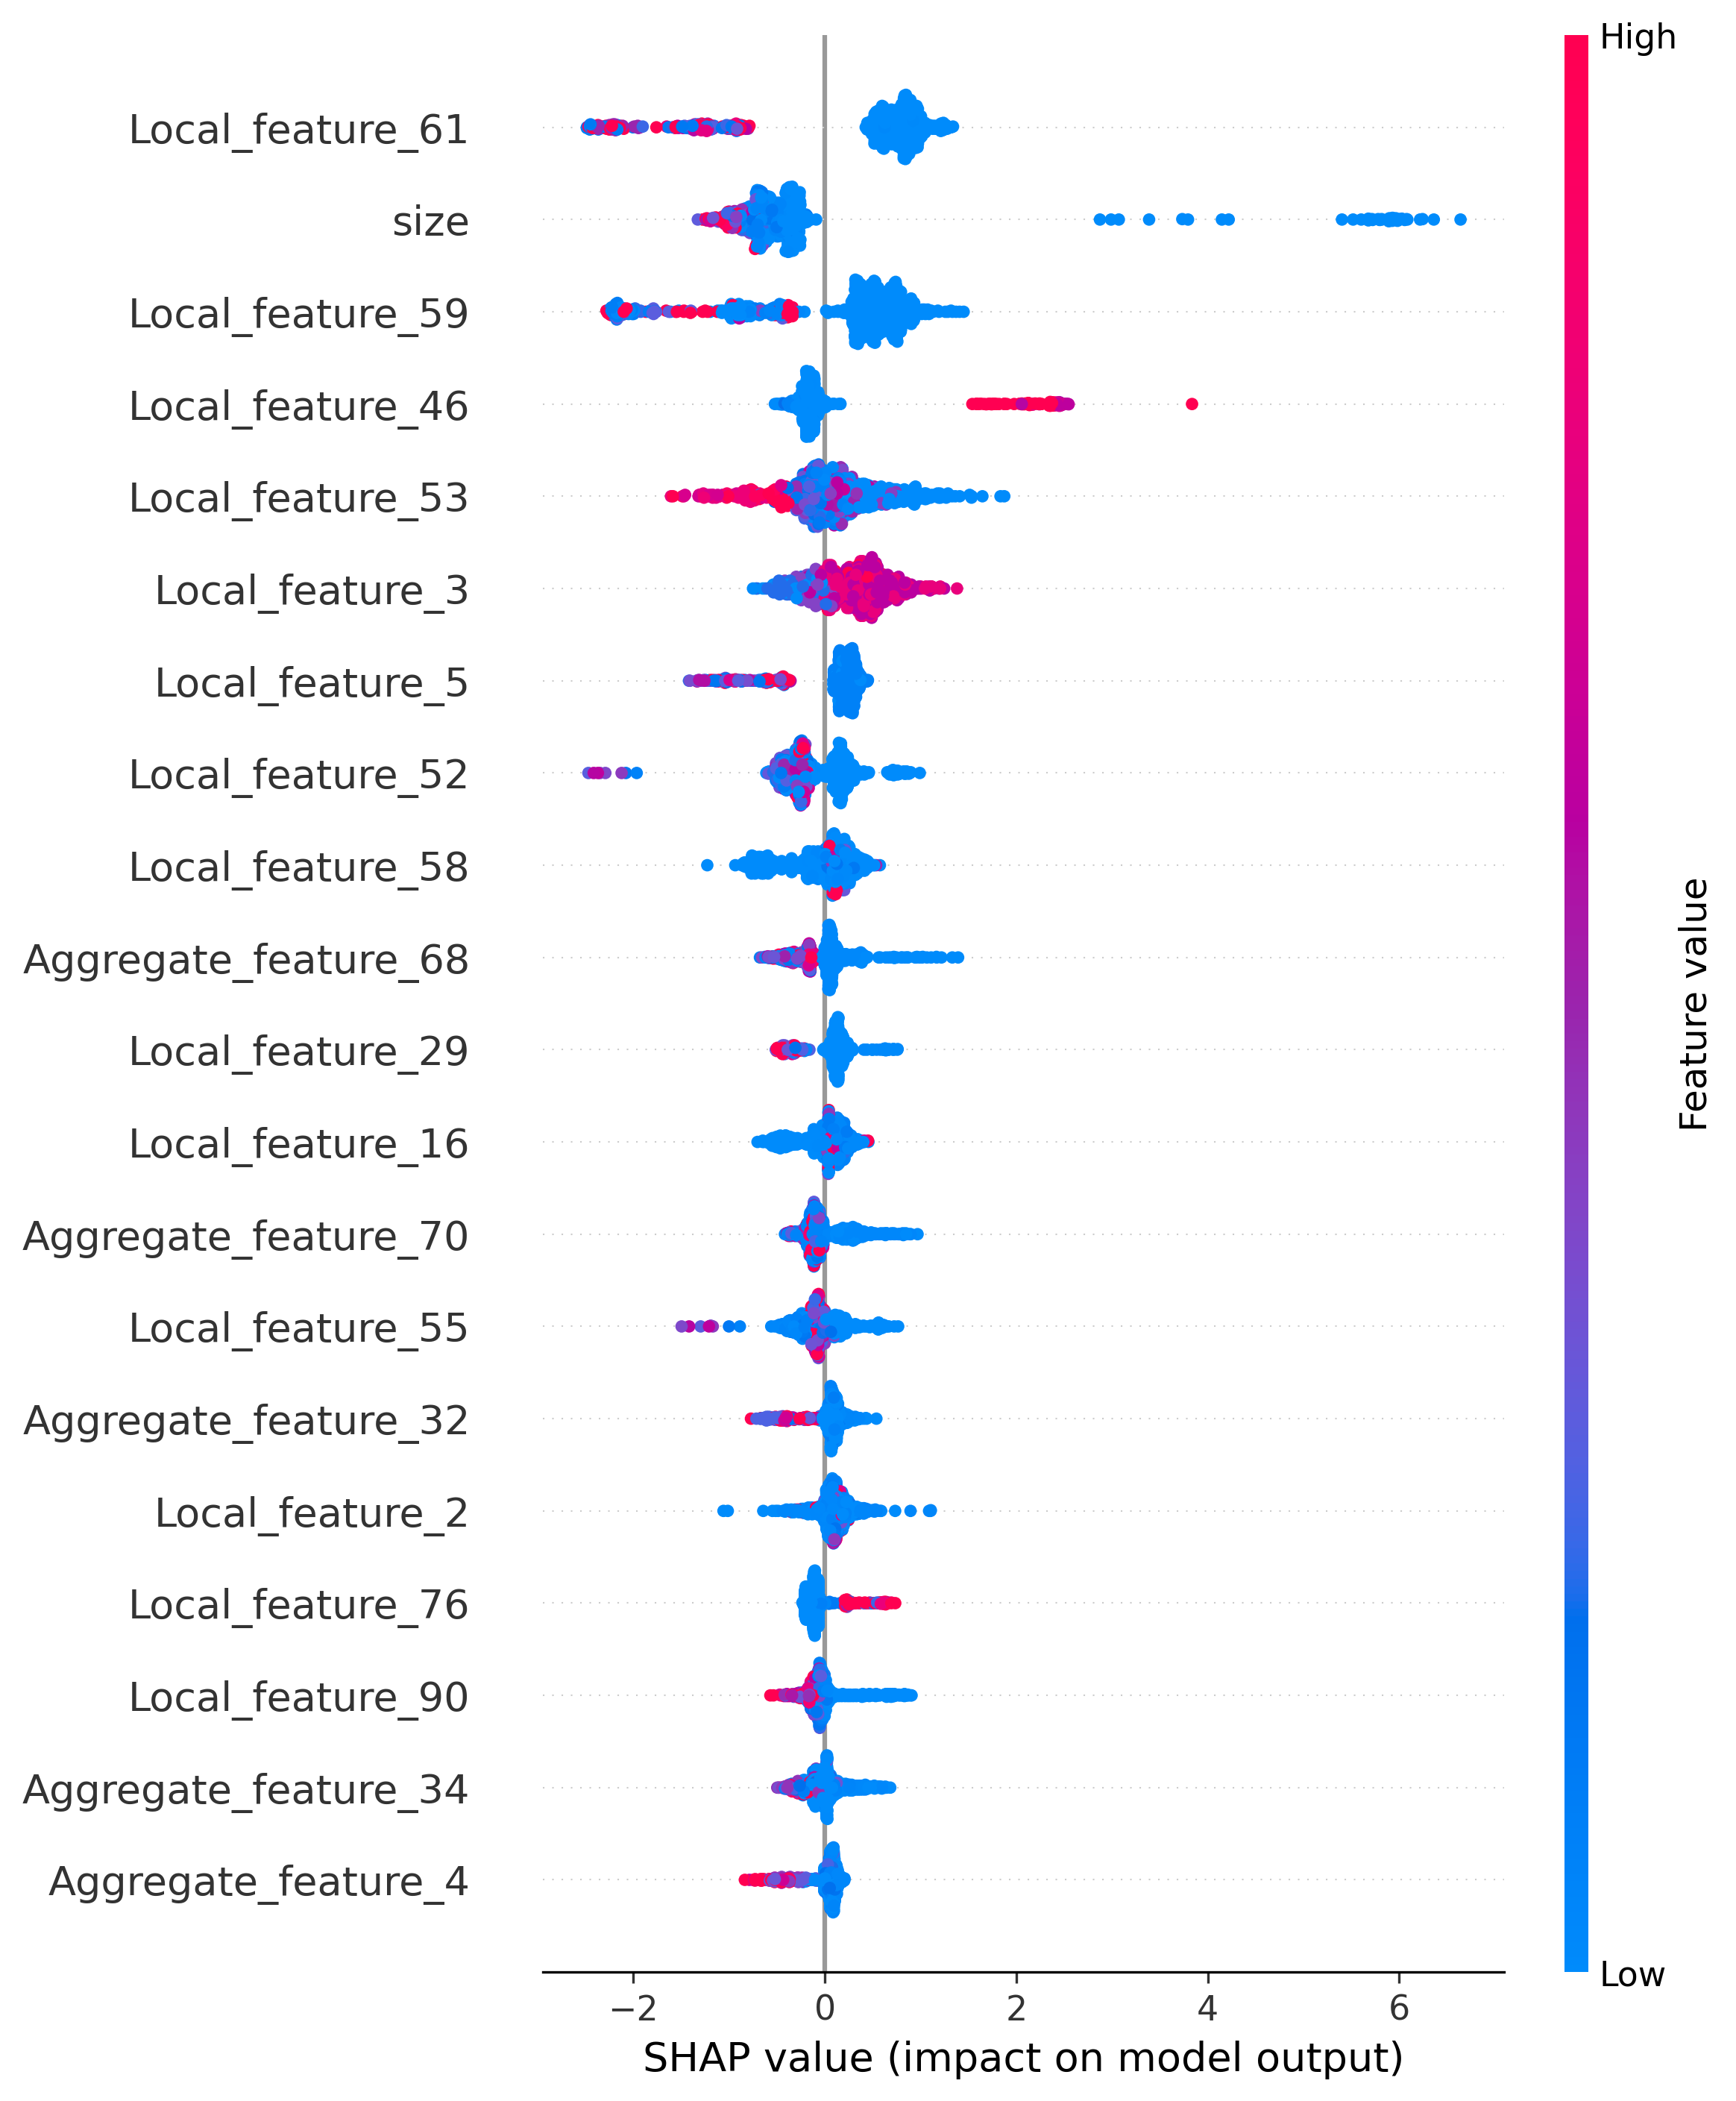

In [11]:
print("\n=== SHAP BEESWARM PLOT ===")

display(
    Image(
        filename=str(tr_results_lgbm_dir / "shap_beeswarm.png")
    )
)

##### **Elliptic++ transactions-combined - LightGBM (balanced)**
---

This dataset is important because it is the same transaction dataset later used by the graph-based models, but here the transactions are treated as independent rows instead of as a graph. LightGBM achieved an **F1-score of 0.753** and a **ROC-AUC of 0.949**. The model achieved very high precision (0.93) but lower recall (0.63), meaning that most flagged transactions were truly illicit, although some fraudulent transactions were still missed.

The SHAP analysis produced an interesting result. Most of the top-ranked features were ***Local_feature_\**** columns rather than ***Aggregate_feature_\**** columns. The first aggregate feature only appeared at rank 9, and only 5 of the top 20 features were aggregate features. This suggests that LightGBM mainly relies on local transaction-level information instead of neighbourhood or graph-related information.

One important named feature was ***size***, which was the second most important feature overall. Larger transaction sizes pushed predictions towards the illicit class. This suggests that more complex transactions, with many inputs and outputs, are more likely to be associated with laundering activity.

The beeswarm plot also showed that several local features strongly influenced the predictions:
- low values of ***Local_feature_61*** pushed towards the illicit class,
- high values of ***size*** strongly pushed towards illicit,
- several other local features also consistently contributed to fraud detection.

Aggregate features, in comparison, had weaker and more stable contributions.

Overall, the SHAP analysis shows that LightGBM mainly detects illicit transactions through local transaction structure rather than graph-based neighbourhood information. This is an important finding because it suggests that the strong performance of the tree-based model does not come from using graph-related features heavily. Instead, the model focuses mainly on transaction-level patterns, which may explain why it was able to outperform GraphSAGE on the same dataset.

#### **Random Forest**

In [2]:
from src.xai import run_shap_random_forest

tr_result_rf = run_shap_random_forest(
    dataset="elliptic-transactions-combined"
)

=== Random Forest Balanced Metrics ===
                          dataset                   model  accuracy  \
0  elliptic-transactions-combined  Random Forest balanced  0.973361   

   precision   recall        f1   roc_auc  
0   0.980282  0.54717  0.702321  0.939754  

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     10438
           1       0.98      0.55      0.70       636

    accuracy                           0.97     11074
   macro avg       0.98      0.77      0.84     11074
weighted avg       0.97      0.97      0.97     11074


SHAP Random Forest results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\random_forest_shap_elliptic-transactions-combined


In [3]:
from IPython.display import Image, display

# Path to SHAP results
tr_results_rf_dir = Path(
    "../models/rq3_xai_models/feature_models/random_forest_shap_elliptic-transactions-combined"
)

In [4]:
metrics = pd.read_csv(tr_results_rf_dir / "metrics.csv")

print("=== Metrics ===")
display(metrics)

=== Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,Random Forest balanced,0.973361,0.980282,0.54717,0.702321,0.939754


In [5]:
feature_importance = pd.read_csv(
    tr_results_rf_dir / "shap_feature_importance.csv"
)

print("\n=== TOP SHAP FEATURES ===")
display(feature_importance.head(20))


=== TOP SHAP FEATURES ===


,feature,mean_abs_shap
0,Local_feature_53,0.035746
1,Local_feature_55,0.032820
2,size,0.021352
3,num_output_addresses,0.016244
4,Local_feature_5,0.014640
5,Local_feature_90,0.014357
6,Local_feature_47,0.014025
7,Local_feature_76,0.013536
8,Local_feature_49,0.013295
9,Local_feature_14,0.013066



=== SHAP SUMMARY BAR PLOT ===


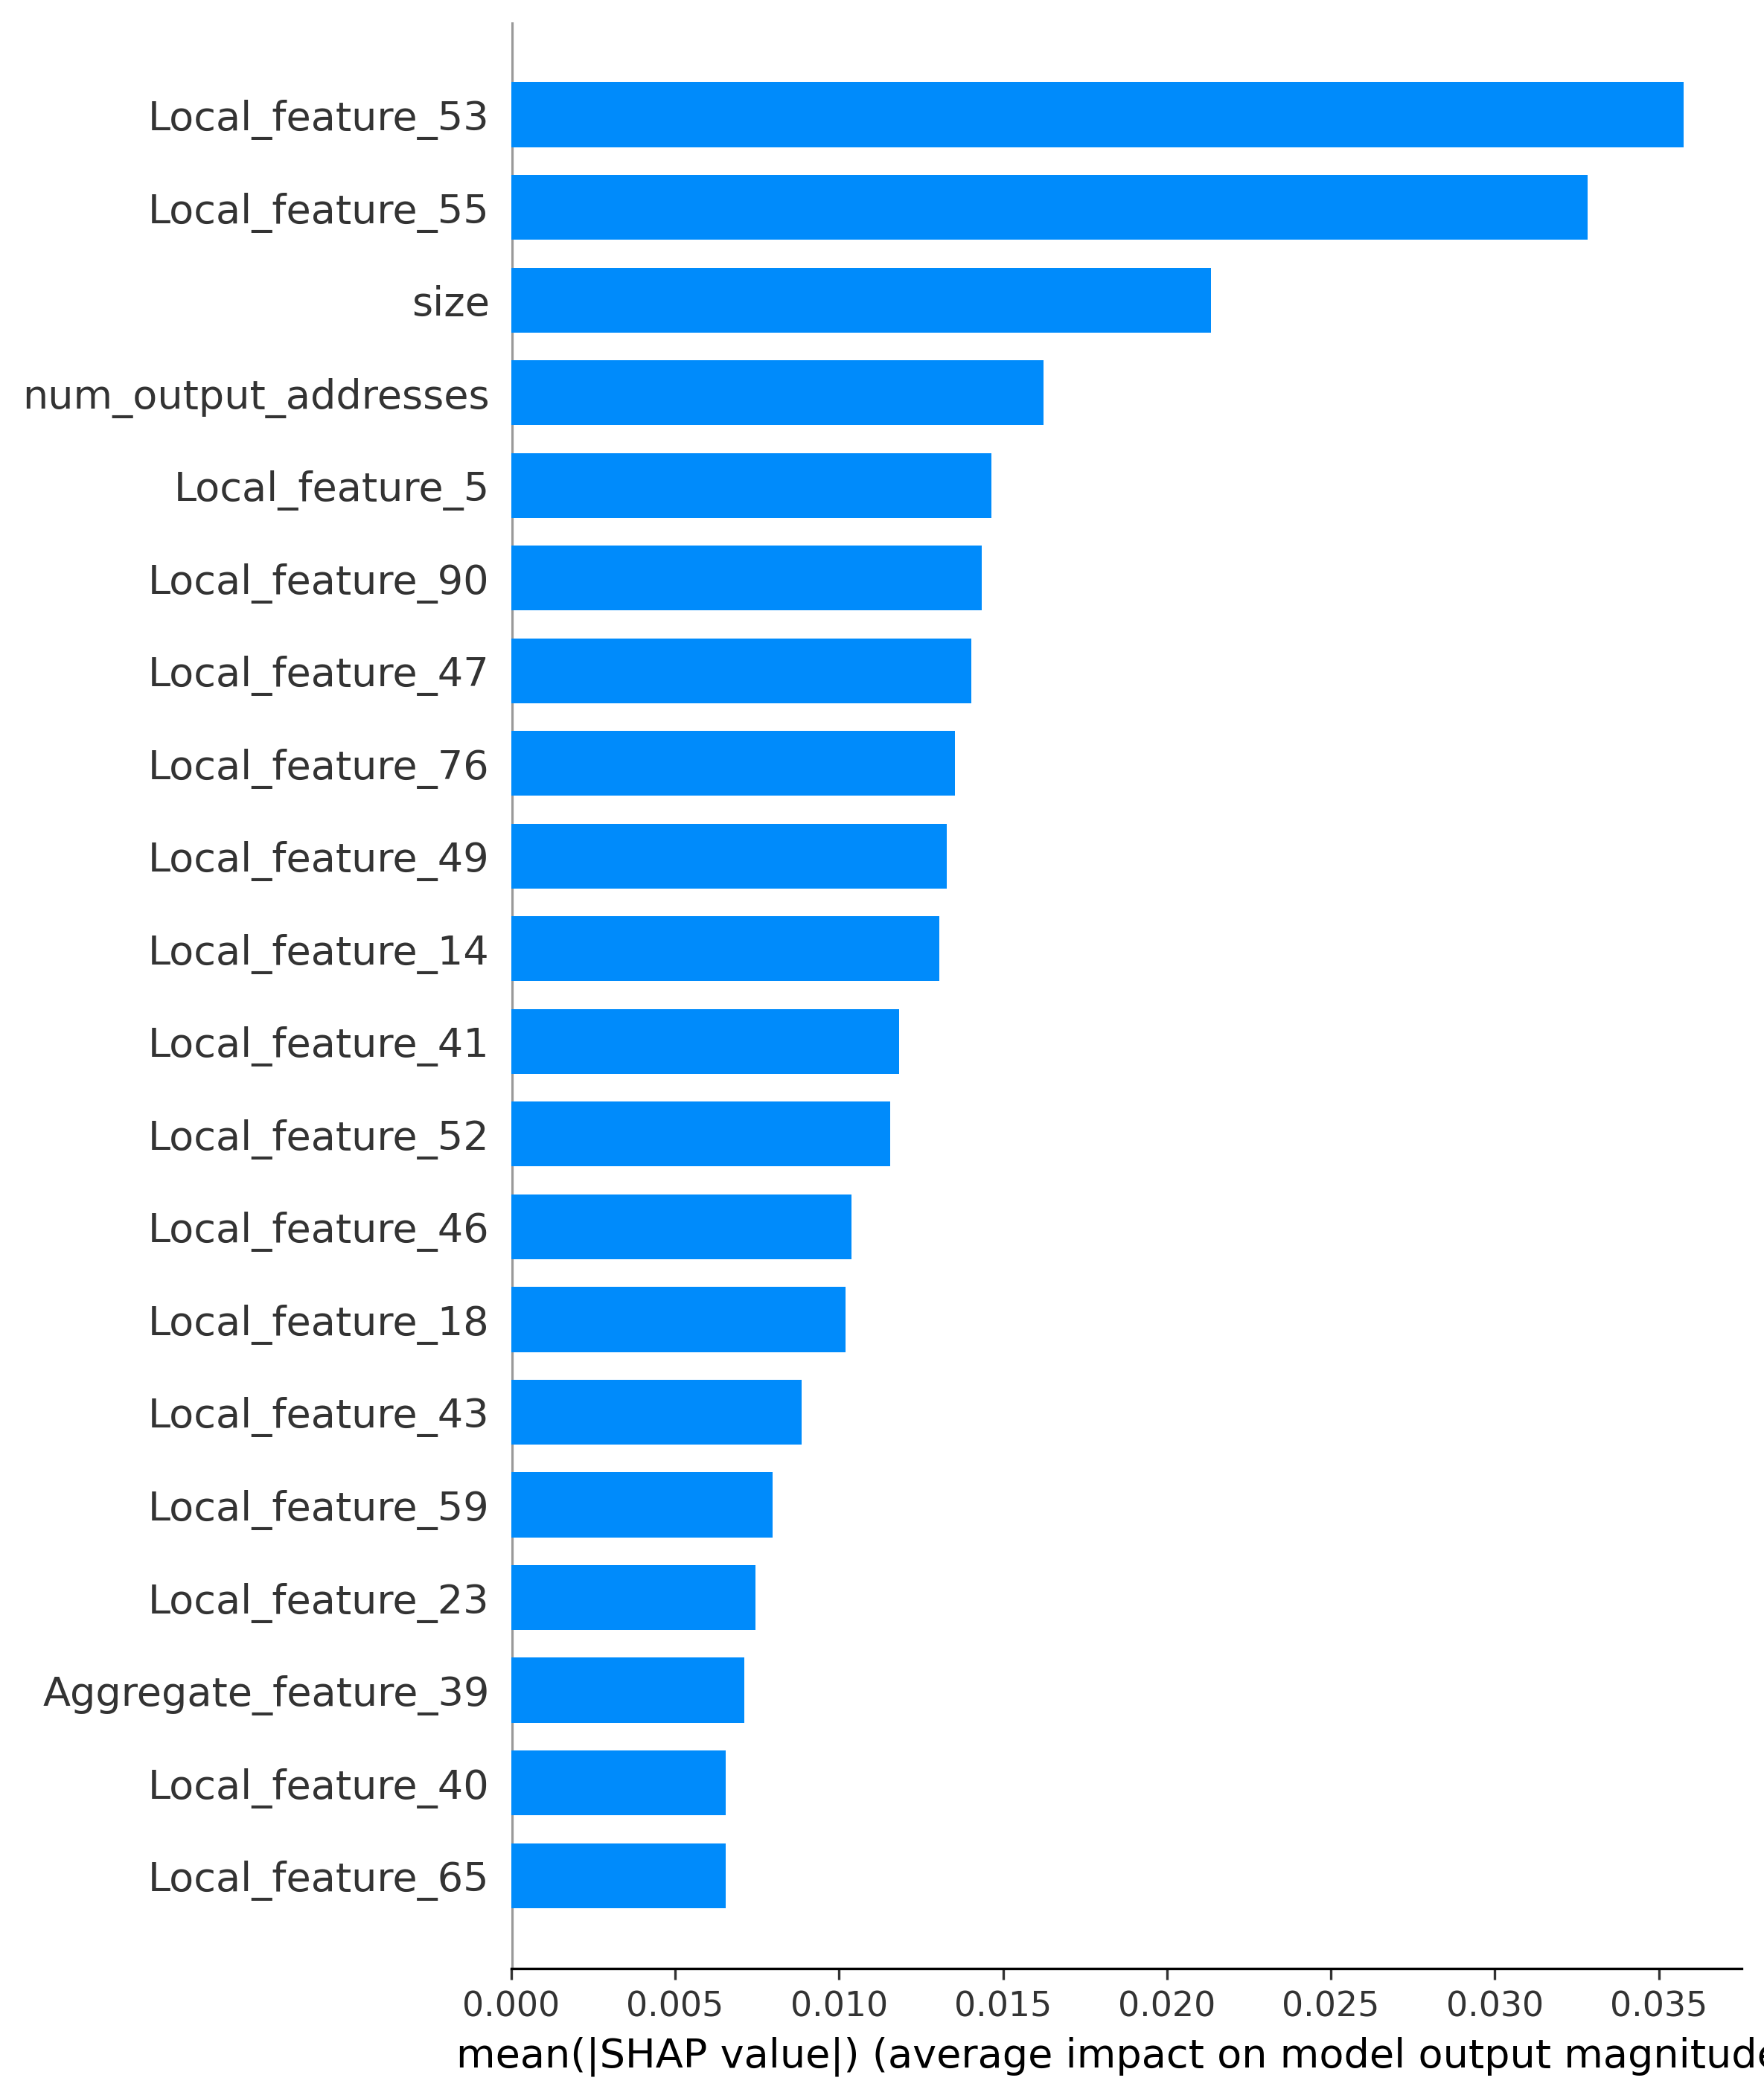

In [6]:
print("\n=== SHAP SUMMARY BAR PLOT ===")

display(
    Image(
        filename=str(tr_results_rf_dir / "shap_summary_bar.png")
    )
)

In [24]:
tr_rf_importance_df = pd.read_csv(project_root / "models"/ "rq3_xai_models"/ "feature_models"/ "random_forest_shap_elliptic-transactions-combined"/ "shap_feature_importance.csv")

def classify_feature_group(feature):
    if feature.startswith("Local_feature"):
        return "Local"

    elif feature.startswith("Aggregate_feature"):
        return "Aggregate"

    else:
        return "Other"


tr_rf_importance_df["feature_group"] = (
    tr_rf_importance_df["feature"]
    .apply(classify_feature_group)
)

tr_rf_group_importance = (
    tr_rf_importance_df
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .reset_index()
)

# Relative contribution
tr_rf_group_importance["relative_importance"] = (
    tr_rf_group_importance["mean_abs_shap"] /
    tr_rf_group_importance["mean_abs_shap"].sum()
)

tr_rf_group_importance

,feature_group,mean_abs_shap,relative_importance
0,Aggregate,0.123430,0.212799
1,Local,0.387850,0.668670
2,Other,0.068751,0.118530


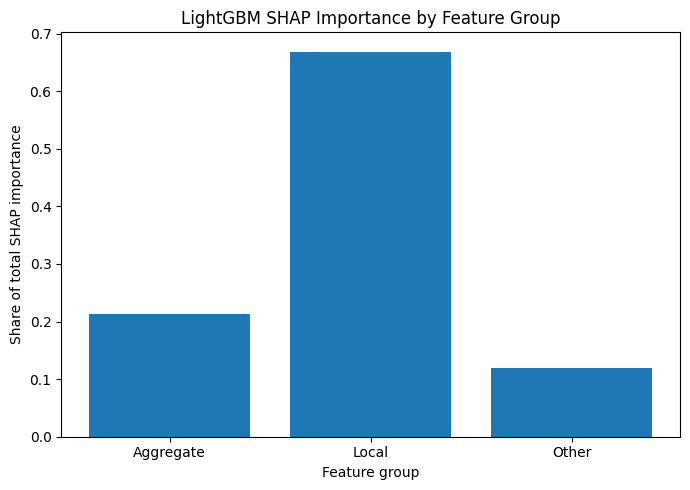

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    tr_rf_group_importance["feature_group"],
    tr_rf_group_importance["relative_importance"]
)

plt.ylabel("Share of total SHAP importance")
plt.xlabel("Feature group")

plt.title(
    "LightGBM SHAP Importance by Feature Group"
)

plt.tight_layout()

plt.show()

In [67]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Get model + SHAP importance
model = tr_result_rf["model"]
shap_importance = tr_result_rf["importance"].copy()

# Random Forest internal importance
internal_importance = pd.DataFrame({
    "feature": tr_result_rf["X_explain"].columns,
    "rf_internal_importance": model.feature_importances_
})

# Merge
comparison_rf = shap_importance.merge(
    internal_importance,
    on="feature",
    how="inner"
)

# Rankings
comparison_rf["shap_rank"] = comparison_rf["mean_abs_shap"].rank(
    ascending=False,
    method="min"
)

comparison_rf["rf_rank"] = comparison_rf["rf_internal_importance"].rank(
    ascending=False,
    method="min"
)

comparison_rf["rank_difference"] = (
    comparison_rf["shap_rank"] - comparison_rf["rf_rank"]
).abs()

# Sort
comparison_rf = comparison_rf.sort_values(
    "mean_abs_shap",
    ascending=False
)

comparison_rf.head(20)

,feature,mean_abs_shap,rf_internal_importance,shap_rank,rf_rank,rank_difference
0,Local_feature_53,0.035746,0.068651,1.0,1.0,0.0
1,Local_feature_55,0.032820,0.056136,2.0,2.0,0.0
2,size,0.021352,0.051086,3.0,3.0,0.0
3,num_output_addresses,0.016244,0.025019,4.0,9.0,5.0
4,Local_feature_5,0.014640,0.025832,5.0,8.0,3.0
5,Local_feature_90,0.014357,0.027284,6.0,7.0,1.0
6,Local_feature_47,0.014025,0.048227,7.0,4.0,3.0
7,Local_feature_76,0.013536,0.011487,8.0,21.0,13.0
8,Local_feature_49,0.013295,0.036528,9.0,6.0,3.0
9,Local_feature_14,0.013066,0.019005,10.0,12.0,2.0


##### **Spearman correlation of Shap Feature Importance and Internal Model**
---

In [68]:
corr, p_value = spearmanr(
    comparison_rf["mean_abs_shap"],
    comparison_rf["rf_internal_importance"]
)

print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.10e}")

Spearman correlation: 0.9466
P-value: 2.0706016029e-90


##### **Normalized comparison plot**
---

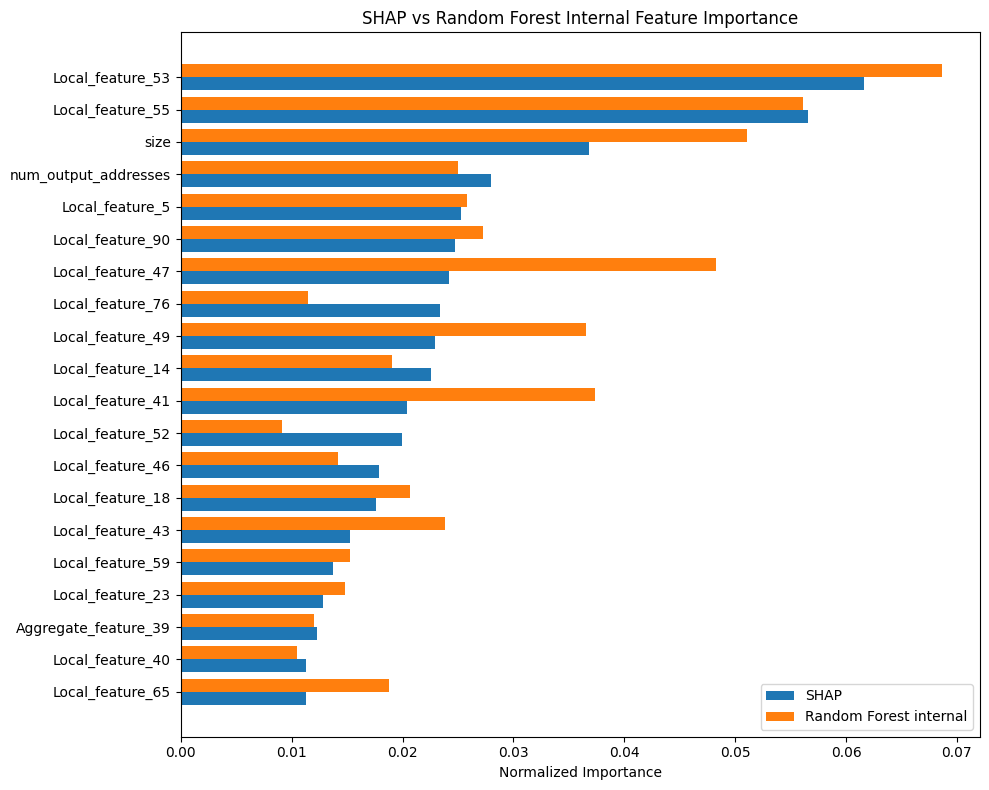

In [69]:
plot_df = comparison_rf.copy()

# Normalize
plot_df["shap_norm"] = (
    plot_df["mean_abs_shap"] /
    plot_df["mean_abs_shap"].sum()
)

plot_df["rf_norm"] = (
    plot_df["rf_internal_importance"] /
    plot_df["rf_internal_importance"].sum()
)

top_n = 20
top = plot_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))

bar_width = 0.4
y_pos = range(len(top))

# SHAP bars
plt.barh(
    [y - bar_width/2 for y in y_pos],
    top["shap_norm"],
    height=bar_width,
    label="SHAP"
)

# RF internal bars
plt.barh(
    [y + bar_width/2 for y in y_pos],
    top["rf_norm"],
    height=bar_width,
    label="Random Forest internal"
)

plt.yticks(y_pos, top["feature"])

plt.xlabel("Normalized Importance")
plt.title("SHAP vs Random Forest Internal Feature Importance")
plt.legend()

plt.tight_layout()

save_dir = tr_result_rf["save_dir"]

plt.savefig(
    save_dir / "rf_shap_vs_internal_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### **SHAP vs Random Forest internal importance**
---

For Random Forest on the transactions dataset, SHAP and the model's internal feature importance showed a very strong agreement, with a **Spearman correlation of 0.95** (p < 0.001). This agreement was higher than the LightGBM comparison on the same dataset. The top three features — ***Local_feature_53***, ***Local_feature_55***, and ***size*** — were ranked identically by both methods, and most local transaction features appeared in similar positions throughout the rankings.

Some differences were still observed in the middle of the rankings. For example, ***Local_feature_52*** and ***Local_feature_76*** were ranked higher by SHAP than by the internal importance scores. This reflects the difference between the two methods: internal importance measures how often a feature is used in decision splits, while SHAP measures how strongly the feature contributes to the final predictions.

Overall, the high correlation confirms that the SHAP explanations are consistent with the internal behaviour of the Random Forest model. Both methods also agree on the main conclusion that local transaction-level features dominate the fraud signal, while aggregate graph-related features contribute much less.

---
---


=== SHAP BEESWARM PLOT ===


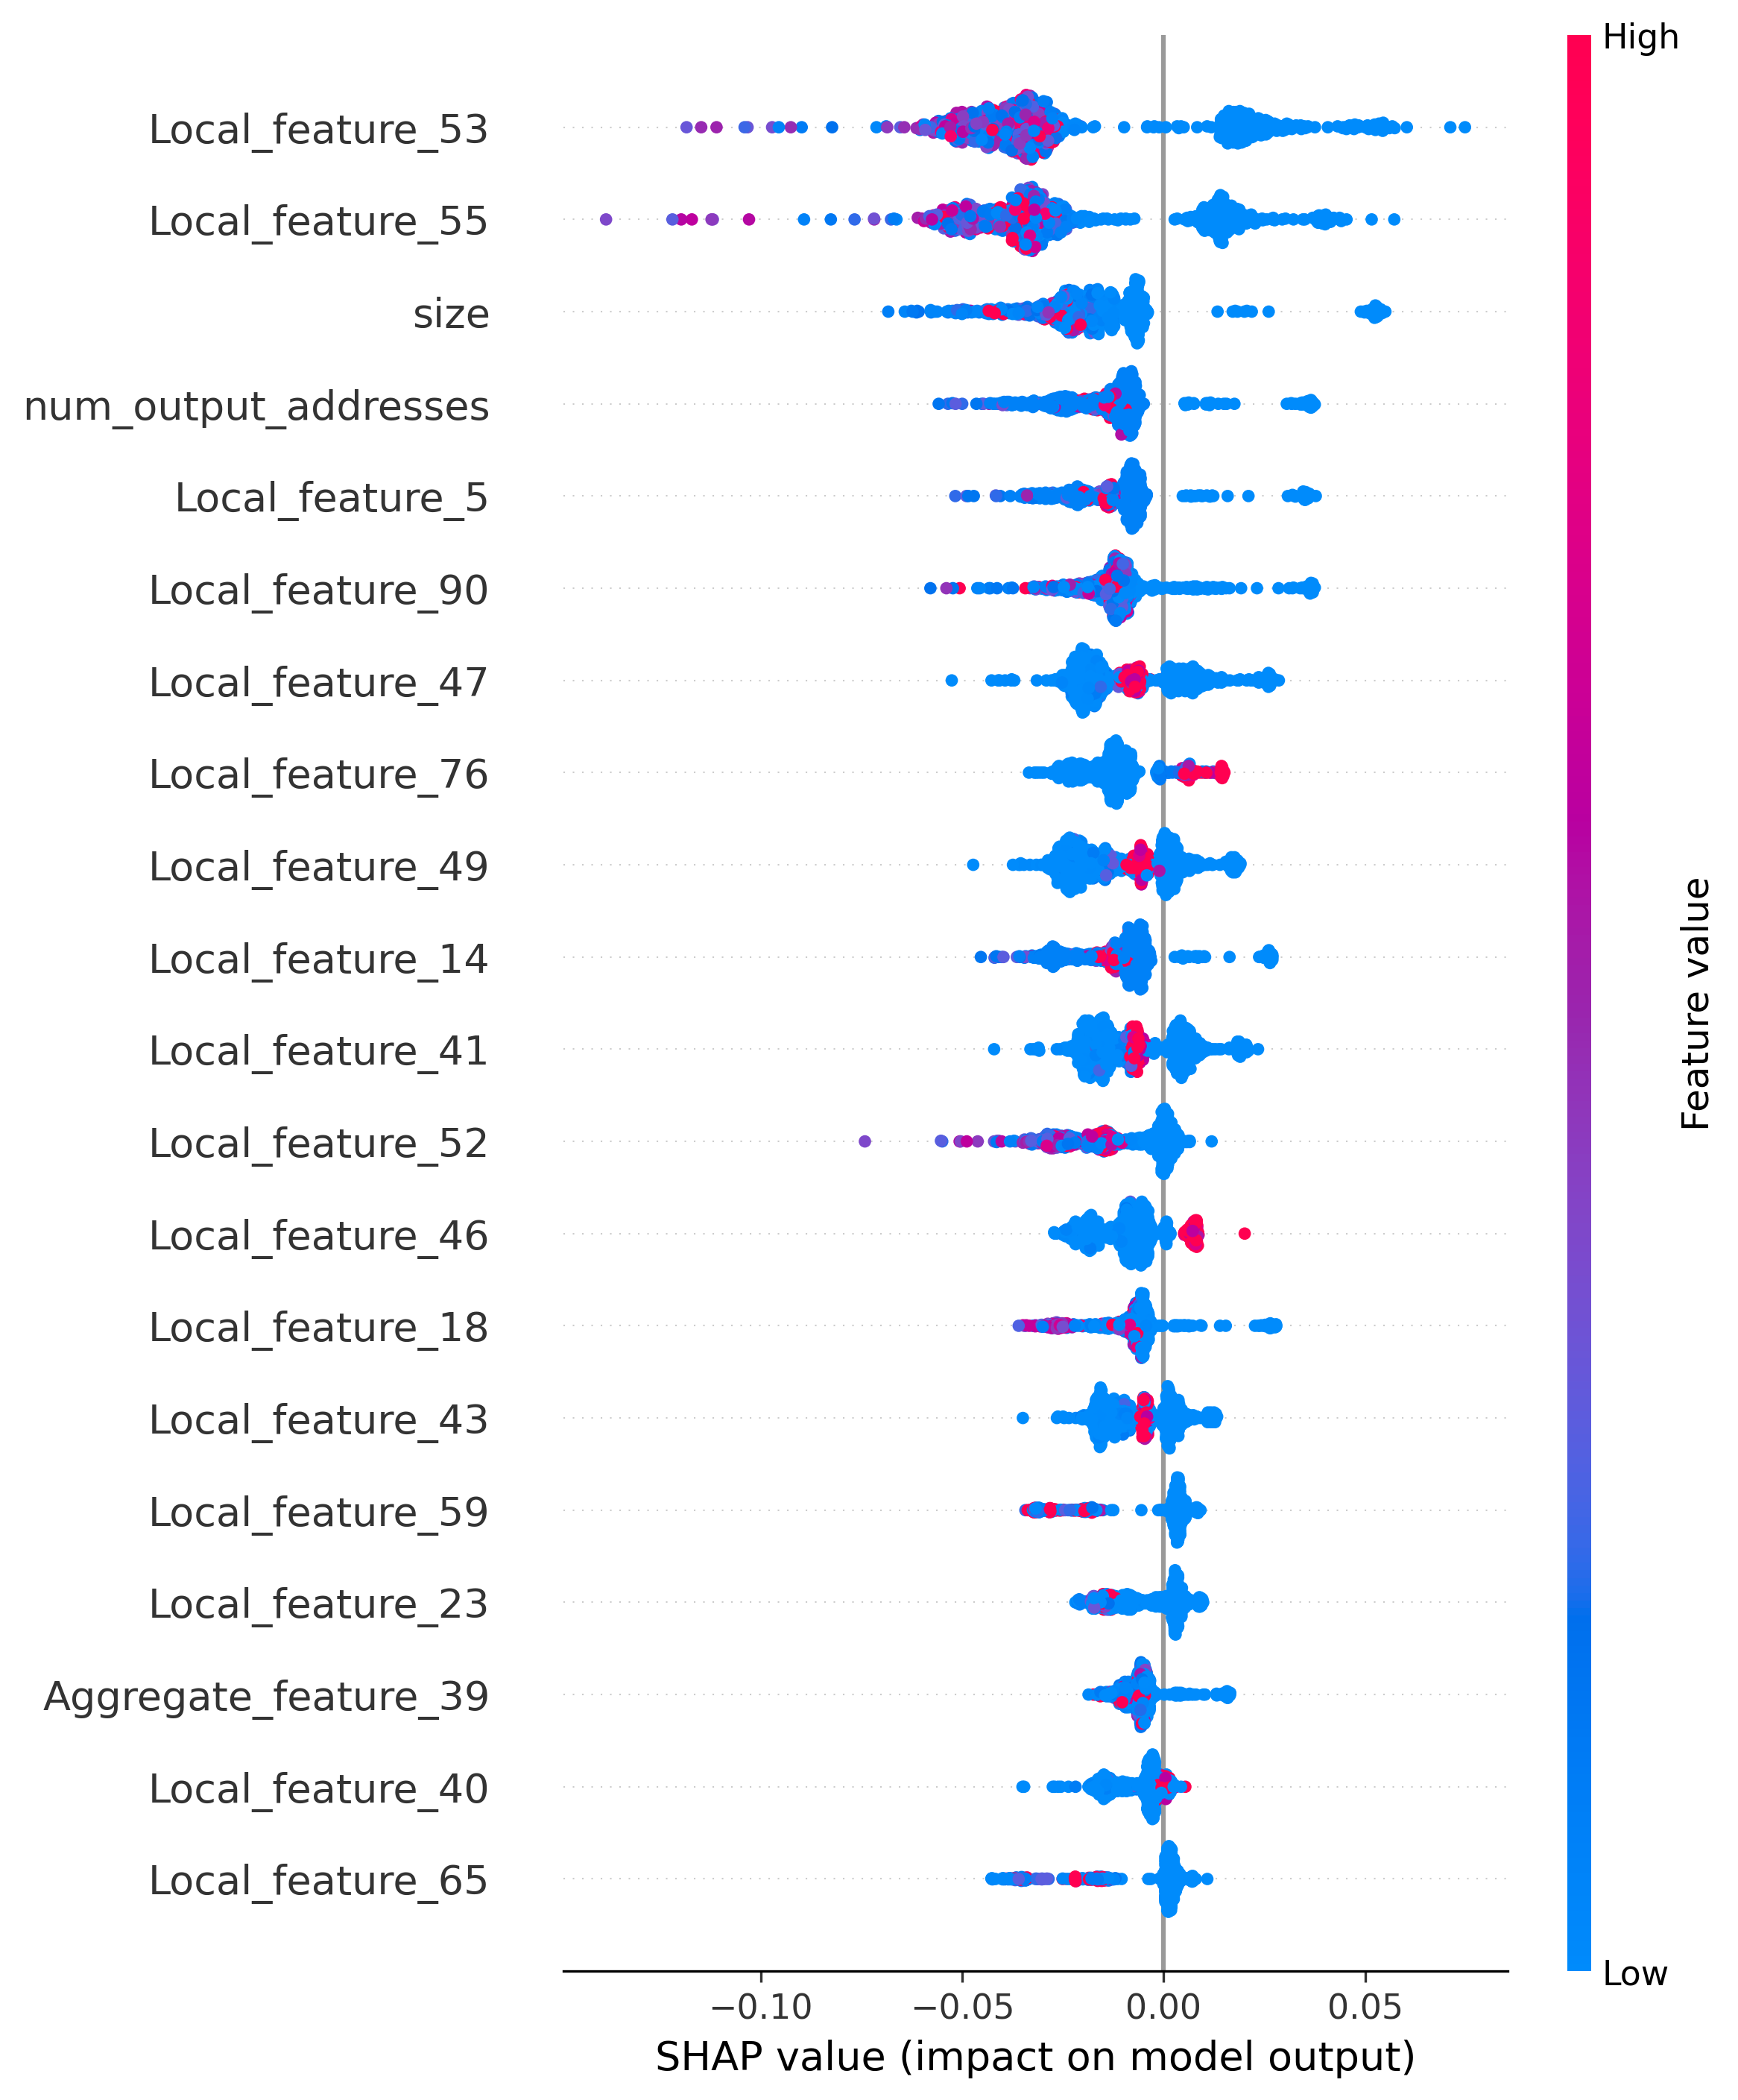

In [7]:
print("\n=== SHAP BEESWARM PLOT ===")

display(
    Image(
        filename=str(tr_results_rf_dir / "shap_beeswarm.png")
    )
)

##### **Elliptic++ transactions-combined - Random Forest (balanced)**
---

Random Forest achieved an **F1-score of 0.702** and a **ROC-AUC of 0.940** on the Elliptic++ transactions dataset, slightly lower than LightGBM. The model achieved extremely high precision (0.98) but lower recall (0.55), meaning that most flagged transactions were truly illicit, but many fraudulent transactions were still missed.

The SHAP analysis strongly confirms the findings from LightGBM. Almost all of the top-ranked features were ***Local_feature_\**** columns or directly interpretable transaction metadata such as ***size*** and ***num_output_addresses***. Only one aggregate feature appeared in the top 20 features.

The most important features included:
- ***Local_feature_53***
- ***Local_feature_55***
- ***size***
- ***num_output_addresses***
- ***Local_feature_5***
- ***Local_feature_90***

Many of these features also appeared among the most important LightGBM features. This strong agreement between the two models suggests that local transaction-level information contains most of the important fraud signal, while aggregate neighbourhood features contribute much less.

The beeswarm plot showed several important patterns:
- high values of ***Local_feature_53*** and ***Local_feature_55*** pushed predictions towards the illicit class,
- larger transaction sizes increased the probability of being classified as fraudulent,
- transactions with many output addresses were also more likely to be flagged as illicit.

Compared to LightGBM, Random Forest distributed feature importance more evenly across multiple features and produced smaller SHAP values overall. This means the model relied on a broader combination of signals instead of focusing strongly on a few dominant features.

Overall, both Random Forest and LightGBM reached the same main conclusion: local transaction-level features are much more important than aggregate graph-related features for detecting illicit transactions in the Elliptic++ dataset. This helps explain why the tree-based models were able to outperform GraphSAGE on the same data.

#### **Elliptic++ transactions-combined -  XAI Discussion**
---

The Elliptic++ transactions dataset shows the strongest agreement between the two tree-based models. Even though LightGBM and Random Forest use different learning methods, both models identify the same main fraud signals. They mainly rely on local transaction-level features, while aggregate neighbourhood features play only a small role.

The main difference between the models is their prediction strategy:
- **LightGBM** achieved a higher **F1-score of 0.753**, with high precision (0.93) and moderate recall (0.63).
- **Random Forest** achieved an **F1-score of 0.702**, with extremely high precision (0.98) but lower recall (0.55).

Both models identified similar important features, including:
- **Local_feature_53**
- **Local_feature_55**
- **size**

This strong agreement suggests that the important fraud patterns are reliable and not caused by one specific model.

The SHAP analysis also changes the interpretation from Part 1. Earlier, it was assumed that tree-based models performed well because they indirectly used graph-related aggregate features. However, the SHAP results show the opposite. Both tree models mainly focused on local transaction features and gave much less importance to aggregate neighbourhood features.

This means that the performance difference between the tree-based models and GraphSAGE is not simply about how well graph information is used. Instead, the models focus on different parts of the feature set and learn different types of fraud patterns.

---
---

### **Summary of SHAP validation across all models**
---

Across all six model and dataset combinations, the SHAP feature importance rankings showed very strong agreement with each model's built-in feature importance scores. The Spearman correlations ranged from **0.90 to 0.96** (all p < 0.001), showing that the explanations were highly consistent across different models and datasets.

Random Forest generally showed slightly higher agreement than LightGBM. This is expected because Random Forest's internal importance is more closely related to overall feature contribution, while LightGBM's split-based importance focuses more on how often features are used in decision splits.

The main differences between SHAP and the internal importance scores appeared for features that were used rarely but had a strong effect when they were used, or features that were used often but contributed less to the final prediction.

Overall, these validation results provide strong evidence that the SHAP explanations throughout this analysis reflect the real behaviour of the models rather than artefacts of the explanation method.

---
---

### **Elliptic-transactions-graph**
---

In [2]:
from src.data_loader import load_graph_xai_dataset

data, metadata = load_graph_xai_dataset()

print(metadata["test_illicit_nodes"][:20])

[156510, 156544, 156881, 156892, 156893, 156999, 157011, 157035, 157172, 157262, 157330, 157356, 157525, 157528, 157531, 157547, 157573, 157600, 157848, 157849]


In [3]:
import numpy as np

test_illicit_nodes = metadata["test_illicit_nodes"]
time_steps = data.time_steps.cpu().numpy()

# Show how illicit nodes are distributed across test time steps
illicit_steps = [time_steps[idx] for idx in test_illicit_nodes]

import pandas as pd
dist = pd.Series(illicit_steps).value_counts().sort_index()
print("Illicit test nodes per time step:")
print(dist)
print(f"\nTotal illicit test nodes: {len(test_illicit_nodes)}")

Illicit test nodes per time step:
40    112
41    116
42    239
43     24
44     24
45      5
46      2
47     22
48     36
49     56
Name: count, dtype: int64

Total illicit test nodes: 636


In [4]:
from collections import defaultdict

# Group correctly-classified illicit test nodes by time step
# (we still want correctly classified — predictions matter)
import torch
import torch.nn.functional as F

from src.xai import train_graphsage_xai

model, _ = train_graphsage_xai(
    data=data,
    device="cpu",
    seed=42,
    deterministic=True,
    class_balanced=True,
)
model.eval()

with torch.no_grad():
    preds = model(data.x, data.edge_index).argmax(dim=1).cpu().numpy()

# Bucket illicit nodes by time step, keeping only correctly classified
buckets = defaultdict(list)
for idx in test_illicit_nodes:
    if preds[idx] == 1:                # correctly predicted as illicit
        t = int(time_steps[idx])
        buckets[t].append(idx)

# Show what's available
for t in sorted(buckets.keys()):
    print(f"Step {t}: {len(buckets[t])} correctly-classified illicit nodes")

Step 40: 78 correctly-classified illicit nodes
Step 41: 103 correctly-classified illicit nodes
Step 42: 195 correctly-classified illicit nodes
Step 43: 1 correctly-classified illicit nodes
Step 47: 1 correctly-classified illicit nodes
Step 48: 1 correctly-classified illicit nodes
Step 49: 1 correctly-classified illicit nodes


In [5]:
selected_nodes = []

# Stable window: 2 per step
for t in [40, 41, 42]:
    if t in buckets and len(buckets[t]) >= 2:
        selected_nodes.extend(buckets[t][:2])

# Post-shutdown: take what's available (1 per step where possible)
for t in [43, 47, 48, 49]:
    if t in buckets and len(buckets[t]) >= 1:
        selected_nodes.extend(buckets[t][:1])

print(f"Selected {len(selected_nodes)} nodes:")
for idx in selected_nodes:
    t = int(time_steps[idx])
    print(f"  node {idx} at time step {t}")

Selected 10 nodes:
  node 156510 at time step 40
  node 156544 at time step 40
  node 161023 at time step 41
  node 161025 at time step 41
  node 166281 at time step 42
  node 166788 at time step 42
  node 175892 at time step 43
  node 192390 at time step 47
  node 199459 at time step 48
  node 201550 at time step 49


In [6]:
from src.xai import run_gnnexplainer_graphsage

graphsage_result = run_gnnexplainer_graphsage(node_indices=selected_nodes)

[1/10] Explaining node 156510...
  -> illicit_node_156510 | true=1 pred=1 p=0.518
[2/10] Explaining node 156544...
  -> illicit_node_156544 | true=1 pred=1 p=1.000
[3/10] Explaining node 161023...
  -> illicit_node_161023 | true=1 pred=1 p=0.874
[4/10] Explaining node 161025...
  -> illicit_node_161025 | true=1 pred=1 p=0.993
[5/10] Explaining node 166281...
  -> illicit_node_166281 | true=1 pred=1 p=0.944
[6/10] Explaining node 166788...
  -> illicit_node_166788 | true=1 pred=1 p=0.934
[7/10] Explaining node 175892...
  -> illicit_node_175892 | true=1 pred=1 p=0.666
[8/10] Explaining node 192390...
  -> illicit_node_192390 | true=1 pred=1 p=0.529
[9/10] Explaining node 199459...
  -> illicit_node_199459 | true=1 pred=1 p=0.539
[10/10] Explaining node 201550...
  -> illicit_node_201550 | true=1 pred=1 p=0.520

All results saved under: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\graph_models\graphsage_gnnexplainer


In [2]:
from IPython.display import Image, display

# Path to GNNExplainer results
tr_graphsage_result_dir = Path(
    "../models/rq3_xai_models/graph_models/graphsage_gnnexplainer"
)

In [4]:
feature_importance = pd.read_csv(
    tr_graphsage_result_dir / "illicit_node_166281_step42" / "feature_importance.csv"
)

print("\n=== TOP GNNExplainer FEATURES ===")
display(feature_importance.head(15))


=== TOP GNNExplainer FEATURES ===


,feature,importance
0,Local_feature_90,0.000008
1,Aggregate_feature_19,0.000008
2,Aggregate_feature_63,0.000007
3,Aggregate_feature_22,0.000007
4,Local_feature_88,0.000006
5,num_input_addresses,0.000006
6,Aggregate_feature_71,0.000006
7,Local_feature_91,0.000006
8,Aggregate_feature_56,0.000006
9,Aggregate_feature_72,0.000006


In [5]:
folders = sorted(tr_graphsage_result_dir.iterdir())
for f in folders:
    df = pd.read_csv(f / "feature_importance.csv")
    top1 = df["importance"].iloc[0]
    top15 = df["importance"].iloc[14]
    ratio = top1 / top15 if top15 > 0 else float("inf")
    print(f"{f.name}: top1={top1:.2e}, top15={top15:.2e}, ratio={ratio:.2f}x")

illicit_node_156510_step40: top1=4.07e-06, top15=3.71e-06, ratio=1.10x
illicit_node_156544_step40: top1=5.08e-06, top15=3.72e-06, ratio=1.36x
illicit_node_161023_step41: top1=8.44e-06, top15=5.66e-06, ratio=1.49x
illicit_node_161025_step41: top1=6.26e-06, top15=4.04e-06, ratio=1.55x
illicit_node_166281_step42: top1=8.36e-06, top15=5.15e-06, ratio=1.62x
illicit_node_166788_step42: top1=7.64e-06, top15=4.31e-06, ratio=1.77x
illicit_node_175892_step43: top1=4.05e-06, top15=3.80e-06, ratio=1.07x
illicit_node_192390_step47: top1=7.50e-06, top15=4.56e-06, ratio=1.64x
illicit_node_199459_step48: top1=3.93e-06, top15=3.69e-06, ratio=1.06x
illicit_node_201550_step49: top1=3.89e-06, top15=3.66e-06, ratio=1.06x


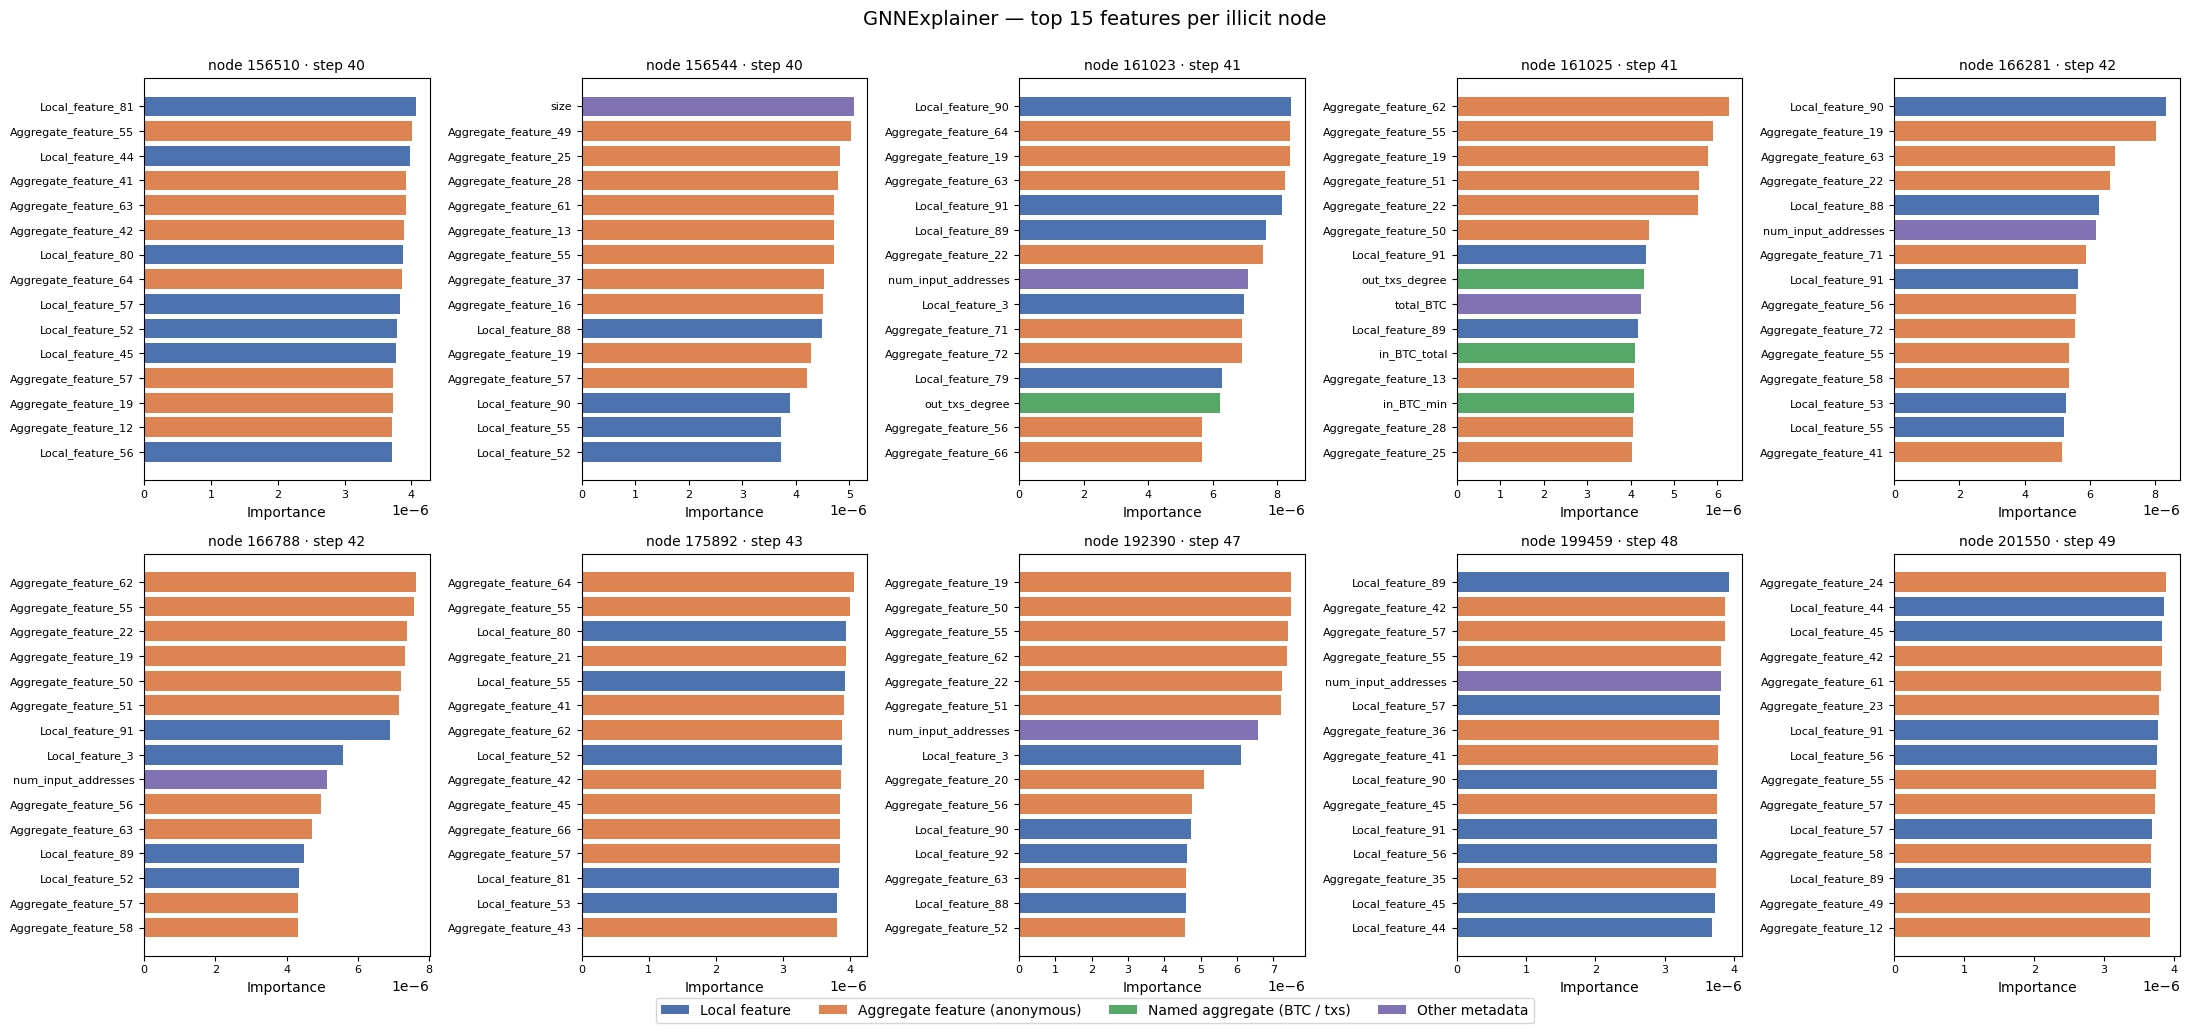

Saved: ..\models\rq3_xai_models\graph_models\graphsage_gnnexplainer\top15_features_per_node.png


In [14]:
import matplotlib.pyplot as plt

folders = [f for f in sorted(tr_graphsage_result_dir.iterdir()) if f.is_dir()]

# 2 rows × 5 cols grid
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, folder in enumerate(folders):
    df = pd.read_csv(folder / "feature_importance.csv")
    top = df.head(15).iloc[::-1]   # reverse so highest is at the top

    # Color by feature family
    def feature_color(name):
        if name.startswith("Local_feature_"):
            return "#4C72B0"          # blue   = local
        elif name.startswith("Aggregate_feature_"):
            return "#DD8452"          # orange = anonymous aggregate
        elif any(kw in name for kw in ["in_BTC", "out_BTC", "in_txs", "out_txs"]):
            return "#55A868"          # green  = named aggregate
        else:
            return "#8172B3"          # purple = metadata

    colors = [feature_color(f) for f in top["feature"]]

    ax = axes[i]
    ax.barh(top["feature"], top["importance"], color=colors)
    ax.set_title(folder.name.replace("illicit_node_", "node ").replace("_step", " · step "),
                 fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("Importance")

# Shared legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", label="Local feature"),
    Patch(facecolor="#DD8452", label="Aggregate feature (anonymous)"),
    Patch(facecolor="#55A868", label="Named aggregate (BTC / txs)"),
    Patch(facecolor="#8172B3", label="Other metadata"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle("GNNExplainer — top 15 features per illicit node", fontsize=14, y=1.00)
plt.tight_layout()

# Save
out_path = tr_graphsage_result_dir / "top15_features_per_node.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")

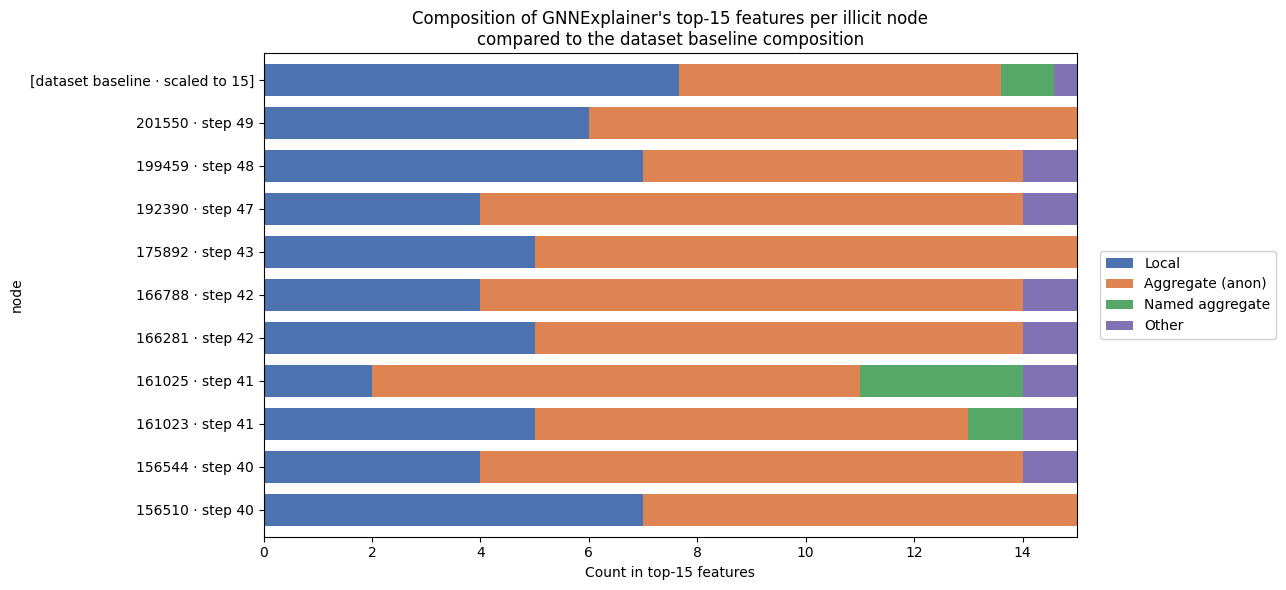

Saved: ..\models\rq3_xai_models\graph_models\graphsage_gnnexplainer\top15_composition_per_node.png

Share table:
                                   Local  Aggregate (anon)  Named aggregate  \
node                                                                          
156510 · step 40                     7.0               8.0              0.0   
156544 · step 40                     4.0              10.0              0.0   
161023 · step 41                     5.0               8.0              1.0   
161025 · step 41                     2.0               9.0              3.0   
166281 · step 42                     5.0               9.0              0.0   
166788 · step 42                     4.0              10.0              0.0   
175892 · step 43                     5.0              10.0              0.0   
192390 · step 47                     4.0              10.0              0.0   
199459 · step 48                     7.0               7.0              0.0   
201550 · step 49  

In [17]:
import matplotlib.pyplot as plt

folders = [f for f in sorted(tr_graphsage_result_dir.iterdir()) if f.is_dir()]

def classify(name):
    if name.startswith("Local_feature_"):
        return "Local"
    elif name.startswith("Aggregate_feature_"):
        return "Aggregate (anon)"
    elif any(kw in name for kw in ["in_BTC", "out_BTC", "in_txs", "out_txs"]):
        return "Named aggregate"
    else:
        return "Other"

records = []
for folder in folders:
    df = pd.read_csv(folder / "feature_importance.csv").head(15)
    counts = df["feature"].apply(classify).value_counts()
    record = {
        "node": folder.name.replace("illicit_node_", "").replace("_step", " · step "),
        "Local": counts.get("Local", 0),
        "Aggregate (anon)": counts.get("Aggregate (anon)", 0),
        "Named aggregate": counts.get("Named aggregate", 0),
        "Other": counts.get("Other", 0),
    }
    records.append(record)

share_df = pd.DataFrame(records).set_index("node")

# Add a "baseline" row showing the share in the full feature set
baseline = pd.Series({
    "Local": 93,
    "Aggregate (anon)": 72,
    "Named aggregate": 12,
    "Other": 5,
})
# Scale baseline to "out of 15" for comparison
baseline_scaled = (baseline / baseline.sum() * 15)
share_df.loc["[dataset baseline · scaled to 15]"] = baseline_scaled

# Plot
colors = {
    "Local": "#4C72B0",
    "Aggregate (anon)": "#DD8452",
    "Named aggregate": "#55A868",
    "Other": "#8172B3",
}

fig, ax = plt.subplots(figsize=(13, 6))
share_df[["Local", "Aggregate (anon)", "Named aggregate", "Other"]].plot(
    kind="barh",
    stacked=True,
    color=[colors[c] for c in ["Local", "Aggregate (anon)", "Named aggregate", "Other"]],
    ax=ax,
    width=0.75,
)

ax.set_xlabel("Count in top-15 features")
ax.set_title("Composition of GNNExplainer's top-15 features per illicit node\n"
             "compared to the dataset baseline composition")
ax.set_xlim(0, 15)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=0.9
)
ax.axvline(15, color="black", linewidth=0.5)
plt.tight_layout()

out_path = tr_graphsage_result_dir / "top15_composition_per_node.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")
print("\nShare table:")
print(share_df.round(1))

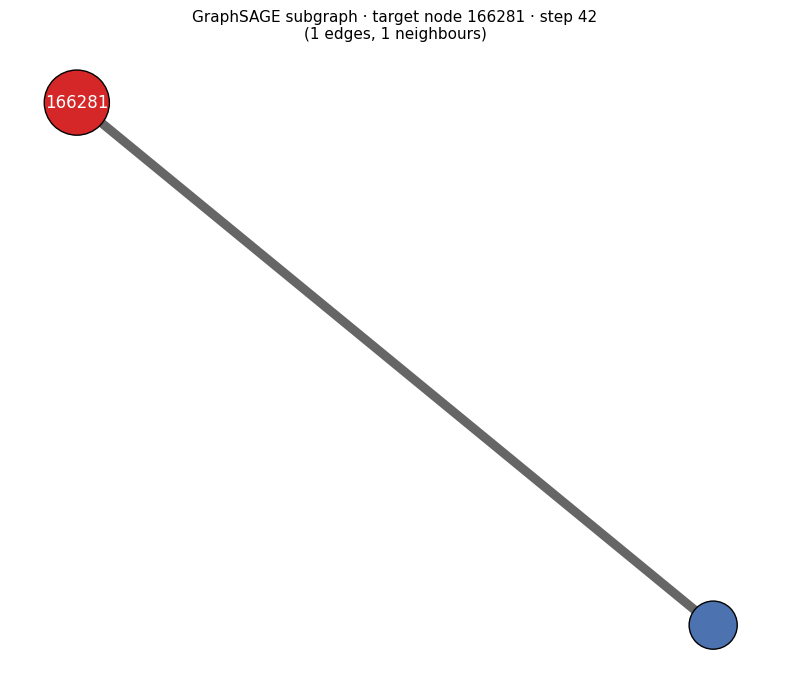

  Saved: ..\models\rq3_xai_models\graph_models\graphsage_gnnexplainer\illicit_node_166281_step42\subgraph.png


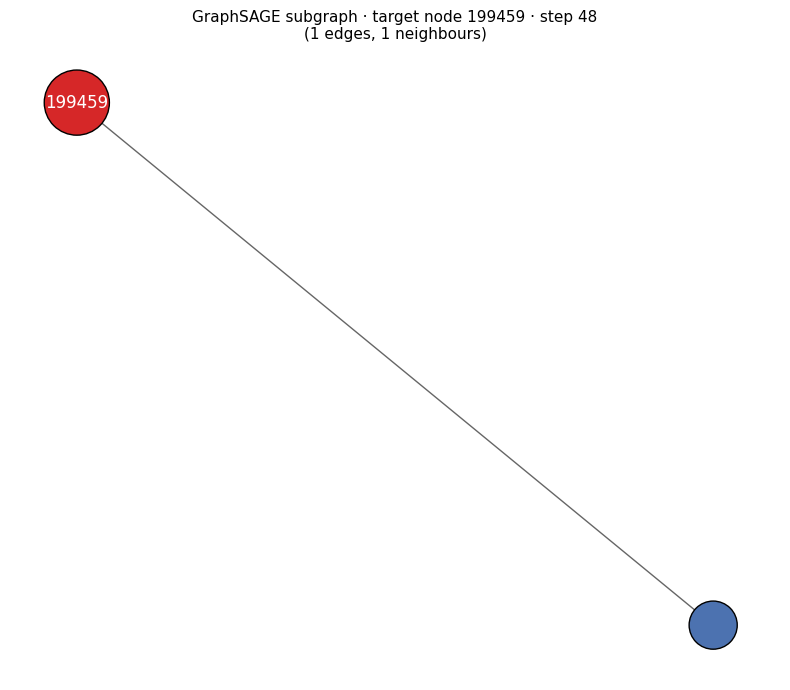

  Saved: ..\models\rq3_xai_models\graph_models\graphsage_gnnexplainer\illicit_node_199459_step48\subgraph.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from src.data_loader import load_graph_xai_dataset

# Load the graph once so we can look up labels for neighbours
data, metadata = load_graph_xai_dataset()
all_labels = data.y.cpu().numpy()
all_time_steps = data.time_steps.cpu().numpy()

def plot_node_subgraph(folder_name, node_index, max_neighbors=15, top_edge_quantile=0.0):
    """
    Draw the 1-hop subgraph around the explained node.
    Edge thickness = GNNExplainer edge importance.
    Node colour = true label (illicit=red, licit=blue, unknown=grey).
    """
    folder = tr_graphsage_result_dir / folder_name
    edge_df = pd.read_csv(folder / "edge_importance.csv")

    # Edges involving the target node (either as source or target)
    relevant = edge_df[
        (edge_df["source_node"] == node_index) |
        (edge_df["target_node"] == node_index)
    ].copy()

    # Optionally filter to top edges by importance
    if top_edge_quantile > 0 and len(relevant) > 0:
        threshold = relevant["importance"].quantile(top_edge_quantile)
        relevant = relevant[relevant["importance"] >= threshold]

    # Cap number of neighbours plotted (highest-importance ones first)
    relevant = relevant.sort_values("importance", ascending=False).head(max_neighbors)

    # Build graph
    G = nx.DiGraph()
    G.add_node(node_index, role="target")
    for _, row in relevant.iterrows():
        s, t, w = int(row["source_node"]), int(row["target_node"]), float(row["importance"])
        G.add_edge(s, t, weight=w)

    if len(G.edges) == 0:
        print(f"  Node {node_index} has no edges in the explained subgraph.")
        return

    # Node colour by label
    def color_for(idx):
        if idx == node_index:
            return "#D62728"             # target (illicit) - red
        label = all_labels[idx]
        if label == 1:
            return "#FF9896"             # neighbour illicit - pink
        if label == 0:
            return "#4C72B0"             # licit - blue
        return "#BBBBBB"                 # unknown - grey

    node_colors = [color_for(n) for n in G.nodes]

    # Edge widths scaled to importance
    edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges])
    if edge_weights.max() > 0:
        widths = 0.5 + 6.0 * (edge_weights / edge_weights.max())
    else:
        widths = np.ones(len(edge_weights))

    fig, ax = plt.subplots(figsize=(8, 7))
    pos = nx.spring_layout(G, seed=42, k=1.5)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color="#666666",
                           arrows=True, arrowsize=10, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=[2200 if n == node_index else 1200 for n in G.nodes],
                           edgecolors="black", linewidths=1, ax=ax)
    # Show the target node id clearly
    nx.draw_networkx_labels(G, pos, labels={node_index: str(node_index)},
                            font_size=12, font_color="white", ax=ax)

    t_step = int(all_time_steps[node_index])
    ax.set_title(f"GraphSAGE subgraph · target node {node_index} · step {t_step}\n"
                 f"({len(G.edges)} edges, {len(G.nodes)-1} neighbours)",
                 fontsize=11)
    ax.axis("off")

    out_path = folder / "subgraph.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {out_path}")

# Run for the two representative nodes
plot_node_subgraph("illicit_node_166281_step42", 166281)
plot_node_subgraph("illicit_node_199459_step48", 199459)

In [3]:
for folder in sorted(tr_graphsage_result_dir.iterdir()):
    if not folder.is_dir():
        continue
    node_idx = int(folder.name.split("_node_")[1].split("_")[0])
    edge_df = pd.read_csv(folder / "edge_importance.csv")
    
    incident = edge_df[
        (edge_df["source_node"] == node_idx) |
        (edge_df["target_node"] == node_idx)
    ]
    
    # All incident edges (regardless of importance)
    print(f"{folder.name}: {len(incident)} incident edges")

illicit_node_156510_step40: 1 incident edges
illicit_node_156544_step40: 1 incident edges
illicit_node_161023_step41: 2 incident edges
illicit_node_161025_step41: 2 incident edges
illicit_node_166281_step42: 1 incident edges
illicit_node_166788_step42: 1 incident edges
illicit_node_175892_step43: 1 incident edges
illicit_node_192390_step47: 1 incident edges
illicit_node_199459_step48: 1 incident edges
illicit_node_201550_step49: 1 incident edges


C:\Users\SOKRATIS\AppData\Local\Temp\ipykernel_42744\4085418955.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(deg_df["node"], rotation=30, ha="right")


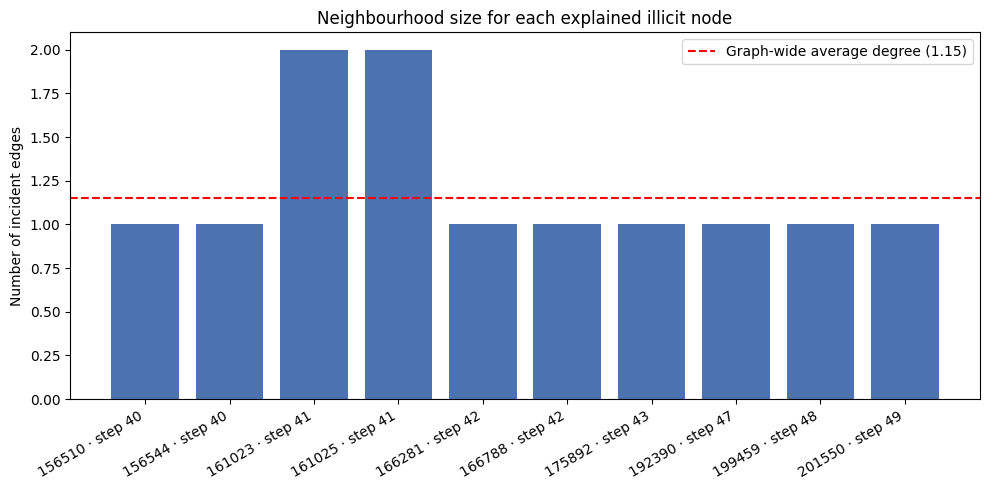

               node  n_edges
0  156510 · step 40        1
1  156544 · step 40        1
2  161023 · step 41        2
3  161025 · step 41        2
4  166281 · step 42        1
5  166788 · step 42        1
6  175892 · step 43        1
7  192390 · step 47        1
8  199459 · step 48        1
9  201550 · step 49        1


In [5]:
import matplotlib.pyplot as plt

records = []
for folder in sorted(tr_graphsage_result_dir.iterdir()):
    if not folder.is_dir():
        continue
    node_idx = int(folder.name.split("_node_")[1].split("_")[0])
    edge_df = pd.read_csv(folder / "edge_importance.csv")
    incident = edge_df[
        (edge_df["source_node"] == node_idx) |
        (edge_df["target_node"] == node_idx)
    ]
    label = folder.name.replace("illicit_node_", "").replace("_step", " · step ")
    records.append({"node": label, "n_edges": len(incident)})

deg_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(deg_df["node"], deg_df["n_edges"], color="#4C72B0")
ax.axhline(1.15, color="red", linestyle="--", label="Graph-wide average degree (1.15)")
ax.set_ylabel("Number of incident edges")
ax.set_title("Neighbourhood size for each explained illicit node")
ax.set_xticklabels(deg_df["node"], rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(tr_graphsage_result_dir / "neighborhood_size_per_node.png", dpi=200, bbox_inches="tight")
plt.show()

print(deg_df)

#### **Elliptic-transactions-graph - GNNExplainer on GraphSAGE**
---

This section analyses how the graph-based model, **GraphSAGE**, makes its predictions on the Elliptic++ transactions dataset. Unlike the tree-based models, GraphSAGE uses both the transaction features and the graph structure connecting transactions.

GraphSAGE with the **simple_balanced** setup achieved an **F1-score of 0.4375** and a **ROC-AUC of 0.8527**, which is much lower than the feature-based models on the same dataset. GraphSAGE was selected because it was the best-performing graph model among the tested GNN approaches.

##### **Methodology**

To explain the predictions of GraphSAGE, **GNNExplainer** was used instead of SHAP. GNNExplainer is designed for graph neural networks because it can explain:
- which node features are important,
- and which neighbouring connections influence the prediction.

Unlike SHAP, which provides global feature importance, GNNExplainer gives local explanations for individual nodes. To obtain a broader view of the model behaviour, explanations were generated for 10 correctly classified illicit transactions across different time steps, worth mentioning that the GraphSAGE model itself was trained with seed 42 (single seed).

##### **Main findings**

The explanations revealed three important patterns.

##### **1. GraphSAGE mainly relies on aggregate features**

Most of the important features identified by GNNExplainer were anonymous **Aggregate_feature_\*** columns. Local transaction features appeared much less often.

This is the opposite of what was observed in the tree-based models. LightGBM and Random Forest mainly relied on local transaction-level features, while GraphSAGE focused more heavily on graph-derived aggregate features.

Several aggregate features appeared repeatedly across different explained nodes, suggesting that GraphSAGE learned a general fraud pattern based on aggregate neighbourhood information.

##### **2. The model did not adapt after the shutdown period**

The explanations before and after the dark-market shutdown looked very similar. GraphSAGE continued using the same features even after the data distribution changed.

This suggests that the model did not fail because it selected different features after the shutdown. Instead, the same features simply became less useful after the shutdown, which likely contributed to the drop in performance.

##### **3. The graph structure was extremely sparse**

The local subgraph explanations showed that most transactions had almost no neighbours:
- 8 of the 10 explained nodes had only 1 neighbour,
- the remaining 2 nodes had only 2 neighbours,
- the average degree was about 1.2 neighbours per node.

In many cases, the neighbouring transaction was licit even when the target transaction was illicit. This means that GraphSAGE had very little useful graph structure to learn from.

Because the graph is so sparse, message passing becomes very limited. Instead of learning complex graph patterns, the model is mostly combining the features of one or two connected nodes.

##### **Importance concentration**

The feature importance values produced by GNNExplainer were much flatter than the SHAP values from the tree-based models. In GraphSAGE, the most important feature was often only slightly more important than the 15th-ranked feature.

This suggests that GraphSAGE could not find a few strong discriminative signals and instead relied on many weak signals at the same time. The problem became even worse after the shutdown period, where the explanations became almost completely flat.

##### **Summary**

The GNNExplainer analysis helps explain why GraphSAGE performed worse than the feature-based models.

GraphSAGE mainly relied on aggregate graph-related features, while the tree-based models focused on local transaction-level features that carried stronger fraud signals. In addition, the transaction graph was extremely sparse, giving the model very little neighbourhood information to use during message passing.

Overall, the results suggest that GraphSAGE was not able to fully benefit from graph structure on this dataset. Instead, it relied on weak aggregate signals and very limited neighbourhood information, which resulted in lower and less stable performance compared to the feature-based models.

---
---

## **Comparing feature-based and graph-based explanations**
---

The feature-based and graph-based sections analysed feature-based and graph-based models on the Elliptic++ transactions dataset. This section directly compares the two model families to answer the second part of RQ3: How XAI methods help explain and compare fraud detection patterns across different data representations.

The comparison focuses on three main points:
1. which features the models use,
2. how concentrated the explanations are,
3. and how useful the graph structure actually is.

### **1. Different models focus on different features**

The XAI analysis shows that the tree-based models and GraphSAGE focus on very different parts of the feature set.

- **LightGBM** and **Random Forest** mainly relied on local transaction-level features.
- **GraphSAGE** relied much more heavily on aggregate graph-related features.

This difference is important because both model families were trained on the same 182 features. Even so, they selected different types of information as important for fraud detection.

The tree-based models achieved much better performance than GraphSAGE. This suggests that the strongest fraud signals in the Elliptic++ transactions dataset come from local transaction behaviour rather than neighbourhood aggregate information.

Without XAI, only the performance difference would be visible. The explainability analysis shows *why* this difference happened.

### **2. Tree models produce sharper explanations**

Another important difference is how concentrated the explanations are.

LightGBM and Random Forest focused strongly on a smaller number of important features. In contrast, GraphSAGE distributed importance more evenly across many features.

For example:
- LightGBM reached importance ratios between 5× and 14×,
- Random Forest between 2.6× and 5.5×,
- GraphSAGE only around 1.1× to 1.8×.

This means the tree models found a few strong fraud indicators, while GraphSAGE relied on many weak signals at the same time.

From a practical AML perspective, this matters because the tree-based explanations are easier to understand and justify. Analysts can clearly see which features caused a prediction, while the GraphSAGE explanations are much more vague and difficult to interpret.

### **3. Graph structure contributed very little**

Although GraphSAGE was designed to use graph structure through message passing, the transaction graph was extremely sparse.

Most explained nodes had only one neighbour, and some had only two. The average graph degree was around 1.15. Because of this, GraphSAGE had very little neighbourhood information available.

The tree-based models also did not rely heavily on graph-derived aggregate features, even though those features were included in the dataset.

This suggests that neither model family gained much benefit from graph structure on this dataset:
- the tree models mostly ignored graph-related features,
- and GraphSAGE could not effectively use the sparse graph connections.

As a result, the main fraud signal came from local transaction-level behaviour rather than from neighbourhood structure.

### **Practical implications for AML explainability**

The two XAI methods produced very different types of explanations.

- **SHAP** provided clear global and local explanations with interpretable feature importance rankings. This made it easier to understand why the tree models flagged a transaction or wallet as suspicious.

- **GNNExplainer** provided local graph explanations, but these explanations often relied on anonymised aggregate features and very small subgraphs with only one or two neighbours.

Because of this, the SHAP explanations were more practical and easier to interpret for AML investigations.

### **Overall**

The XAI comparison shows that feature-based and graph-based models detect fraud differently on the Elliptic++ transactions dataset.

Tree-based models focused mainly on local transaction features and achieved stronger performance. GraphSAGE focused more on aggregate graph-related features but struggled because the transaction graph was extremely sparse.

The explainability analysis also showed that tree-based models produced clearer and more interpretable explanations, while GraphSAGE explanations were more diffuse and harder to use in practice.

Overall, the XAI analysis explains why the feature-based models outperformed GraphSAGE and shows that the strongest fraud signals in this dataset come from local transaction behaviour rather than graph structure.

---
---

## ***Research Question: How do AML detection models differ when applied to transaction graph based datasets versus account level, feature based datasets, and how can XAI methods help interpret and compare fraud detection patterns across these different data representations?***

The results showed that feature-based models clearly outperformed graph-based models on the Elliptic++ transactions dataset, which was the only dataset available in both representations. LightGBM achieved the best performance with an **F1-score of 0.753**, followed by XGBoost (**0.746**) and Random Forest (**0.702**). In comparison, the best graph-based model, GraphSAGE, achieved an **F1-score of 0.438**, while EvolveGCN-O achieved only **0.119**.

Several properties of the dataset help explain this performance gap. First, almost half of the available features were already graph-derived aggregate features. Second, the transaction graph was extremely sparse, with an average node degree of only **1.15**, meaning most transactions had only one or two neighbours. Third, after the dark-market shutdown at step 43, the number of illicit transactions became even smaller, making it harder for graph models to learn meaningful patterns.

The XAI analysis provided a much deeper explanation than the performance metrics alone. SHAP showed that the tree-based models mainly relied on local transaction-level features and largely ignored aggregate graph-related features. Important signals included transaction size, behavioural patterns, and internal transaction properties.

In contrast, GNNExplainer showed that GraphSAGE relied much more heavily on aggregate graph-related features. However, the graph explanations were very vague, meaning that no single feature strongly influenced the predictions. Most explained nodes also had only one neighbour, showing that the graph structure was too sparse for effective message passing.

The comparison revealed that the two model families focused on different parts of the same feature space:
- tree-based models mainly used local transaction features,
- GraphSAGE mainly used aggregate graph-derived features.

Evaluating this difference using the share of aggregate features in each model's top-15 most important features, compared to the dataset baseline of 46% aggregate features:

| Model | Aggregate features in top-15 | vs 46% baseline |
|---|---|---|
| LightGBM | 27% | −41% |
| Random Forest | 7% | −85% |
| GraphSAGE | 60% | +30% |

The tree-based models clearly under-used the aggregate graph-related features, while GraphSAGE relied on them much more heavily. This shows that the two model families focused on different parts of the same feature space. The tree-based models mainly relied on local transaction features, and this approach achieved better performance because those local features contained stronger fraud signals than the aggregate neighbourhood features.

The explainability methods also differed in practical usefulness. SHAP produced clear and interpretable feature importance explanations that could easily support AML investigations. In contrast, GNNExplainer often produced explanations based on anonymised aggregate features and very small subgraphs, making them more difficult to interpret in practice.

Overall, the results show that the choice of data representation was more important than the choice of model architecture on this dataset. The strongest fraud signals were found in local transaction behaviour rather than graph structure. XAI played an important role in answering this research question because it explained not only which models performed better, but also why they made their decisions and which types of fraud patterns they relied on.